In [1]:
import os
import re
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # ← Non_equ/ をパスに追加
import ssll_kinetic
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import csv

In [2]:
def load_spike_data(base_dir, mouse_id, experience_level, group_name, specific_image, max_length):
    load_dir = os.path.join(base_dir, mouse_id, experience_level, group_name)
    file_ac = f'spike_data_{mouse_id}_{experience_level}_{group_name}_active_trials_{specific_image}.npy'
    file_pr = f'spike_data_{mouse_id}_{experience_level}_{group_name}_passive_trials_{specific_image}.npy'
    
    spike_data_ac_path = os.path.join(load_dir, file_ac)
    spike_data_pr_path = os.path.join(load_dir, file_pr)
    
   
    if not os.path.exists(spike_data_ac_path):
        raise FileNotFoundError(f"Active spike data not found: {spike_data_ac_path}")
    if not os.path.exists(spike_data_pr_path):
        raise FileNotFoundError(f"Passive spike data not found: {spike_data_pr_path}")
    
    spike_data_ac = np.load(spike_data_ac_path)[:max_length]
    spike_data_pr = np.load(spike_data_pr_path)[:max_length]
    
    return spike_data_ac, spike_data_pr

In [3]:
def filter_spikes(spikes, n):
        
        tmp = np.mean(spikes, axis=0)
        tmp = np.mean(tmp, axis=0)
        idx_all = np.argsort(tmp)
       
        idx = idx_all[-n:]
        return spikes[:, :, idx]
    
# Function to shuffle spikes
def shuffle_spikes(spikes):
    T, R, N = spikes.shape
    shuffled_spikes = np.zeros(spikes.shape)
    np.random.seed(1)
    for n in range(N):
        r_idx = np.random.permutation(np.arange(R))
        shuffled_spikes[:, :, n] = spikes[:, r_idx, n]
    return shuffled_spikes
    
def process_spikes(spike_data_ac, spike_data_pr, n):
    spikes = {'active': spike_data_ac, 'passive': spike_data_pr}
    
    spikes_shuffled = {
        'active': shuffle_spikes(spike_data_ac),
        'passive': shuffle_spikes(spike_data_pr)
    }

    spikes['active'] = filter_spikes(spikes['active'], n)
    spikes['passive'] = filter_spikes(spikes['passive'], n)
    spikes_shuffled['active'] = filter_spikes(spikes_shuffled['active'], n)
    spikes_shuffled['passive'] = filter_spikes(spikes_shuffled['passive'], n)

    T, R, N = spikes['active'].shape
    return spikes, spikes_shuffled, T, R, N

In [4]:
def load_and_process_data(base_dir, mouse_id, experience_level, group_name, specific_image, max_length, n):
   
    spike_data_ac, spike_data_pr = load_spike_data(base_dir, mouse_id, experience_level, group_name, specific_image, max_length)
  
    spikes, spikes_shuffled, T, R, N = process_spikes(spike_data_ac, spike_data_pr, n)
    
    return spikes, spikes_shuffled, T, N

In [5]:
def calculate_emd_for_state(spikes_state, T, N, num_samples):
    
    emd = ssll_kinetic.run(spikes_state, max_iter=120, mstep=True)  
    return emd

def calculate_emd_results(spikes, T, N, num_samples):
   
    emd_active = calculate_emd_for_state(spikes['active'], T, N, num_samples)
    emd_passive = calculate_emd_for_state(spikes['passive'], T, N, num_samples)
    return emd_active, emd_passive

In [6]:
def summarize_entropy_flow(emd_active, emd_passive, T, N):
    """
    Return value is dict (paper-compliant naming). Units are nats (natural logarithm).

    Input:
    - emd_active, emd_passive: EMD result objects
    - T, N: Lengths for reference (actual length determined by emd)

    Internal functions used:
    - calculate_C(emd, T, N) -> (sf_bath, sr_bath, s_bath, M)
    All shapes are generally (L, N).
    s_bath: Bath entropy flow (dissipative entropy flow)
    sf_bath: Forward conditional entropy
    sr_bath: Backward conditional entropy
    M: Time series of spike probability per neuron

    Main returned keys:
    - entropy_flow_*_timeseries_sum_over_neurons : (L,) Sum over time per neuron
    - entropy_flow_*_per_neuron_sum_over_time : (N,) Sum over time per neuron
    - total_entropy_flow_* : (scalar) Sum over all time and all neurons
    - forward/backward systems similarly
    - spike_prob_sum_T_active/passive : (N,) Time-summed spike probability (use /L externally if averaging is needed)
    - population_mean_spike_prob_timeseries_* : (L,) ← Contains the “sum” (neuron-by-neuron sum per time step)
    - spike_prob_timeseries_sum_over_neurons_* : (L,) Same content as above (honest alias)
    """
    import numpy as np

    sf_fwd_act, sr_bwd_act, eflow_act_ts, means_act = calculate_C(emd_active, T, N)
    sf_fwd_pas, sr_bwd_pas, eflow_pas_ts, means_pas = calculate_C(emd_passive, T, N)

    sf_fwd_act  = np.asarray(sf_fwd_act,  dtype=float)
    sr_bwd_act  = np.asarray(sr_bwd_act,  dtype=float)
    eflow_act_ts= np.asarray(eflow_act_ts,dtype=float)
    means_act   = np.asarray(means_act,   dtype=float)

    sf_fwd_pas  = np.asarray(sf_fwd_pas,  dtype=float)
    sr_bwd_pas  = np.asarray(sr_bwd_pas,  dtype=float)
    eflow_pas_ts= np.asarray(eflow_pas_ts,dtype=float)
    means_pas   = np.asarray(means_pas,   dtype=float)

    def _sums(ts):
        sum_over_neurons = ts.sum(axis=1)        # (L,)
        sum_over_time    = ts.sum(axis=0)        # (N,)
        total            = float(sum_over_neurons.sum())
        return sum_over_neurons, sum_over_time, total

    eA_sumN, eA_sumT, eA_total = _sums(eflow_act_ts)
    eP_sumN, eP_sumT, eP_total = _sums(eflow_pas_ts)

    # --- forward / backward conditional entropy ---
    fA_sumN, fA_sumT, fA_total = _sums(sf_fwd_act)
    fP_sumN, fP_sumT, fP_total = _sums(sf_fwd_pas)
    bA_sumN, bA_sumT, bA_total = _sums(sr_bwd_act)
    bP_sumN, bP_sumT, bP_total = _sums(sr_bwd_pas)

    popA_ts_sum = means_act.sum(axis=1)   # (L,)
    popP_ts_sum = means_pas.sum(axis=1)   # (L,)
    mA_sumT     = means_act.sum(axis=0)   # (N,)
    mP_sumT     = means_pas.sum(axis=0)   # (N,)

    return {
       
        'entropy_flow_active_timeseries_sum_over_neurons':   eA_sumN,
        'entropy_flow_passive_timeseries_sum_over_neurons':  eP_sumN,
        'entropy_flow_active_per_neuron_sum_over_time':      eA_sumT,
        'entropy_flow_passive_per_neuron_sum_over_time':     eP_sumT,
        'total_entropy_flow_active':                         eA_total,
        'total_entropy_flow_passive':                        eP_total,

        'forward_conditional_entropy_active_timeseries_sum_over_neurons':  fA_sumN,
        'forward_conditional_entropy_passive_timeseries_sum_over_neurons': fP_sumN,
        'forward_conditional_entropy_active_per_neuron_sum_over_time':     fA_sumT,
        'forward_conditional_entropy_passive_per_neuron_sum_over_time':    fP_sumT,
        'total_forward_conditional_entropy_active':                        fA_total,
        'total_forward_conditional_entropy_passive':                       fP_total,

        'backward_conditional_entropy_active_timeseries_sum_over_neurons': bA_sumN,
        'backward_conditional_entropy_passive_timeseries_sum_over_neurons':bP_sumN,
        'backward_conditional_entropy_active_per_neuron_sum_over_time':    bA_sumT,
        'backward_conditional_entropy_passive_per_neuron_sum_over_time':   bP_sumT,
        'total_backward_conditional_entropy_active':                       bA_total,
        'total_backward_conditional_entropy_passive':                      bP_total,

        'spike_prob_sum_T_active':  mA_sumT,   # (N,)
        'spike_prob_sum_T_passive': mP_sumT,   # (N,)

        'spike_prob_timeseries_sum_over_neurons_active':  popA_ts_sum, # (L,)
        'spike_prob_timeseries_sum_over_neurons_passive': popP_ts_sum, # (L,)
    }


def calculate_variances(emd_active, emd_passive, T, N):
    
    mean_field_params_active = np.mean(emd_active.theta_s[:, :, 0], axis=0)
    mean_field_params_passive = np.mean(emd_passive.theta_s[:, :, 0], axis=0)
    mean_coupling_params_active = np.mean(emd_active.theta_s[:, :, 1:], axis=0)
    mean_coupling_params_passive = np.mean(emd_passive.theta_s[:, :, 1:], axis=0)

   
    variance_field_params_active = np.var(mean_field_params_active)
    variance_field_params_passive = np.var(mean_field_params_passive)
    variance_coupling_params_active = np.var(mean_coupling_params_active)
    variance_coupling_params_passive = np.var(mean_coupling_params_passive)

    return variance_field_params_active, variance_field_params_passive, variance_coupling_params_active, variance_coupling_params_passive


In [7]:
def calculate_correlations_and_pairs(emd_active, emd_passive, T, N):
    confbound = 1.96
    
    
    theta_cap_active = emd_active.theta_s[:, :, 1:]  # 形状: (T, N, N)
    theta_cap_passive = emd_passive.theta_s[:, :, 1:]  # 形状: (T, N, N)
    
    theta_field_active = emd_active.theta_s[:, :, 1]
    theta_field_passive = emd_passive.theta_s[:, :, 1]

   
    active_corrs = np.array([pearsonr(theta_cap_active[:, i, j], theta_cap_active[:, j, i])[0]
                             for i in range(N) for j in range(N) if i != j])
    passive_corrs = np.array([pearsonr(theta_cap_passive[:, i, j], theta_cap_passive[:, j, i])[0]
                              for i in range(N) for j in range(N) if i != j])
    
    active_corr_mean = np.mean(active_corrs)
    passive_corr_mean = np.mean(passive_corrs)

    
    theta_cap_active_mean = np.mean(emd_active.theta_s[:, :, 1:], axis=0)   # (N, N)
    theta_cap_passive_mean = np.mean(emd_passive.theta_s[:, :, 1:], axis=0) # (N, N)
    
    theta_field_active_mean = np.mean(emd_active.theta_s[:, :, 0], axis=0)
    theta_field_passive_mean = np.mean(emd_passive.theta_s[:, :, 0], axis=0)

    asymmetry_active = 0.0
    asymmetry_passive = 0.0
   
    pair_count = 0

    for i in range(N):
        for j in range(i+1, N):
            asymmetry_active += abs(theta_cap_active_mean[i, j] - theta_cap_active_mean[j, i])
            asymmetry_passive += abs(theta_cap_passive_mean[i, j] - theta_cap_passive_mean[j, i])
            pair_count += 1

    asymmetry_active /= pair_count
    asymmetry_passive /= pair_count

    active_pairs = set()
    passive_pairs = set()

    for t in range(T-1):
        for i in range(N):
            for j in range(1, N):
                if i == j:
                    continue  

                theta_ij_active = emd_active.theta_s[t, i, j]
                sigma_ij_active = emd_active.sigma_s[t, i, j, j]
                tmp_active = np.sqrt(sigma_ij_active)
                upper_bound_active = theta_ij_active + confbound * tmp_active
                lower_bound_active = theta_ij_active - confbound * tmp_active
                exceed_bounds_active = lower_bound_active > 0 or upper_bound_active < 0
                if exceed_bounds_active:
                    if (j, i) not in active_pairs:
                        active_pairs.add((i, j))

                theta_ij_passive = emd_passive.theta_s[t, i, j]
                sigma_ij_passive = emd_passive.sigma_s[t, i, j, j]
                tmp_passive = np.sqrt(sigma_ij_passive)
                upper_bound_passive = theta_ij_passive + confbound * tmp_passive
                lower_bound_passive = theta_ij_passive - confbound * tmp_passive
                exceed_bounds_passive = lower_bound_passive > 0 or upper_bound_passive < 0
                if exceed_bounds_passive:
                    if (j, i) not in passive_pairs:
                        passive_pairs.add((i, j))
    
    return (theta_field_active, theta_field_passive, 
            theta_cap_active, theta_cap_passive, 
            theta_field_active_mean, theta_field_passive_mean, 
            theta_cap_active_mean, theta_cap_passive_mean, 
            active_corr_mean, passive_corr_mean, 
            list(active_pairs), list(passive_pairs),
            asymmetry_active, asymmetry_passive)

In [8]:
def plot_multiple_entropy_comparisons(
    data_list, mouse_ids, linewidth=1, max_columns=5
):
    """
    For new labels only. 1 mouse = 1 subplot.
    Keys used (each data_list[i]):
    - ‘entropy_flow_active_timeseries’
    - ‘entropy_flow_passive_timeseries’
    - ‘population_mean_spike_prob_ts_active’
    - ‘population_mean_spike_prob_ts_passive’
    """
    import numpy as np
    import matplotlib.pyplot as plt

    num_ids = len(mouse_ids)
    if num_ids == 0:
        print("No mouse IDs given. Nothing to plot."); return

    num_columns = min(num_ids, max_columns)
    num_rows = (num_ids + max_columns - 1) // max_columns
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_columns,
                             figsize=(6 * num_columns, 5 * num_rows))
    axes = np.atleast_1d(axes).ravel()

    all_eflow = []
    all_spike = []
    for d in data_list:
        all_eflow += [np.asarray(d['entropy_flow_active_timeseries'], float),
                      np.asarray(d['entropy_flow_passive_timeseries'], float)]
        all_spike += [np.asarray(d['population_mean_spike_prob_ts_active'], float),
                      np.asarray(d['population_mean_spike_prob_ts_passive'], float)]
    y_min = min(map(np.min, all_eflow + all_spike))
    y_max = max(map(np.max, all_eflow + all_spike))

    for idx, (d, mid) in enumerate(zip(data_list, mouse_ids)):
        ax = axes[idx]
        ea = np.asarray(d['entropy_flow_active_timeseries'], float)
        ep = np.asarray(d['entropy_flow_passive_timeseries'], float)
        ma = np.asarray(d['population_mean_spike_prob_ts_active'], float)
        mp = np.asarray(d['population_mean_spike_prob_ts_passive'], float)

        x_e = range(len(ea)); x_mA = range(len(ma)); x_mP = range(len(mp))

        ax.plot(x_e, ea, color='red',  lw=linewidth, label='Entropy flow (active)')
        ax.plot(x_e, ep, color='blue', lw=linewidth, label='Entropy flow (passive)')
        ax.plot(x_mA, ma, color='red',  lw=linewidth, ls='--', label='Mean spikes (active)')
        ax.plot(x_mP, mp, color='blue', lw=linewidth, ls='--', label='Mean spikes (passive)')

        ax.set_xlim(0, max(len(ea), len(ep), len(ma), len(mp)) - 1)
        ax.set_ylim(y_min, y_max)
        ax.set_title(f"(mouse ID: {mid})")
        ax.set_xlabel("Time"); ax.set_ylabel("Entropy flow / Spike prob")
        ax.legend(fontsize=10)

    for k in range(num_ids, len(axes)):
        axes[k].axis('off')

    plt.tight_layout()
    return fig


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def plot_first_mouse_combined_result(
    spike_prob_sumT_active,             # = mouse_all_res['spike_prob_sum_T_active']    (array-like, per-mouse)
    entropy_flow_sumT_active,           # = mouse_all_res['entropy_flow_active_per_neuron_sum_over_time']
    spike_prob_sumT_passive,            # = mouse_all_res['spike_prob_sum_T_passive']
    entropy_flow_sumT_passive,          # = mouse_all_res['entropy_flow_passive_per_neuron_sum_over_time']
    mouse_ids,                          # list[str] or list[int]
    output_dir_base,
    data_label="orig",
    fontsize_title=30,
    fontsize_label=20,
    fontsize_legend=20,
    fontsize_ticklabel=20
):
    xA = np.asarray(spike_prob_sumT_active,  float).ravel()
    yA = np.asarray(entropy_flow_sumT_active, float).ravel()
    xP = np.asarray(spike_prob_sumT_passive, float).ravel()
    yP = np.asarray(entropy_flow_sumT_passive, float).ravel()

    n = min(xA.size, yA.size, xP.size, yP.size, len(mouse_ids))
    xA, yA, xP, yP = xA[:n], yA[:n], xP[:n], yP[:n]
    mouse_ids = mouse_ids[:n]

    mA = np.isfinite(xA) & np.isfinite(yA)
    mP = np.isfinite(xP) & np.isfinite(yP)

    if n == 0:
        print("[plot_first_mouse_combined_result] no data.")
        return

    os.makedirs(output_dir_base, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    ax_left, ax_right = axes

    ax_left.scatter(xA[mA], yA[mA], alpha=0.8, color='red',  label='Active (ΣT)',  marker='o')
    ax_left.scatter(xP[mP], yP[mP], alpha=0.8, color='blue', label='Passive (ΣT)', marker='s')

    for i in range(n):
        if np.isfinite(xA[i]) and np.isfinite(yA[i]) and np.isfinite(xP[i]) and np.isfinite(yP[i]):
            ax_left.plot([xA[i], xP[i]], [yA[i], yP[i]], color='gray', linestyle='--', linewidth=0.8)

    ax_left.set_xlabel('Spike prob ΣT', fontsize=fontsize_label)
    ax_left.set_ylabel('Entropy flow σ ΣT', fontsize=fontsize_label)
    ax_left.tick_params(axis='both', which='major', labelsize=fontsize_ticklabel)
    ax_left.grid(True, alpha=0.3)
    ax_left.legend(fontsize=fontsize_legend)

    xm = np.sqrt(xA * xP)
    dy = yA - yP
    m  = np.isfinite(xm) & np.isfinite(dy)

    s = p = np.nan
    if m.sum() > 1:
        s, p = spearmanr(xm[m], dy[m])

    ax_right.scatter(xm[m], dy[m], alpha=0.8, color='green', label='Δ Entropy flow (ΣT)')
    ax_right.axhline(0.0, color='0.7', ls='--', lw=0.8)
    ax_right.set_xlabel('Geometric mean spike ΣT', fontsize=fontsize_label)
    ax_right.set_ylabel('Δ Entropy flow σ (ΣT)', fontsize=fontsize_label)
    ax_right.tick_params(axis='both', which='major', labelsize=fontsize_ticklabel)
    ax_right.grid(True, alpha=0.3)
    ax_right.legend(fontsize=fontsize_legend)
    ax_right.set_title(f"Spearman={s:.2f} (p={p:.2g})", fontsize=fontsize_label)

    
    fig.suptitle(f"Summary across mice (n={n}) — {data_label}", fontsize=fontsize_title)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    mouse_ids_str = [str(m) for m in mouse_ids]
    example_id = '574078' if '574078' in mouse_ids_str else (mouse_ids_str[0] if mouse_ids_str else 'unknown')

    pdf_title = "S8 Fig. Relationship between spike rates and entropy flow for an example mouse."

    fname = (
        f"S8 Fig. Relationship between spike rates and entropy flow for an example mouse — "
        f"mouse {example_id} (A–B) [{data_label.upper()}].pdf"
    )
    out_pdf = os.path.join(output_dir_base, fname)

    plt.savefig(out_pdf, bbox_inches='tight', metadata={'Title': pdf_title})
    plt.close(fig)
    print(f"[plot_first_mouse_combined_result] saved: {out_pdf}")
   


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def plot_spike_entropy_relation(
    spike_prob_sumT_active,
    entropy_flow_sumT_active,
    spike_prob_sumT_passive,
    entropy_flow_sumT_passive,
    mouse_ids,
    output_dir_base,
    data_label="orig"
):
    xA = np.asarray(spike_prob_sumT_active,  float).ravel()
    yA = np.asarray(entropy_flow_sumT_active, float).ravel()
    xP = np.asarray(spike_prob_sumT_passive, float).ravel()
    yP = np.asarray(entropy_flow_sumT_passive, float).ravel()

    n = min(xA.size, yA.size, xP.size, yP.size, len(mouse_ids))
    xA, yA, xP, yP = xA[:n], yA[:n], xP[:n], yP[:n]
    mouse_ids = mouse_ids[:n]

    if n == 0:
        print("[plot_spike_entropy_relation] no data.")
        return

    mA = np.isfinite(xA) & np.isfinite(yA)
    mP = np.isfinite(xP) & np.isfinite(yP)

    os.makedirs(output_dir_base, exist_ok=True)
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(xA[mA], yA[mA], alpha=0.8, color='red',  label='Active (ΣT)',  marker='o')
    ax.scatter(xP[mP], yP[mP], alpha=0.8, color='blue', label='Passive (ΣT)', marker='s')

    for i in range(n):
        if np.isfinite(xA[i]) and np.isfinite(yA[i]) and np.isfinite(xP[i]) and np.isfinite(yP[i]):
            ax.plot([xA[i], xP[i]], [yA[i], yP[i]], color='gray', linestyle='--', linewidth=0.8)

    sA = pA = sP = pP = np.nan
    if mA.sum() > 1: sA, pA = spearmanr(xA[mA], yA[mA])
    if mP.sum() > 1: sP, pP = spearmanr(xP[mP], yP[mP])

    ax.set_xlabel('Spike prob ΣT')
    ax.set_ylabel('Entropy flow σ ΣT')
    ax.set_title(f'Entropy flow vs Spike (n={n})  —  Spearman A={sA:.2f}(p={pA:.2g})  P={sP:.2f}(p={pP:.2g})')
    ax.grid(True, alpha=0.3)
    ax.legend()

    out_pdf = os.path.join(output_dir_base, f"spike_entropy_relation_{data_label}.pdf")
    plt.tight_layout(); plt.savefig(out_pdf); plt.close(fig)
    print(f"[plot_spike_entropy_relation] saved: {out_pdf}")


In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def plot_spike_entropy_difference(
    spike_prob_sumT_active,
    entropy_flow_sumT_active,
    spike_prob_sumT_passive,
    entropy_flow_sumT_passive,
    mouse_ids,
    output_dir_base,
    data_label="orig"
):
    xA = np.asarray(spike_prob_sumT_active,  float).ravel()
    yA = np.asarray(entropy_flow_sumT_active, float).ravel()
    xP = np.asarray(spike_prob_sumT_passive, float).ravel()
    yP = np.asarray(entropy_flow_sumT_passive, float).ravel()

    n = min(xA.size, yA.size, xP.size, yP.size, len(mouse_ids))
    xA, yA, xP, yP = xA[:n], yA[:n], xP[:n], yP[:n]
    mouse_ids = mouse_ids[:n]

    if n == 0:
        print("[plot_spike_entropy_difference] no data.")
        return

    xm = np.sqrt(xA * xP)  # 幾何平均
    dy = yA - yP           # Δσ
    m  = np.isfinite(xm) & np.isfinite(dy)

    os.makedirs(output_dir_base, exist_ok=True)
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(xm[m], dy[m], alpha=0.8, color='green', label='Δ Entropy flow (ΣT)')
    ax.axhline(0.0, color='0.7', ls='--', lw=0.8)
    ax.set_xlabel('Geometric mean spike ΣT')
    ax.set_ylabel('Δ Entropy flow σ (ΣT)')
    ax.grid(True, alpha=0.3)
    ax.legend()

    s = p = np.nan
    if m.sum() > 1:
        s, p = spearmanr(xm[m], dy[m])
    ax.set_title(f'Δ Entropy flow vs Spike (n={int(m.sum())}) — Spearman={s:.2f} (p={p:.2g})')

    out_pdf = os.path.join(output_dir_base, f"spike_entropy_difference_{data_label}.pdf")
    plt.tight_layout(); plt.savefig(out_pdf); plt.close(fig)
    print(f"[plot_spike_entropy_difference] saved: {out_pdf}")


In [12]:
def save_combined_figure_both_diff_2x2(
    output_dir_base, experience_level, max_length,
    **kwargs
):
    """
    2×2 Composite Diagram (for new labels only).
    Accepted primary keys (*_orig / *_shuf are paired):

    Timeseries (Entropy Flow; timeseries of Σ_i over neurons)
    - ‘entropy_flow_active_timeseries_{orig,shuf}’
    - ‘entropy_flow_passive_timeseries_{orig,shuf}’
    Spike Probability (population mean timeseries)
    - ‘population_mean_spike_prob_ts_active_{orig,shuf}’
    - ‘population_mean_spike_prob_ts_passive_{orig,shuf}’

    Aggregation Dictionary (All Mice; New Labels Required)
    - ‘mouse_all_results_{orig,shuf}’

    New labels that are safe to include in the aggregated dictionary (not used directly by this function but useful for consistency checks):
    - ‘mouse_id’
    - ‘entropy_flow_active_per_neuron_sum_over_time’
    - ‘entropy_flow_passive_per_neuron_sum_over_time’
    - ‘spike_prob_sum_T_active’
    - ‘spike_prob_sum_T_passive’
    (Lower sections B/C and statistical strings assume plot_type=‘entropy_flow’.
    Lower plotters are assumed to already support new labels)

    """
    import os
    import matplotlib.pyplot as plt
    from matplotlib import gridspec

    global fontsize_title, fontsize_label, fontsize_legend, fontsize_ticklabel, fontsize_ABC

    def pick_required(key):
        if key not in kwargs or kwargs[key] is None:
            avail = ", ".join(sorted(kwargs.keys()))
            raise KeyError(f"[save_combined_figure_both_diff_2x2] missing key: '{key}'. Available: {avail}")
        return kwargs[key]

    eflow_act_orig = pick_required('entropy_flow_active_timeseries_orig')
    eflow_pas_orig = pick_required('entropy_flow_passive_timeseries_orig')
    means_act_orig = pick_required('population_mean_spike_prob_ts_active_orig')
    means_pas_orig = pick_required('population_mean_spike_prob_ts_passive_orig')

    eflow_act_shuf = pick_required('entropy_flow_active_timeseries_shuf')
    eflow_pas_shuf = pick_required('entropy_flow_passive_timeseries_shuf')
    means_act_shuf = pick_required('population_mean_spike_prob_ts_active_shuf')
    means_pas_shuf = pick_required('population_mean_spike_prob_ts_passive_shuf')

    mouse_all_results_orig = pick_required('mouse_all_results_orig')
    mouse_all_results_shuf = pick_required('mouse_all_results_shuf')

    def _require_agg_keys(A, where):
        req = [
            'mouse_id',
            'total_entropy_flow_active',
            'total_entropy_flow_passive',
        ]
        missing = [k for k in req if k not in A or A[k] is None]
        if missing:
            raise KeyError(f"[save_combined_figure_both_diff_2x2] {where} missing keys: {missing}")
    _require_agg_keys(mouse_all_results_orig, "mouse_all_results_orig")
    _require_agg_keys(mouse_all_results_shuf, "mouse_all_results_shuf")

    M_orig = mouse_all_results_orig
    M_shuf = mouse_all_results_shuf

    fig = plt.figure(figsize=(16, 16))
    gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.1, hspace=0.3)

    ax_entropy = fig.add_subplot(gs[0, 0:2])
    plot_entropy_comparison_both(
        eflow_act_orig, eflow_pas_orig, means_act_orig, means_pas_orig,
        eflow_act_shuf, eflow_pas_shuf, means_act_shuf, means_pas_shuf,
        ax=ax_entropy
    )
    try:
        subtitle = f"Entropy flow (Orig + Shuf) | {experience_level}, maxlen={max_length}"
    except Exception:
        subtitle = "Entropy flow (Orig + Shuf)"
    ax_entropy.set_title(subtitle, fontsize=fontsize_ticklabel)

    ax_orig_only = fig.add_subplot(gs[1, 0])
    plot_results(M_orig, plot_type='entropy_flow', ax=ax_orig_only)
    ax_orig_only.set_title("Entropy flow (all mice: Orig)", fontsize=fontsize_ticklabel)
    ax_orig_only.plot([], [], color='black', label='each line = each mouse')
    ax_orig_only.legend(loc='best')

    stats_text_entropy_orig = compare_active_passive_str_universal(
        plot_type='entropy_flow',
        mouse_all_results_orig=M_orig,
        is_delta=False
    )
    ax_orig_only.text(
        0.05, 0.9, stats_text_entropy_orig,
        transform=ax_orig_only.transAxes, fontsize=10, va='top',
        bbox=dict(facecolor='white', alpha=0.5)
    )

    ax_diff = fig.add_subplot(gs[1, 1])
    plot_results_difference_color_per_mouse(
        ax=ax_diff,
        mouse_all_results_orig=M_orig,
        mouse_all_results_shuf=M_shuf,
        plot_type='entropy_flow'
    )
    ax_diff.set_title(r'$\Delta$Entropy flow (all mice: Orig−Shuf)', fontsize=fontsize_ticklabel)

    stats_text_entropy_diff = compare_active_passive_str_universal(
        plot_type='entropy_flow',
        mouse_all_results_orig=M_orig,
        mouse_all_results_shuf=M_shuf,
        is_delta=True
    )
    ax_diff.text(
        0.05, 0.9, stats_text_entropy_diff,
        transform=ax_diff.transAxes, fontsize=10, va='top',
        bbox=dict(facecolor='white', alpha=0.5)
    )

    labels = ['A','B','C']
    label_positions = [[0.1,0.90], [0.1,0.46], [0.53,0.46]]
    for label, (x, y) in zip(labels, label_positions):
        ax_lbl = fig.add_axes([x, y, 0.03, 0.03], frameon=False)
        ax_lbl.set_xticks([]); ax_lbl.set_yticks([])
        ax_lbl.text(0.0, 0.0, label, fontsize=fontsize_ABC, fontweight='bold')

    os.makedirs(output_dir_base, exist_ok=True)
    outpath = os.path.join(output_dir_base, 'Fig 8. Estimated entropy flow dynamics.pdf')
    plt.savefig(outpath, format='pdf', bbox_inches='tight')
    plt.close(fig)
    print(f"[save_combined_figure_both_diff_2x2] Saved figure: {outpath}")


In [13]:
def calculate_coupling_means(emd_active, emd_passive):
    """
    Same definition as B:
    ・Create the time-averaged connection matrix (time-averaging theta_s[:, :, 1:])
    ・Flatten all elements of that matrix (including the diagonal, distinguishing (i,j) and (j,i)) and return the average value

    """
    mean_cpl_act_matrix = np.mean(emd_active.theta_s[:, :, 1:], axis=0)   # (N, N)
    mean_cpl_pas_matrix = np.mean(emd_passive.theta_s[:, :, 1:], axis=0)  # (N, N)

    mean_cpl_act_value = float(np.mean(mean_cpl_act_matrix))
    mean_cpl_pas_value = float(np.mean(mean_cpl_pas_matrix))
    return mean_cpl_act_value, mean_cpl_pas_value


In [14]:
def compare_active_passive_mean(
    mouse_all_results_orig,
    mouse_all_results_shuf=None,
    is_delta=False
):
    """
    Row2 (is_delta=False):
    Compare per-mouse metrics (mean_coupling_params) between Active and Passive
    Row3 (is_delta=True):
    Compare (Orig−Shuf) Active with (Orig−Shuf) Passive
    Display: Mean ± SD and mean Δ, plus dz (mean difference/SD difference)
    """
    import numpy as np

    def _fmt(x):
        x = np.asarray(x, dtype=float)
        if x.size == 0:
            return "n=0"
        mu = np.mean(x)
        sd = np.std(x, ddof=1) if x.size > 1 else 0.0
        return f"{mu:.3g} ± {sd:.3g} (n={x.size})"

    if not is_delta:
        a = np.asarray(mouse_all_results_orig['mean_coupling_params_active'], dtype=float)
        p = np.asarray(mouse_all_results_orig['mean_coupling_params_passive'], dtype=float)
        d = a - p
        mean_d = float(np.mean(d)) if d.size else float('nan')
        sd_d = float(np.std(d, ddof=1)) if d.size > 1 else 0.0
        dz = mean_d / sd_d if sd_d > 0 else float('nan')
        return f"Active: {_fmt(a)} | Passive: {_fmt(p)} | Δ(A−P)={mean_d:.3g} | dz={dz:.2f}"

    ao = np.asarray(mouse_all_results_orig['mean_coupling_params_active'], dtype=float)
    po = np.asarray(mouse_all_results_orig['mean_coupling_params_passive'], dtype=float)
    if mouse_all_results_shuf is None:
        return "need shuf for delta"

    as_ = np.asarray(mouse_all_results_shuf['mean_coupling_params_active'], dtype=float)
    ps_ = np.asarray(mouse_all_results_shuf['mean_coupling_params_passive'], dtype=float)

    n = min(ao.size, as_.size, po.size, ps_.size)
    if n == 0:
        return "n=0"

    da = ao[:n] - as_[:n]   # ΔActive = Orig−Shuf
    dp = po[:n] - ps_[:n]   # ΔPassive = Orig−Shuf
    dd = da - dp            # ΔΔ = (ΔA − ΔP)

    mean_dd = float(np.mean(dd))
    sd_dd = float(np.std(dd, ddof=1)) if dd.size > 1 else 0.0
    dz = mean_dd / sd_dd if sd_dd > 0 else float('nan')

    return (
        f"ΔActive: {_fmt(da)} | ΔPassive: {_fmt(dp)} | "
        f"ΔΔ(ΔA−ΔP)={mean_dd:.3g} | dz={dz:.2f}"
    )


In [15]:
def save_custom_3x3_figure(
    output_dir_base, experience_level, max_length,
    mean_field_params_active_target,
    mean_field_params_passive_target,
    mean_coupling_params_active_target,
    mean_coupling_params_passive_target,
    mean_correlation_active_target,
    mean_correlation_passive_target,
    neuron_pairs_active_target,
    neuron_pairs_passive_target,

    mouse_all_results_orig,

    mouse_all_results_shuf
):
    """
    3×3 Layout (New Labels Only):
    Row1 => Single Mouse (Original)
    Row2 => All Mice (Original) + Test Result Notes
    Row3 => Difference (Original vs. Shuffle) + Test Result Notes
    """
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib import gridspec

    global fontsize_title, fontsize_label, fontsize_legend, fontsize_ticklabel, fontsize_ABC

    M_orig = mouse_all_results_orig
    M_shuf = mouse_all_results_shuf

    fig = plt.figure(figsize=(24, 24))
    gs = gridspec.GridSpec(3, 3, figure=fig, wspace=0.3, hspace=0.5)

    ax_field = fig.add_subplot(gs[0, 0])
    plot_theta_field_violin(
        mean_field_params_active_target,
        mean_field_params_passive_target,
        ax=ax_field
    )
    ax_field.set_title("Field params (Target, Orig)", fontsize=fontsize_ticklabel)

    ax_cap = fig.add_subplot(gs[0, 1])
    plot_theta_cap_violin(
        mean_coupling_params_active_target,
        mean_coupling_params_passive_target,
        ax=ax_cap
    )
    ax_cap.set_title("Coupling params (Target, Orig)", fontsize=fontsize_ticklabel)

    ax_symmetry = fig.add_subplot(gs[0, 2])
    plot_symmetry_with_regression(
        mean_coupling_params_active_target,
        mean_coupling_params_passive_target,
        mean_correlation_active_target,
        mean_correlation_passive_target,
        neuron_pairs_active_target,
        neuron_pairs_passive_target,
        ax=ax_symmetry
    )
    ax_symmetry.set_title("Asymmetry (Target, Orig)", fontsize=fontsize_ticklabel)

    ax_v_field = fig.add_subplot(gs[1, 0])
    plot_results(M_orig, 'variance_field_params', ax=ax_v_field)
    ax_v_field.set_title("Variance field params (all mice: Orig)", fontsize=fontsize_ticklabel)
    ax_v_field.plot([], [], color='black', label='each line = each mouse')
    ax_v_field.legend(loc='best')

    stats_text_vfield = compare_active_passive_str_universal(
        plot_type='variance_field_params',
        mouse_all_results_orig=M_orig,
        is_delta=False
    )
    ax_v_field.text(
        0.05, 0.9, stats_text_vfield, transform=ax_v_field.transAxes,
        fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.5)
    )

    ax_v_cpl = fig.add_subplot(gs[1, 1])
    plot_results(M_orig, 'mean_effective_coupling', ax=ax_v_cpl)
    ax_v_cpl.set_title("Mean effective coupling (all mice: Orig)", fontsize=fontsize_ticklabel)
    ax_v_cpl.plot([], [], color='black', label='each line = each mouse')
    ax_v_cpl.legend(loc='best')

    stats_text_mean_cpl = compare_active_passive_str_universal(
        plot_type='mean_effective_coupling',
        mouse_all_results_orig=M_orig,
        is_delta=False
    )
    ax_v_cpl.text(
        0.05, 0.9, stats_text_mean_cpl, transform=ax_v_cpl.transAxes,
        fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.5)
    )

    ax_asym = fig.add_subplot(gs[1, 2])
    plot_results(M_orig, 'coupling_asymmetry', ax=ax_asym)
    ax_asym.set_title("Asymmetry (all mice: Orig)", fontsize=fontsize_ticklabel)
    ax_asym.plot([], [], color='black', label='each line = each mouse')
    ax_asym.legend(loc='best')

    stats_text_asym = compare_active_passive_str_universal(
        plot_type='coupling_asymmetry',
        mouse_all_results_orig=M_orig,
        is_delta=False
    )
    ax_asym.text(
        0.05, 0.9, stats_text_asym, transform=ax_asym.transAxes,
        fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.5)
    )

    ax_diff_field = fig.add_subplot(gs[2, 0])
    plot_results_difference_color_per_mouse(
        ax_diff_field,
        M_orig, M_shuf,
        plot_type='variance_field_params',
        cmap=plt.cm.tab20
    )
    ax_diff_field.set_title(r'$\Delta$ Variance field params (Orig - Shuf)', fontsize=fontsize_ticklabel)

    stats_text_vfield_diff = compare_active_passive_str_universal(
        plot_type='variance_field_params',
        mouse_all_results_orig=M_orig,
        mouse_all_results_shuf=M_shuf,
        is_delta=True
    )
    ax_diff_field.text(
        0.05, 0.9, stats_text_vfield_diff, transform=ax_diff_field.transAxes,
        fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.5)
    )

    ax_diff_cpl = fig.add_subplot(gs[2, 1])
    plot_results_difference_color_per_mouse(
        ax_diff_cpl,
        M_orig, M_shuf,
        plot_type='mean_effective_coupling',
        cmap=plt.cm.tab20
    )
    ax_diff_cpl.set_title(r'$\Delta$ Mean effective coupling (Orig - Shuf)', fontsize=fontsize_ticklabel)

    stats_text_mean_cpl_diff = compare_active_passive_str_universal(
        plot_type='mean_effective_coupling',
        mouse_all_results_orig=M_orig,
        mouse_all_results_shuf=M_shuf,
        is_delta=True
    )
    ax_diff_cpl.text(
        0.05, 0.9, stats_text_mean_cpl_diff, transform=ax_diff_cpl.transAxes,
        fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.5)
    )

    ax_diff_asym = fig.add_subplot(gs[2, 2])
    plot_results_difference_color_per_mouse(
        ax_diff_asym,
        M_orig, M_shuf,
        plot_type='coupling_asymmetry',
        cmap=plt.cm.tab20
    )
    ax_diff_asym.set_title(r'$\Delta$ Asymmetry (Orig - Shuf)', fontsize=fontsize_ticklabel)

    stats_text_asym_diff = compare_active_passive_str_universal(
        plot_type='coupling_asymmetry',
        mouse_all_results_orig=M_orig,
        mouse_all_results_shuf=M_shuf,
        is_delta=True
    )
    ax_diff_asym.text(
        0.05, 0.9, stats_text_asym_diff, transform=ax_diff_asym.transAxes,
        fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.5)
    )

    labels = ['A','B','C','D','E','F','G','H','I']
    label_positions = [
        [0.1, 0.9], [0.38, 0.9], [0.70, 0.9],
        [0.1, 0.62], [0.38, 0.62], [0.70, 0.62],
        [0.1, 0.33], [0.38, 0.33], [0.70, 0.33]
    ]
    for label, (x, y) in zip(labels, label_positions):
        ax_lbl = fig.add_axes([x, y, 0.03, 0.03], frameon=False)
        ax_lbl.set_xticks([]); ax_lbl.set_yticks([])
        ax_lbl.text(0.0, 0.0, label, fontsize=fontsize_ABC, fontweight='bold')

    os.makedirs(output_dir_base, exist_ok=True)
    outpath = os.path.join(output_dir_base, 'Fig. 7. Variability of estimated model parameters (fields, couplings, asymmetry).pdf')
    plt.savefig(outpath, format='pdf', bbox_inches='tight')
    plt.close(fig)
    print(f"[save_custom_3x3_figure] Saved figure: {outpath}")


In [16]:

import numpy as np
from scipy.stats import ttest_rel, shapiro, wilcoxon, ttest_ind

import numpy as np
from scipy.stats import ttest_rel, shapiro, wilcoxon, ttest_ind
def compare_active_passive(mouse_all_results, min_samples=3):
    """
    Total Entropy Flow for All Mice (Bath Entropy Change, nats)
    Perform statistical comparison between Active and Passive (new labels only).
    """
    import numpy as np
    from scipy.stats import ttest_rel, shapiro, wilcoxon, ttest_ind

    d = mouse_all_results
    y_active  = np.asarray(d['total_entropy_flow_active'],  float).ravel()
    y_passive = np.asarray(d['total_entropy_flow_passive'], float).ravel()

    n = min(y_active.size, y_passive.size)
    y_active, y_passive = y_active[:n], y_passive[:n]
    m = np.isfinite(y_active) & np.isfinite(y_passive)
    y_active, y_passive = y_active[m], y_passive[m]
    diffs = y_active - y_passive
    n = diffs.size

    print(f"\n[compare_active_passive] Sample size = {n}")
    if n < min_samples:
        print(f"  サンプル数が {n} のため、正規性検定や t検定はスキップ。")
        # print(f" Due to a sample size of {n}, normality tests and t-tests are skipped.”)
        return

    W, p_sw = shapiro(diffs)
    print(f"[Shapiro-Wilk] W={W:.4f}, p={p_sw:.4g}")

    t_rel, p_rel = ttest_rel(y_active, y_passive)
    print(f"[Paired t-test] t={t_rel:.4f}, p={p_rel:.4g}")

    Wz, p_w = wilcoxon(y_active, y_passive)
    print(f"[Wilcoxon] W={Wz:.4f}, p={p_w:.4g}")

    t_ind, p_ind = ttest_ind(y_active, y_passive, equal_var=True)
    print(f"[Unpaired t-test] t={t_ind:.4f}, p={p_ind:.4g}")

    mean_diff = np.mean(diffs)
    sd_diff   = np.std(diffs, ddof=1)
    d_paired  = (mean_diff / sd_diff) if sd_diff != 0 else np.nan
    print(f"Cohen’s d (paired): {d_paired:.4f}")

    n1, n2 = len(y_active), len(y_passive)
    v1, v2 = np.var(y_active, ddof=1), np.var(y_passive, ddof=1)
    pooled = ((n1 - 1)*v1 + (n2 - 1)*v2) / max(n1 + n2 - 2, 1)
    d_unpaired = ((np.mean(y_active) - np.mean(y_passive)) / np.sqrt(pooled)) if pooled > 0 else np.nan
    print(f"Cohen’s d (unpaired): {d_unpaired:.4f}")


In [17]:
# import numpy as np
# from scipy.stats import ttest_rel, shapiro, wilcoxon, ttest_ind

# def compare_active_passive_delta_asymmetry(
#     mouse_all_results_orig,
#     mouse_all_results_shuf,
#     min_samples: int = 3
# ):
#     """
#     Compare the “coupling asymmetry” difference between Active and Passive (for new labels only).

#     Required keys (both dictionaries):
#     - ‘coupling_asymmetry_active’
#     - ‘coupling_asymmetry_passive’

#     Return value:
#     None (print results). Can be extended to a return dictionary if needed.
#     """

#     def _require_keys(d, where):
#         req = ['coupling_asymmetry_active', 'coupling_asymmetry_passive']
#         missing = [k for k in req if k not in d or d[k] is None]
#         if missing:
#             avail = ", ".join(sorted(d.keys()))
#             raise KeyError(
#                 f"[compare_active_passive_delta_asymmetry] {where} missing keys: {missing}. "
#                 f"Available: {avail}"
#             )

#     _require_keys(mouse_all_results_orig, "mouse_all_results_orig")
#     _require_keys(mouse_all_results_shuf, "mouse_all_results_shuf")

#     orig_active  = np.asarray(mouse_all_results_orig['coupling_asymmetry_active'],  dtype=float).ravel()
#     shuf_active  = np.asarray(mouse_all_results_shuf['coupling_asymmetry_active'],  dtype=float).ravel()
#     y_active     = orig_active - shuf_active

#     orig_passive = np.asarray(mouse_all_results_orig['coupling_asymmetry_passive'], dtype=float).ravel()
#     shuf_passive = np.asarray(mouse_all_results_shuf['coupling_asymmetry_passive'], dtype=float).ravel()
#     y_passive    = orig_passive - shuf_passive

#     n = min(y_active.size, y_passive.size)
#     y_active, y_passive = y_active[:n], y_passive[:n]
#     mask = np.isfinite(y_active) & np.isfinite(y_passive)
#     y_active, y_passive = y_active[mask], y_passive[mask]

#     differences = y_active - y_passive
#     n = differences.size

#     print("\n[compare_active_passive_delta_asymmetry] Comparison of (orig–shuf) in Coupling Asymmetry: Active vs. Passive")
#     print(f"Sample size = {n}")
#     if n < min_samples:
       
#         print(f" Since the sample size is {n}, Shapiro–Wilk tests are skipped.")
#         return

#     stat_sw, p_sw = shapiro(differences)
#     print(f"[Shapiro-Wilk test for normality of differences]")
#     print(f"  W-statistic = {stat_sw:.4f}, p-value = {p_sw:.4g}")

#     t_stat_rel, t_pval_rel = ttest_rel(y_active, y_passive)
#     print(f"\n[Paired t-test for (orig–shuf) coupling asymmetry]")
#     print(f"  t-statistic = {t_stat_rel:.4f}, p-value = {t_pval_rel:.4g}")

#     try:
#         w_stat, w_pval = wilcoxon(y_active, y_passive)
#     except ValueError:
#         w_stat, w_pval = (0.0, 1.0)
#     print(f"\n[Wilcoxon signed-rank test for (orig–shuf) coupling asymmetry]")
#     print(f"  W-statistic = {w_stat:.4f}, p-value = {w_pval:.4g}")

#     t_stat_ind, t_pval_ind = ttest_ind(y_active, y_passive, equal_var=True)
#     print(f"\n[Student’s t-test (unpaired) for (orig–shuf) coupling asymmetry]")
#     print(f"  t-statistic = {t_stat_ind:.4f}, p-value = {t_pval_ind:.4g}")

#     mean_diff = float(np.mean(differences)) if n > 0 else np.nan
#     std_diff  = float(np.std(differences, ddof=1)) if n > 1 else np.nan
#     cohens_d_paired = (mean_diff / std_diff) if (std_diff is not None and std_diff not in [0.0, np.nan]) else np.nan
#     print(f"\nCohen’s d (paired): {cohens_d_paired:.4f}")

#     n1, n2 = len(y_active), len(y_passive)
#     var1, var2 = (np.var(y_active, ddof=1) if n1 > 1 else np.nan,
#                   np.var(y_passive, ddof=1) if n2 > 1 else np.nan)
#     if np.isfinite(var1) and np.isfinite(var2) and (n1+n2-2) > 0:
#         pooled_var = ((n1 - 1)*var1 + (n2 - 1)*var2) / (n1 + n2 - 2)
#         pooled_sd  = np.sqrt(pooled_var)
#         mean_a, mean_p = float(np.mean(y_active)), float(np.mean(y_passive))
#         cohens_d_unpaired = ((mean_a - mean_p) / pooled_sd) if pooled_sd != 0 else np.nan
#     else:
#         cohens_d_unpaired = np.nan
#     print(f"Cohen’s d (unpaired): {cohens_d_unpaired:.4f}")

#     alpha = 0.05
#     print(f"\n-- Interpretation (at alpha={alpha}) --")
#     print("Paired t-test: " + ("有意な差があります。 (Active差 vs Passive差) [Asymmetry]"
#                                if t_pval_rel < alpha else
#                                "有意な差は検出されませんでした。 [Asymmetry]"))
#     print("Wilcoxon test: " + ("有意な差があります。 (Active差 vs Passive差) [Asymmetry]"
#                                if w_pval < alpha else
#                                "有意な差は検出されませんでした。 [Asymmetry]"))
#     print("Student’s t-test (unpaired): " + ("有意な差があります。 (Active差 vs Passive差) [Asymmetry]"
#                                             if t_pval_ind < alpha else
#                                             "有意な差は検出されませんでした。 [Asymmetry]"))
              


import numpy as np
from scipy.stats import ttest_rel, shapiro, wilcoxon, ttest_ind

def compare_active_passive_delta_asymmetry(
    mouse_all_results_orig,
    mouse_all_results_shuf,
    min_samples: int = 3
):
    """
    Compare the 'coupling asymmetry' difference between Active and Passive (for new labels only).

    Required keys (both dictionaries):
    - 'coupling_asymmetry_active'
    - 'coupling_asymmetry_passive'

    Return value:
    None (prints results). Can be extended to return a dictionary if needed.
    """

    def _require_keys(d, where):
        req = ['coupling_asymmetry_active', 'coupling_asymmetry_passive']
        missing = [k for k in req if k not in d or d[k] is None]
        if missing:
            avail = ", ".join(sorted(d.keys()))
            raise KeyError(
                f"[compare_active_passive_delta_asymmetry] {where} missing keys: {missing}. "
                f"Available: {avail}"
            )

    _require_keys(mouse_all_results_orig, "mouse_all_results_orig")
    _require_keys(mouse_all_results_shuf, "mouse_all_results_shuf")

    orig_active  = np.asarray(mouse_all_results_orig['coupling_asymmetry_active'],  dtype=float).ravel()
    shuf_active  = np.asarray(mouse_all_results_shuf['coupling_asymmetry_active'],  dtype=float).ravel()
    y_active     = orig_active - shuf_active

    orig_passive = np.asarray(mouse_all_results_orig['coupling_asymmetry_passive'], dtype=float).ravel()
    shuf_passive = np.asarray(mouse_all_results_shuf['coupling_asymmetry_passive'], dtype=float).ravel()
    y_passive    = orig_passive - shuf_passive

    n = min(y_active.size, y_passive.size)
    y_active, y_passive = y_active[:n], y_passive[:n]
    mask = np.isfinite(y_active) & np.isfinite(y_passive)
    y_active, y_passive = y_active[mask], y_passive[mask]

    differences = y_active - y_passive
    n = differences.size

    print("\n[compare_active_passive_delta_asymmetry] Comparison of (orig–shuf) in Coupling Asymmetry: Active vs. Passive")
    print(f"Sample size = {n}")
    if n < min_samples:
        print(f"Since the sample size is {n}, Shapiro-Wilk tests are skipped.")
        return

    stat_sw, p_sw = shapiro(differences)
    print("[Shapiro-Wilk test for normality of differences]")
    print(f"  W-statistic = {stat_sw:.4f}, p-value = {p_sw:.4g}")

    t_stat_rel, t_pval_rel = ttest_rel(y_active, y_passive)
    print("\n[Paired t-test for (orig–shuf) coupling asymmetry]")
    print(f"  t-statistic = {t_stat_rel:.4f}, p-value = {t_pval_rel:.4g}")

    try:
        w_stat, w_pval = wilcoxon(y_active, y_passive)
    except ValueError:
        w_stat, w_pval = (0.0, 1.0)
    print("\n[Wilcoxon signed-rank test for (orig–shuf) coupling asymmetry]")
    print(f"  W-statistic = {w_stat:.4f}, p-value = {w_pval:.4g}")

    t_stat_ind, t_pval_ind = ttest_ind(y_active, y_passive, equal_var=True)
    print("\n[Student's t-test (unpaired) for (orig–shuf) coupling asymmetry]")
    print(f"  t-statistic = {t_stat_ind:.4f}, p-value = {t_pval_ind:.4g}")

    mean_diff = float(np.mean(differences)) if n > 0 else np.nan
    std_diff  = float(np.std(differences, ddof=1)) if n > 1 else np.nan
    cohens_d_paired = (mean_diff / std_diff) if (np.isfinite(std_diff) and std_diff != 0.0) else np.nan
    print(f"\nCohen's d (paired): {cohens_d_paired:.4f}")

    n1, n2 = len(y_active), len(y_passive)
    var1 = np.var(y_active, ddof=1) if n1 > 1 else np.nan
    var2 = np.var(y_passive, ddof=1) if n2 > 1 else np.nan
    if np.isfinite(var1) and np.isfinite(var2) and (n1 + n2 - 2) > 0:
        pooled_var = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)


In [18]:

def update_S(H, J, m_p):
    size = len(H)
    S = np.zeros(size)
    g = H + np.dot(J, m_p)
    D = np.dot(J**2, m_p*(1 - m_p))
    for i in range(size):
        S[i] = integrate_1DGaussian(dT_s, (g[i], D[i]))
    return S
   

def integrate_1DGaussian(f, args=(), Nint=100):
    x = np.linspace(-1, 1, Nint) * 4
    
    a = np.sum(f(x, *args)) * (x[1] - x[0])
    return a

def chi(a):
    oe = 1 / (1 +  np.exp(a))
    s = (oe)*np.log(oe)+(1-oe)*np.log(1-oe)
    return -s

def dT_s(x, g, D):
    return 1 / np.sqrt(2 * np.pi) * np.exp(-0.5 * x**2) * chi(g + x * np.sqrt(D))

def sigmoid(a):
    s = 1 / (1 +  np.exp(-a))
    return s

def dT1(x, g, D):
    return 1 / np.sqrt(2 * np.pi) * np.exp(-0.5 * x**2) * sigmoid(g + x * np.sqrt(D))

def update_m_P_t1_o1(H, J, m_p):
    size = len(H)
    m = np.zeros(size)
    g = H + np.dot(J, m_p)
    D = np.dot(J**2, m_p*(1 - m_p))        
    for i in range(size):
        m[i] = integrate_1DGaussian(dT1, (g[i], D[i]))
    return m

def update_S_bb(H, J, m, m_p):
    size = len(H)
    phi_0 = np.zeros(size)
    phi_1 = np.zeros(size)
    S = np.zeros(size) 
    g = H + np.dot(J, m)
    D = np.dot(J**2, m*(1 - m))
    for i in range(size):
        phi_0[i] = integrate_1DGaussian(dT_sr_0, (g[i], D[i]))
        phi_1[i] = integrate_1DGaussian(dT_sr_1, (g[i], D[i]))                 
        S[i] = -(m_p[i]*phi_1[i] +(1-m_p[i])*phi_0[i])
    return S
    

def dT_sr_0(x, g, D):
    A = 0*(g + x * np.sqrt(D))
    B = -np.log(1+np.exp(g + x * np.sqrt(D)))
    C = A + B
    return 1 / np.sqrt(2 * np.pi) * np.exp(-0.5 * x**2) * C

def dT_sr_1(x, g, D):
    A = 1*(g + x * np.sqrt(D))
    B = -np.log(1+np.exp(g + x * np.sqrt(D)))
    C = A + B
    return 1 / np.sqrt(2 * np.pi) * np.exp(-0.5 * x**2) * C

def computation_m(a, m_p):
    h = a[:,0]
    j = np.delete(a, 0, 1)
    H = h
    J = j
    m = update_m_P_t1_o1(H, J, m_p)
    
    return m

def Dissipation_en(a, m, m_p):
    h = a[:,0]
    j = np.delete(a, 0, 1)
    H = h
    J = j
    S = update_S(H, J, m_p)  
    S_b = update_S_bb(H, J, m, m_p)  
    return S, S_b, -(S - S_b)  


def calculate_C(emd, T, N):
    M = np.zeros((emd.T, emd.N))
    s_bath = np.zeros((emd.T, N))  
    sf_bath = np.zeros((emd.T, N))  
    sr_bath = np.zeros((emd.T, N))  
    mp = np.mean(emd.spikes, axis=(0, 1))
    for t in range(T-1):
        m_p = mp if t == 0 else m
        #m_p = np.zeros(N) if t == 0 else m
        THETA_st = emd.theta_s[t]
        m = computation_m(THETA_st, m_p)
        sf_bath_t, sr_bath_t, s_bath_t = Dissipation_en(THETA_st, m, m_p)
        sf_bath[t, :] = sf_bath_t  
        sr_bath[t, :] = sr_bath_t  
        s_bath[t, :] = s_bath_t    
        M[t] = m
    return sf_bath, sr_bath, s_bath, M


def plot_entropy_comparison(M_active, M_passive, s_bath_active, sf_bath_active, sr_bath_active, 
                            s_bath_passive, sf_bath_passive, sr_bath_passive, linewidth=4):
    
    plt.figure(figsize=(20, 24))
    
    ax1 = plt.subplot(3, 1, 1)
    ax1.plot(range(len(s_bath_active)), s_bath_active, label='Active', color='red', linewidth=3)
    ax1.plot(range(len(s_bath_passive)), s_bath_passive, label='Passive', color='blue', linewidth=3)
    
    ax1.plot(range(len(M_active)), M_active, color='red', linewidth=1,alpha=0.7)
    ax1.plot(range(len(M_passive)), M_passive, color='blue', linewidth=1,alpha=0.7)
    
    ax1.set_title(f"Dissipative entropy", fontsize=fontsize_title)
    ax1.set_xlabel("Time", fontsize=fontsize_label)
    ax1.set_xlim(3, len(s_bath_active) - 1)
    ax1.legend(fontsize=fontsize_legend)
    ax1.tick_params(axis='both', which='major', labelsize=fontsize_ticklabel)

    ax2 = plt.subplot(3, 1, 2)
    ax2.plot(range(len(sf_bath_active)), sf_bath_active, color='red', linewidth=linewidth)
    ax2.plot(range(len(sf_bath_passive)), sf_bath_passive, color='blue', linewidth=linewidth)
    
    ax2.set_title(r"Forward part: $\frac{1}{L} \sum^{L}_{l=1} \log p(\mathbf{x}^{l}_t \mid \mathbf{x}^{l}_{t-1}) $", fontsize=fontsize_title)
    ax2.set_xlabel("Time", fontsize=fontsize_label)
    ax2.set_xlim(3, len(sf_bath_active) - 1)
    ax2.legend(fontsize=fontsize_legend)
    ax2.tick_params(axis='both', which='major', labelsize=fontsize_ticklabel)

    ax3 = plt.subplot(3, 1, 3)
    ax3.plot(range(len(sr_bath_active)), sr_bath_active, color='red', linewidth=linewidth)
    ax3.plot(range(len(sr_bath_passive)), sr_bath_passive, color='blue', linewidth=linewidth)
    
    ax3.set_title(r"Reverse part: $\frac{1}{L} \sum^{L}_{l=1} \log p(\mathbf{x}^{l}_{t-1} \mid \mathbf{x}^{l}_t) $", fontsize=fontsize_title)
    ax3.set_xlabel("Time", fontsize=fontsize_label)
    ax3.set_xlim(3, len(sr_bath_active) - 1)
    ax3.legend(fontsize=fontsize_legend)
    ax3.tick_params(axis='both', which='major', labelsize=fontsize_ticklabel)

    
    labels = ['A', 'B', 'C']
    label_positions = [
        [0.1, 0.9],  
        [0.1, 0.62],  
        [0.1, 0.36],  
    ]
    for label, (x, y) in zip(labels, label_positions):
        ax = plt.gcf().add_axes([x, y, .05, .05], frameon=False)
        ax.set_yticks([])
        ax.set_xticks([])
        ax.text(0.0, 0.0, label, fontsize=fontsize_ABC, fontweight='bold')
        
    plt.subplots_adjust(hspace=0.5)
    
    output_dir='fig_en'
    
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    plt.savefig(os.path.join(output_dir, 'entropy.pdf'), format='pdf', bbox_inches='tight')
    
    plt.savefig(os.path.join(output_dir, 'entropy.eps'), format='eps', bbox_inches='tight')


    plt.show()

    plt.tight_layout()


In [19]:
def plot_entropy_comparison_both(
    dsp_ent_act_orig, dsp_ent_pas_orig,
    means_spk_act_orig, means_spk_pas_orig,
    dsp_ent_act_shuf, dsp_ent_pas_shuf,
    means_spk_act_shuf, means_spk_pas_shuf,
    ax, linewidth=1
):
    """
    Target mouse dissipation entropy time series & average spike count
    Displayed overlaid with original (red/blue) + shuffled (orange/green, etc.).
    """
    ax.axvspan(0, 25, color='gray', alpha=0.3)

    
    ax.plot(
        range(len(dsp_ent_act_orig)),
        dsp_ent_act_orig,
        label='Entropy flow (active, orig)', color='red', linewidth=linewidth
    )
    ax.plot(
        range(len(dsp_ent_pas_orig)),
        dsp_ent_pas_orig,
        label='Entropy flow (passive, orig)', color='blue', linewidth=linewidth
    )
    ax.plot(
        range(len(means_spk_act_orig)),
        means_spk_act_orig,
        label='Mean spikes (active, orig)', color='red', linestyle='--', linewidth=linewidth
    )
    ax.plot(
        range(len(means_spk_pas_orig)),
        means_spk_pas_orig,
        label='Mean spikes (passive, orig)', color='blue', linestyle='--', linewidth=linewidth
    )

    
    ax.plot(
        range(len(dsp_ent_act_shuf)),
        dsp_ent_act_shuf,
        label='Entropy flow (active, shuf)', color='red', linestyle='dashdot',linewidth=linewidth
    )
    ax.plot(
        range(len(dsp_ent_pas_shuf)),
        dsp_ent_pas_shuf,
        label='Entropy flow (passive, shuf)', color='blue', linestyle='dashdot',linewidth=linewidth
    )
   
    ax.set_title("Entropy flow (both: orig & shuf)", fontsize=fontsize_ticklabel)
    ax.set_xlabel("Time", fontsize=fontsize_label)
    max_time = max(len(dsp_ent_act_orig)-1, len(dsp_ent_act_shuf)-1, 25)
    ax.set_xlim(0, max_time)
    ax.legend(fontsize=fontsize_legend)
    ax.tick_params(axis='both', which='major', labelsize=fontsize_ticklabel)


def plot_results(mouse_all_results, plot_type, ax):
    """
    Receive the dict of all mouse aggregates (new labels only),
    and draw Active/Passive pairs connected by lines.

    plot_type ∈ {
    ‘entropy_flow’,
    ‘variance_field_params’,
    ‘variance_coupling_params’,
    ‘mean_effective_coupling’,
    ‘coupling_asymmetry’
    }
    Required keys (depending on plot_type):
    - entropy_flow:
    total_entropy_flow_active, total_entropy_flow_passive
    - variance_field_params:
    field_param_variance_active, field_param_variance_passive
    - variance_coupling_params:
    coupling_param_variance_active, coupling_param_variance_passive
    - mean_effective_coupling:
    mean_effective_coupling_active, mean_effective_coupling_passive
    - coupling_asymmetry:
    coupling_asymmetry_active, coupling_asymmetry_passive
    """
    import numpy as np
    global fontsize_ticklabel

    d = mouse_all_results
    x_positions = [0.5, 1.5]

    def arrpair(ka, kp):
        ya = np.asarray(d[ka], float).ravel()
        yp = np.asarray(d[kp], float).ravel()
        n = min(ya.size, yp.size, len(d.get('mouse_id', [])) or max(ya.size, yp.size))
        ya, yp = ya[:n], yp[:n]
        m = np.isfinite(ya) & np.isfinite(yp)
        return ya[m], yp[m]

    if plot_type == 'entropy_flow':
        y_active, y_passive = arrpair('total_entropy_flow_active', 'total_entropy_flow_passive')
        title = 'Entropy flow (all mice)'
    elif plot_type == 'variance_field_params':
        y_active, y_passive = arrpair('field_param_variance_active', 'field_param_variance_passive')
        title = 'Variance of field parameters (all mice)'
    elif plot_type == 'variance_coupling_params':
        y_active, y_passive = arrpair('coupling_param_variance_active', 'coupling_param_variance_passive')
        title = 'Variance of coupling parameters (all mice)'
    elif plot_type == 'mean_effective_coupling':
        y_active, y_passive = arrpair('mean_effective_coupling_active', 'mean_effective_coupling_passive')
        title = 'Mean effective coupling (all mice)'
    elif plot_type == 'coupling_asymmetry':
        y_active, y_passive = arrpair('coupling_asymmetry_active', 'coupling_asymmetry_passive')
        title = r'Coupling asymmetry (all mice)'
    else:
        raise ValueError(f"Invalid plot_type (new labels only): {plot_type}")

    for a, p in zip(y_active, y_passive):
        ax.plot(x_positions, [a, p], marker='o', linestyle='-')

    ax.set_xticks(x_positions)
    ax.set_xticklabels(['Active', 'Passive'], fontsize=fontsize_ticklabel)
    ax.set_xlim(0, 2)
    ax.set_title(title, fontsize=fontsize_ticklabel)
    ax.grid(True)




def compare_active_passive_str_universal(
    plot_type,
    mouse_all_results_orig,
    mouse_all_results_shuf=None,
    is_delta=False
):
    """
    新ラベル専用。注記文字列を返す。
    """
    import numpy as np
    try:
        from scipy.stats import wilcoxon
    except Exception:
        wilcoxon = None

    d = mouse_all_results_orig
    s = mouse_all_results_shuf

    def get_xy(keys):
        a_key, p_key = keys
        xa = np.asarray(d[a_key], float).ravel()
        xp = np.asarray(d[p_key], float).ravel()
        return xa, xp

    def get_xy_shuf(keys):
        a_key, p_key = keys
        xa = np.asarray(d[a_key], float).ravel()
        xp = np.asarray(d[p_key], float).ravel()
        ya = np.asarray(s[a_key], float).ravel()
        yp = np.asarray(s[p_key], float).ravel()
        n = min(xa.size, xp.size, ya.size, yp.size)
        return xa[:n]-ya[:n], xp[:n]-yp[:n]

    if plot_type == 'entropy_flow':
        keys = ('total_entropy_flow_active', 'total_entropy_flow_passive')
    elif plot_type == 'variance_field_params':
        keys = ('field_param_variance_active', 'field_param_variance_passive')
    elif plot_type == 'variance_coupling_params':
        keys = ('coupling_param_variance_active', 'coupling_param_variance_passive')
    elif plot_type == 'mean_effective_coupling':
        keys = ('mean_effective_coupling_active', 'mean_effective_coupling_passive')
    elif plot_type == 'coupling_asymmetry':
        keys = ('coupling_asymmetry_active', 'coupling_asymmetry_passive')
    else:
        return "Unsupported plot_type (new labels only)"

    if not is_delta:
        a, p = get_xy(keys)
        n = min(a.size, p.size)
        if n == 0: return "n=0"
        a, p = a[:n], p[:n]
        m = np.isfinite(a) & np.isfinite(p)
        a, p = a[m], p[m]
        if a.size == 0: return "n=0"
        if wilcoxon is None: return "p=NA"
        try:
            _, pval = wilcoxon(a, p, zero_method='wilcox', alternative='two-sided')
            return f"Wilcoxon(y_active vs y_passive): p={pval:.3g}"
        except ValueError:
            return "Wilcoxon(y_active vs y_passive): p=1"
    else:
        if s is None: return "need shuf for delta"
        da, dp = get_xy_shuf(keys)
        m = np.isfinite(da) & np.isfinite(dp)
        da, dp = da[m], dp[m]
        if da.size == 0: return "n=0"
        if wilcoxon is None: return "p=NA"
        try:
            _, pval = wilcoxon(da, dp, zero_method='wilcox', alternative='two-sided')
            return f"Wilcoxon(Δactive vs Δpassive): p={pval:.3g}"
        except ValueError:
            return "Wilcoxon(Δactive vs Δpassive): p=1"


def plot_results_difference_color_per_mouse(
    ax,
    mouse_all_results_orig,
    mouse_all_results_shuf,
    plot_type,
    cmap=None
):
    """
    (Orig − Shuf) Active/Passive, color-coded per mouse.
    Accepts new labels only.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    global fontsize_ticklabel

    if cmap is None:
        cmap = plt.cm.get_cmap('tab20')

    mo, ms = mouse_all_results_orig, mouse_all_results_shuf

    def arr(d, k):
        return np.asarray(d[k], float).ravel()

    if plot_type == 'entropy_flow':
        ao, po = arr(mo, 'total_entropy_flow_active'),  arr(mo, 'total_entropy_flow_passive')
        as_, ps_ = arr(ms, 'total_entropy_flow_active'), arr(ms, 'total_entropy_flow_passive')
        title = r'$\Delta$Entropy flow (Orig - Shuf)'
    elif plot_type == 'variance_field_params':
        ao, po = arr(mo, 'field_param_variance_active'),  arr(mo, 'field_param_variance_passive')
        as_, ps_ = arr(ms, 'field_param_variance_active'), arr(ms, 'field_param_variance_passive')
        title = r'$\Delta$Variance of field params (Orig - Shuf)'
    elif plot_type == 'variance_coupling_params':
        ao, po = arr(mo, 'coupling_param_variance_active'),  arr(mo, 'coupling_param_variance_passive')
        as_, ps_ = arr(ms, 'coupling_param_variance_active'), arr(ms, 'coupling_param_variance_passive')
        title = r'$\Delta$Variance of coupling params (Orig - Shuf)'
    elif plot_type == 'mean_effective_coupling':
        ao, po = arr(mo, 'mean_effective_coupling_active'),  arr(mo, 'mean_effective_coupling_passive')
        as_, ps_ = arr(ms, 'mean_effective_coupling_active'), arr(ms, 'mean_effective_coupling_passive')
        title = r'$\Delta$Mean effective coupling (Orig - Shuf)'
    elif plot_type == 'coupling_asymmetry':
        ao, po = arr(mo, 'coupling_asymmetry_active'),  arr(mo, 'coupling_asymmetry_passive')
        as_, ps_ = arr(ms, 'coupling_asymmetry_active'), arr(ms, 'coupling_asymmetry_passive')
        title = r'$\Delta$Asymmetry (Orig - Shuf)'
    else:
        ax.text(0.5, 0.5, f"Invalid plot_type: {plot_type}", ha='center', va='center')
        ax.set_axis_off()
        return

    n = min(ao.size, po.size, as_.size, ps_.size)
    if n == 0:
        ax.text(0.5, 0.5, "n=0", ha='center', va='center'); ax.set_axis_off(); return

    da = ao[:n] - as_[:n]
    dp = po[:n] - ps_[:n]

    x_positions = [0.5, 1.5]
    ax.axhline(0, color='0.7', lw=0.8, ls='--', zorder=0)

    ncolors = getattr(cmap, 'N', 20)
    for i in range(n):
        color = cmap((i % ncolors) / float(max(ncolors - 1, 1)))
        ax.plot(x_positions, [da[i], dp[i]], marker='o', linestyle='-', color=color, alpha=0.9)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(['ΔActive', 'ΔPassive'], fontsize=fontsize_ticklabel)
    ax.set_xlim(0, 2)
    ax.set_title(title, fontsize=fontsize_ticklabel)
    ax.grid(True)
    ax.plot([], [], color='black', label='each line = each mouse')
    ax.legend(loc='best')


In [20]:
def plot_theta_field_violin(mean_field_params_active_target, mean_field_params_passive_target, ax):
    data = [mean_field_params_active_target, mean_field_params_passive_target]
    labels = ['Active', 'Passive']
    
    stats = {
        'Active': {
            'mean': np.mean(mean_field_params_active_target),
            'median': np.median(mean_field_params_active_target),
            'variance': np.var(mean_field_params_active_target),
            'min': np.min(mean_field_params_active_target),
            'max': np.max(mean_field_params_active_target)
        },
        'Passive': {
            'mean': np.mean(mean_field_params_passive_target),
            'median': np.median(mean_field_params_passive_target),
            'variance': np.var(mean_field_params_passive_target),
            'min': np.min(mean_field_params_passive_target),
            'max': np.max(mean_field_params_passive_target)
        }
    }
    
    active_range = stats['Active']['max'] - stats['Active']['min']
    passive_range = stats['Passive']['max'] - stats['Passive']['min']
    
    parts = ax.violinplot(data, showmeans=True, showmedians=True)
    
    for pc in parts['bodies']:
        pc.set_facecolor('lightblue')
        pc.set_edgecolor('blue')
        pc.set_alpha(0.6)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('green')
    
    ax.scatter([1] * len(mean_field_params_active_target), mean_field_params_active_target, color='black', alpha=0.3)
    ax.scatter([2] * len(mean_field_params_passive_target), mean_field_params_passive_target, color='black', alpha=0.3)
    
    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels, fontsize=fontsize_ticklabel)
    ax.set_title('Field parameters (mouse ID : 574078)', fontsize=fontsize_ticklabel)
    ax.grid(True)
    
    

def plot_theta_cap_violin(mean_coupling_params_active_target, mean_coupling_params_passive_target, ax):

    active_data = mean_coupling_params_active_target.flatten()
    passive_data = mean_coupling_params_passive_target.flatten()
    data = [active_data, passive_data]
    labels = ['Active', 'Passive']
    
    stats = {
        'Active': {
            'mean': np.mean(active_data),
            'median': np.median(active_data),
            'variance': np.var(active_data),
            'min': np.min(active_data),
            'max': np.max(active_data)
        },
        'Passive': {
            'mean': np.mean(passive_data),
            'median': np.median(passive_data),
            'variance': np.var(passive_data),
            'min': np.min(passive_data),
            'max': np.max(passive_data)
        }
    }

    print(f"[B] mean_coupling Active = {stats['Active']['mean']:.6f} (n={active_data.size})")
    print(f"[B] mean_coupling Passive = {stats['Passive']['mean']:.6f} (n={passive_data.size})")
     
    active_range = stats['Active']['max'] - stats['Active']['min']
    passive_range = stats['Passive']['max'] - stats['Passive']['min']
    
    
    parts = ax.violinplot(data, showmeans=True, showmedians=True)
    
    for pc in parts['bodies']:
        pc.set_facecolor('lightblue')
        pc.set_edgecolor('blue')
        pc.set_alpha(0.6)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('green')
    
    ax.scatter([1] * len(active_data), active_data, color='black', alpha=0.3)
    ax.scatter([2] * len(passive_data), passive_data, color='black', alpha=0.3)
    
    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels, fontsize=fontsize_ticklabel)
    ax.set_title('Coupling parameters (mouse ID : 574078)', fontsize=fontsize_ticklabel)
    ax.grid(True)
    

    

def plot_symmetry_scatter_combined_highlight(active_matrix, passive_matrix, ax, title, mean_correlation_active_target, mean_correlation_passive_target, neuron_pairs_active_target, neuron_pairs_passive_target, fixed_limit=None):
   
    if fixed_limit is None:
        min_val = min(active_matrix.min(), passive_matrix.min())
        max_val = max(active_matrix.max(), passive_matrix.max())
    else:
        min_val, max_val = fixed_limit

    ax.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')
    ax.set_xlim([min_val, max_val])
    ax.set_ylim([min_val, max_val])
    ax.set_title(title, fontsize=fontsize_ticklabel)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$\theta_{ij}$', fontsize=fontsize_label)
    ax.set_ylabel(r'$\theta_{ji}$', fontsize=fontsize_label)
    ax.tick_params(axis='both', labelsize=10, length=10)
    ax.grid(True)

    i_indices, j_indices = np.triu_indices_from(active_matrix, k=1)
    active_i_values = active_matrix[i_indices, j_indices]
    active_j_values = active_matrix[j_indices, i_indices]
    passive_i_values = passive_matrix[i_indices, j_indices]
    passive_j_values = passive_matrix[j_indices, i_indices]

    ax.scatter(active_i_values, active_j_values, color='red', alpha=0.3, label='active')
    ax.scatter(passive_i_values, passive_j_values, color='blue', alpha=0.3, label='passive')

    for i, j in neuron_pairs_active_target:
        ax.scatter(active_matrix[i, j], active_matrix[j, i], color='red', marker='o',alpha=1)
    for i, j in neuron_pairs_passive_target:
        ax.scatter(passive_matrix[i, j], passive_matrix[j, i], color='blue', marker='o', alpha=1)

        
def plot_symmetry_with_regression(mean_coupling_params_active_target, mean_coupling_params_passive_target, mean_correlation_active_target, mean_correlation_passive_target, neuron_pairs_active_target, neuron_pairs_passive_target, ax):
   
    plot_symmetry_scatter_combined_highlight(
        mean_coupling_params_active_target, mean_coupling_params_passive_target, ax,
        r'Symmetry of $\theta_{ij}$ and $\theta_{ji}$ (mouse ID : 574078)', mean_correlation_active_target, mean_correlation_passive_target,
        neuron_pairs_active_target, neuron_pairs_passive_target
    )


In [21]:
import os, pickle, hashlib
import numpy as np
from functools import lru_cache, wraps

def scale_theta(THETA, beta):
    TH = THETA.copy()
    TH[:, 0]  *= beta  
    TH[:, 1:] *= beta  
    return TH

def compute_sigma_matrix(emd, beta_list=None, t_range=None):

    """
    Returns a σ/N matrix.

    - Rows: Each β in beta_list (in order; if β=None, then the original θ)
    - Columns: Each time bin t in t_range (default 0…T-2)

    For each β:
    t=0: m_p = mp (average m across all trials and times)
    t>0: m_p = m calculated at the previous time step
    For entropy generation, use the third return value s_bath_t from Dissipation_en.
    """
   
    if beta_list is None:
        beta_list = [None]

    
    if t_range is None:
        t_range = list(range(emd.T - 1))

    Blen = len(beta_list)
    Tlen = len(t_range)
    N    = emd.N

    mp = np.mean(emd.spikes, axis=(0, 1))  # shape (N,)

    sigma_mat = np.empty((Blen, Tlen), dtype=float)

    for bi, beta in enumerate(beta_list):
       
        for ti, t in enumerate(t_range):
            
            m_p = mp if ti == 0 else m

            THETA_st = emd.theta_s[t]
            TH       = scale_theta(THETA_st, beta)

            m = computation_m(TH, m_p)

            sf_bath_t, sr_bath_t, s_bath_t = Dissipation_en(TH, m, m_p)

            sigma_mat[bi, ti] = s_bath_t.sum() / N
            
    return sigma_mat

# ======================================================================
_CACHE_DIR = ".sigma_cache"
os.makedirs(_CACHE_DIR, exist_ok=True)     

@lru_cache(maxsize=1024)
def _load_npy_cached(path: str) -> np.ndarray:
    return np.load(path)

def _cache_path(key: bytes) -> str:
    return os.path.join(_CACHE_DIR, hashlib.sha1(key).hexdigest() + ".npy")

def load_or_compute(emd, beta_list, t_range, compute_func):
    """
    Key = SHA‑1( pickle.dumps((emd_id, tuple(beta_list), len(t_range))) )
    If .npy exists, load it; otherwise, compute using `compute_func` and save
    """
    try:
        emd_id = emd.signature           
    except AttributeError:
        emd_id = emd                      

    key_bytes = pickle.dumps((emd_id, tuple(beta_list), len(t_range)))
    path      = _cache_path(key_bytes)

    if os.path.exists(path):
        return _load_npy_cached(path)

    sigma = compute_func(emd, beta_list, t_range)
    np.save(path, sigma)
    return sigma

# ======================================================================

# ======================================================================

_original_compute_sigma_matrix = compute_sigma_matrix   # 

@wraps(_original_compute_sigma_matrix)
def compute_sigma_matrix(emd, beta_list=None, t_range=None):
    """
    Cached σ matrix computation wrapper.
    """
   
    return load_or_compute(
        emd=emd,
        beta_list=beta_list,
        t_range=t_range,
        compute_func=_original_compute_sigma_matrix
    )


In [22]:
# === tools_entropy_plot.py =============================================
import os, numpy as np, matplotlib.pyplot as plt
from typing import Optional
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401
from typing import Optional            # 追加


def plot_entropy_heatmap(
        emd,
        beta_list,
        t_range,
        *,
        ax: Optional[plt.Axes] = None,
        vmin=None,
        vmax=None,
        save_path: Optional[str] = None,
        fontname: str = 'DejaVu Sans',
):
    """
    Plots a σ/N heatmap.
    - When ax=None, creates and returns a new fig and ax (allowing fig.savefig in the calling code)
    - Specifying save_path saves as PNG/PDF (can be used with the ax argument)
    """
    from matplotlib import rcParams
    rcParams['font.family']  = fontname
    rcParams['pdf.fonttype'] = 42

    own_fig = False
    if ax is None:
        own_fig = True
        fig, ax = plt.subplots(figsize=(10, 5))

    Z = compute_sigma_matrix(emd, beta_list, t_range)
    t_plot = np.array(t_range)

    im = ax.imshow(
        Z,
        origin='lower',
        aspect='auto',
        extent=[t_plot[0], t_plot[-1], beta_list[0], beta_list[-1]],
        cmap='inferno_r',
        vmin=vmin if vmin is not None else 0.0,
        vmax=vmax if vmax is not None else Z.max()
    )
    ax.axhline(1.0, color='white', ls='--', lw=0.8)
    ax.set_xlabel("Time bin $t$")
    ax.set_ylabel(r"$\beta$")
    ax.set_title(r"Entropy production $\sigma/N$")

    if own_fig:
        cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
        cbar.set_label(r"$\sigma/N$")
        fig.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig = ax.figure
        fig.savefig(save_path, dpi=300)
        print(f"[✓] Saved heatmap → {save_path}")

    return ax if not own_fig else fig
# ----------------------------------------------------------------------
    
from typing import Optional

def plot_entropy_surface_3d(
        emd,
        beta_list,
        t_range,
        *,
        ax: Optional[plt.Axes] = None,
        elev: float = 30,
        azim: float = 120,
        save_path: Optional[str] = None,
):
    own_fig = False
    if ax is None:
        own_fig = True
        fig = plt.figure(figsize=(10, 6))
        ax  = fig.add_subplot(111, projection='3d')

    Z = compute_sigma_matrix(emd, beta_list, t_range)
    Tgrid, Bgrid = np.meshgrid(t_range, beta_list)
    ax.plot_surface(
        Tgrid, Bgrid, Z,
        cmap='inferno_r', edgecolor='none', antialiased=True
    )
    ax.set_xlabel("Time bin $t$")
    ax.set_ylabel(r"$\beta$")
    ax.set_zlabel(r"$\sigma/N$")
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(r"Entropy production surface")

    if own_fig:
        m = plt.cm.ScalarMappable(cmap='inferno_r'); m.set_array(Z)
        fig.colorbar(m, shrink=0.5, aspect=10, pad=0.1, label=r"$\sigma/N$")
        fig.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig = ax.figure
        fig.savefig(save_path, dpi=300)
        print(f"[✓] Saved surface → {save_path}")

    return ax if not own_fig else fig
# ======================================================================
    
def plot_all_entropy_heatmaps(
        emd_list, mouse_ids, beta_list, t_range,
        *, max_columns=5):
    """
    Returns a heatmap diagram with multiple EMD objects arranged in a grid
    """
    n      = len(emd_list)
    ncols  = min(n, max_columns)
    nrows  = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5*ncols, 4*nrows),
                             squeeze=False)
    axes = axes.ravel()
    for emd, mid, ax in zip(emd_list, mouse_ids, axes):
        plot_entropy_heatmap(emd, beta_list, t_range, ax=ax)
        ax.set_title(f"Mouse {mid}")
    # 余白軸を消す
    for k in range(len(emd_list), len(axes)):
        axes[k].axis('off')
    fig.tight_layout()
    return fig


def plot_all_entropy_surfaces(
        emd_list, mouse_ids, beta_list, t_range,
        *, elev=30, azim=120, max_columns=3):
    n      = len(emd_list)
    ncols  = min(n, max_columns)
    nrows  = (n + ncols - 1) // ncols
    fig = plt.figure(figsize=(5*ncols, 4*nrows))
    for idx, (emd, mid) in enumerate(zip(emd_list, mouse_ids)):
        ax = fig.add_subplot(nrows, ncols, idx+1, projection='3d')
        plot_entropy_surface_3d(emd, beta_list, t_range,
                                elev=elev, azim=azim, ax=ax)
        ax.set_title(f"Mouse {mid}", pad=10)
    fig.tight_layout()
    return fig


In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from typing import Optional

    
def _save_set(prefix, mode, emd_list, mouse_ids, *,
              separate_dir, beta_list, t_range,   # ★ 追加
              vmin=0.0, vmax=None):

    if len(emd_list) == 0:         # Safety
        return

    
    os.makedirs(separate_dir, exist_ok=True)

    # --------------------------------------------------------
    
    # --------------------------------------------------------

    if vmax is None:                                   
        vmax = max(compute_sigma_matrix(e, beta_list, t_range).max()
                   for e in emd_list)

    # --------------------------------------------------------
    
    # --------------------------------------------------------
    fig_hm = plot_all_entropy_heatmaps(
        emd_list, mouse_ids, beta_list, t_range)      

   
    for ax in fig_hm.axes:
        for im in ax.get_images():
            im.set_clim(vmin, vmax)

    
    cax = fig_hm.add_axes([0.92, 0.15, 0.02, 0.7])
    sm  = mpl.cm.ScalarMappable(cmap='inferno_r',
                                norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    fig_hm.colorbar(sm, cax=cax, label=r'$\sigma/N$')
    fig_hm.tight_layout(rect=[0, 0, 0.9, 1])

    hm_path = os.path.join(separate_dir,
                           f"{prefix}_heatmaps_{mode}.pdf")
    fig_hm.savefig(hm_path, dpi=300)
    plt.close(fig_hm)

    # --------------------------------------------------------
    
    # --------------------------------------------------------
    n      = len(emd_list)
    ncols  = min(n, 3)
    nrows  = (n + ncols - 1) // ncols
    fig_sf = plt.figure(figsize=(5 * ncols, 4 * nrows))

    cmap_obj = mpl.cm.get_cmap('inferno_r')
    norm     = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    Tgrid, Bgrid = np.meshgrid(t_range, beta_list)

    for idx, (emd, mid) in enumerate(zip(emd_list, mouse_ids), start=1):
        Z  = compute_sigma_matrix(emd, beta_list, t_range)
        ax = fig_sf.add_subplot(nrows, ncols, idx, projection='3d')
        ax.plot_surface(Tgrid, Bgrid, Z,
                        facecolors=cmap_obj(norm(Z)),
                        edgecolor='none', antialiased=True)
        ax.set_zlim(vmin, vmax)
        ax.set_xlabel("Time bin $t$")
        ax.set_ylabel(r"$\beta$")
        ax.set_zlabel(r"$\sigma/N$")
        ax.view_init(elev=30, azim=120)
        ax.set_title(f"Mouse {mid}", pad=10)

    cax_sf = fig_sf.add_axes([0.92, 0.15, 0.02, 0.7])
    sm_sf  = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_obj)
    sm_sf.set_array([])
    fig_sf.colorbar(sm_sf, cax=cax_sf, label=r'$\sigma/N$')
    fig_sf.tight_layout(rect=[0, 0, 0.9, 1])

    sf_path = os.path.join(separate_dir,
                           f"{prefix}_surfaces_{mode}.pdf")
    fig_sf.savefig(sf_path, dpi=300)
    plt.close(fig_sf)


In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

# ------------------------------------------------------------

# ------------------------------------------------------------
_CMAP_INFERNO = plt.cm.get_cmap('inferno_r')
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

# ------------------------------------------------------------

# ------------------------------------------------------------
_CMAP_INFERNO = plt.cm.get_cmap('inferno_r')

# ============================================================

# ============================================================
def _save_difference_set(prefix, mode,
                         emd_orig_list, emd_shuf_list, mouse_ids, *,
                         separate_dir, beta_list, t_range,   # ★ 追加
                         vmax=None):
    if len(emd_orig_list) == 0 or len(emd_shuf_list) == 0:
        return

    
    
    # -------- |Δσ|  --------
    diff_abs = [
        np.abs(compute_sigma_matrix(eo, beta_list, t_range) -
               compute_sigma_matrix(es, beta_list, t_range))
        for eo, es in zip(emd_orig_list, emd_shuf_list)
    ]

    if vmax is None:
        vmax = max(dm.max() for dm in diff_abs)
    norm = Normalize(vmin=0.0, vmax=vmax)

    # --------------------
    ncols = min(len(diff_abs), 5)
    nrows = (len(diff_abs) + ncols - 1) // ncols
    fig_hm, axes = plt.subplots(nrows, ncols,
                                figsize=(5 * ncols, 4 * nrows),
                                squeeze=False)
    axes = axes.ravel()

    for mat, mid, ax in zip(diff_abs, mouse_ids, axes):
        im = ax.imshow(mat, origin='lower', aspect='auto',
                       extent=[t_range[0], t_range[-1],
                               beta_list[0], beta_list[-1]],
                       cmap=_CMAP_INFERNO, norm=norm)
        ax.set_title(f"Mouse {mid}")
        ax.axhline(1.0, color='black', ls='--', lw=0.8)
        ax.set_xlabel("Time bin $t$")
        ax.set_ylabel(r"$\beta$")

    for k in range(len(diff_abs), len(axes)):
        axes[k].axis('off')

    fig_hm.colorbar(im, ax=axes.tolist(), shrink=0.8, pad=0.02,
                    label=r"$|\Delta\sigma/N|$")
    fig_hm.suptitle(f"{mode.capitalize()} |Δσ/N|: {prefix}_orig − {prefix}_shuf",
                    fontsize=16)
    fig_hm.tight_layout(rect=[0, 0, 1, 0.95])

    os.makedirs(separate_dir, exist_ok=True)
    fig_hm.savefig(os.path.join(
        separate_dir, f"{prefix}_difference_heatmaps_{mode}.pdf"), dpi=300)
    plt.close(fig_hm)

    # --------------------
    fig_sf = plt.figure(figsize=(5 * ncols, 4 * nrows))
    Tgrid, Bgrid = np.meshgrid(t_range, beta_list)

    for idx, (mat, mid) in enumerate(zip(diff_abs, mouse_ids), start=1):
        ax = fig_sf.add_subplot(nrows, ncols, idx, projection='3d')
        ax.plot_surface(Tgrid, Bgrid, mat,
                        cmap=_CMAP_INFERNO, norm=norm,
                        edgecolor='none', antialiased=True)
        ax.set_title(f"Mouse {mid}", pad=10)
        ax.set_xlabel("Time bin $t$")
        ax.set_ylabel(r"$\beta$")
        ax.set_zlabel(r"$|\Delta\sigma/N|$")
        ax.view_init(elev=30, azim=120)

    sm = plt.cm.ScalarMappable(norm=norm, cmap=_CMAP_INFERNO)
    sm.set_array([])
    fig_sf.colorbar(sm, shrink=0.5, aspect=12, pad=0.02,
                    label=r"$|\Delta\sigma/N|$")
    fig_sf.suptitle(f"{mode.capitalize()} Difference Surface: {prefix}_orig − {prefix}_shuf",
                    fontsize=16)
    fig_sf.tight_layout()
    fig_sf.savefig(os.path.join(
        separate_dir, f"{prefix}_difference_surfaces_{mode}.pdf"), dpi=300)
    plt.close(fig_sf)

# ============================================================

# ============================================================
def _save_ap_difference_set(prefix,
                            emd_act_list, emd_pas_list, mouse_ids, *,
                            separate_dir, beta_list, t_range,  # ★ 追加
                            vmax=None):
    if len(emd_act_list) == 0 or len(emd_pas_list) == 0:
        return

    

    # ----------------
    diff_matrices = [
        np.abs(compute_sigma_matrix(a, beta_list, t_range) -
               compute_sigma_matrix(p, beta_list, t_range))
        for a, p in zip(emd_act_list, emd_pas_list)
    ]

    if vmax is None:
        vmax = max(dm.max() for dm in diff_matrices)
    norm = Normalize(vmin=0.0, vmax=vmax)

    # --------------------
    ncols = min(len(diff_matrices), 5)
    nrows = (len(diff_matrices) + ncols - 1) // ncols
    fig_hm, axes = plt.subplots(nrows, ncols,
                                figsize=(5 * ncols, 4 * nrows),
                                squeeze=False)
    axes = axes.ravel()

    for diff, mid, ax in zip(diff_matrices, mouse_ids, axes):
        im = ax.imshow(diff, origin='lower', aspect='auto',
                       extent=[t_range[0], t_range[-1],
                               beta_list[0], beta_list[-1]],
                       cmap=_CMAP_INFERNO, norm=norm)
        ax.set_title(f"Mouse {mid}")
        ax.axhline(1.0, color='black', ls='--', lw=0.8)
        ax.set_xlabel("Time bin $t$")
        ax.set_ylabel(r"$\beta$")

    for k in range(len(diff_matrices), len(axes)):
        axes[k].axis('off')

    fig_hm.colorbar(im, ax=axes.tolist(), shrink=0.8, pad=0.02,
                    label=r"$|\Delta\sigma/N|$")
    fig_hm.suptitle(f"Entropy |Δσ/N|: {prefix} (Active – Passive)", fontsize=16)
    fig_hm.tight_layout(rect=[0, 0, 1, 0.95])

    os.makedirs(separate_dir, exist_ok=True)
    fig_hm.savefig(os.path.join(
        separate_dir, f"{prefix}_ap_difference_heatmaps.pdf"), dpi=300)
    plt.close(fig_hm)

    # ------------------
    fig_sf = plt.figure(figsize=(5 * ncols, 4 * nrows))
    Tgrid, Bgrid = np.meshgrid(t_range, beta_list)

    for idx, (diff, mid) in enumerate(zip(diff_matrices, mouse_ids), start=1):
        ax = fig_sf.add_subplot(nrows, ncols, idx, projection='3d')
        ax.plot_surface(Tgrid, Bgrid, diff,
                        cmap=_CMAP_INFERNO, norm=norm,
                        edgecolor='none', antialiased=True)
        ax.set_title(f"Mouse {mid}", pad=10)
        ax.set_xlabel("Time bin $t$")
        ax.set_ylabel(r"$\beta$")
        ax.set_zlabel(r"$|\Delta\sigma/N|$")
        ax.view_init(elev=30, azim=120)

    sm = plt.cm.ScalarMappable(norm=norm, cmap=_CMAP_INFERNO)
    sm.set_array([])
    fig_sf.colorbar(sm, shrink=0.5, aspect=12, pad=0.02,
                    label=r"$|\Delta\sigma/N|$")
    fig_sf.suptitle(f"Entropy Difference Surface: {prefix} (Active – Passive)",
                    fontsize=16)
    fig_sf.tight_layout()
    fig_sf.savefig(os.path.join(
        separate_dir, f"{prefix}_ap_difference_surfaces.pdf"), dpi=300)
    plt.close(fig_sf)


In [25]:
def _export_entropy_plots(label,
                          emd_act, emd_pas,
                          valid_ids,
                          data_list,         
                          mouse_all_res,      
                          pdf,
                          output_dir_image,
                          experience_level,
                          max_length):
    """
    
    """
    import os
    import numpy as np
    import matplotlib.pyplot as plt

    # -------------------------------
    
    # -------------------------------
    def _require_keys(d, req_keys, where=""):
        missing = [k for k in req_keys if k not in d or d[k] is None]
        if missing:
            raise KeyError(f"[_export_entropy_plots] {where} missing keys: {missing}")

    def _to_np(x, dtype=float):
        return np.asarray(x, dtype=dtype)

    def _slug(s):
        
        s = str(s)
        return "".join(c if (c.isalnum() or c in ("-", "_")) else "_" for c in s)

  
    os.makedirs(output_dir_image, exist_ok=True)

    # -------------------------------
 
    # -------------------------------
    req_agg = [
        'mouse_id',
        'spike_prob_sum_T_active',
        'spike_prob_sum_T_passive',
        'entropy_flow_active_per_neuron_sum_over_time',
        'entropy_flow_passive_per_neuron_sum_over_time',
    ]
    _require_keys(mouse_all_res, req_agg, "mouse_all_res")

    mouse_ids_vec = mouse_all_res.get('mouse_id', valid_ids)
    means_active_spikes_sumT  = _to_np(mouse_all_res['spike_prob_sum_T_active'])
    means_passive_spikes_sumT = _to_np(mouse_all_res['spike_prob_sum_T_passive'])
    eflow_active_sumT         = _to_np(mouse_all_res['entropy_flow_active_per_neuron_sum_over_time'])
    eflow_passive_sumT        = _to_np(mouse_all_res['entropy_flow_passive_per_neuron_sum_over_time'])

    
    try:
        n = min(len(mouse_ids_vec), means_active_spikes_sumT.size,
                means_passive_spikes_sumT.size, eflow_active_sumT.size, eflow_passive_sumT.size)
        if hasattr(mouse_ids_vec, '__len__'):
            mouse_ids_vec = mouse_ids_vec[:n]
        means_active_spikes_sumT  = means_active_spikes_sumT[:n]
        means_passive_spikes_sumT = means_passive_spikes_sumT[:n]
        eflow_active_sumT         = eflow_active_sumT[:n]
        eflow_passive_sumT        = eflow_passive_sumT[:n]
    except Exception:
        pass 

    # -------------------------------
   
    # -------------------------------
    if data_list:
        req_series = [
            'entropy_flow_active_timeseries',
            'entropy_flow_passive_timeseries',
            'population_mean_spike_prob_ts_active',
            'population_mean_spike_prob_ts_passive',
        ]
        for i, d in enumerate(data_list):
            _require_keys(d, req_series, f"data_list[{i}]")

        fig_cmp = None
        try:
           
            fig_cmp = plot_multiple_entropy_comparisons(
                data_list=data_list, mouse_ids=valid_ids, linewidth=1, max_columns=5
            )

            if pdf is not None:
               
                pdf.savefig(fig_cmp)
                print(f"[time_series_comparison] appended to provided PdfPages (label={label})")
            else:
               
                # fname = f"time_series_comparison_{_slug(experience_level)}_maxlen{int(max_length)}_{_slug(label)}.pdf"
                fname =f"S6 Fig. Time courses of entropy flow and mean spike rates for each mouse under active and passive conditions_{_slug(label)}.pdf"
                out_path = os.path.join(output_dir_image, fname)
                fig_cmp.savefig(out_path, dpi=300, bbox_inches='tight')
                print(f"[time_series_comparison] saved: {out_path}")

        except Exception as e:
            print("[_export_entropy_plots] skip multi-time-series comparison due to error:", e)
        finally:
            try:
                if fig_cmp is not None:
                    plt.close(fig_cmp)
            except Exception:
                pass

    
    # -------------------------------
    plot_first_mouse_combined_result(
        means_active_spikes_sumT,
        eflow_active_sumT,
        means_passive_spikes_sumT,
        eflow_passive_sumT,
        mouse_ids_vec,
        output_dir_base=output_dir_image,
        data_label=label
    )

#     plot_spike_entropy_relation(
#         means_active_spikes_sumT, eflow_active_sumT,
#         means_passive_spikes_sumT, eflow_passive_sumT,
#         mouse_ids_vec,
#         output_dir_base=output_dir_image,
#         data_label=label
#     )

#     plot_spike_entropy_difference(
#         means_active_spikes_sumT, eflow_active_sumT,
#         means_passive_spikes_sumT, eflow_passive_sumT,
#         mouse_ids_vec,
#         output_dir_base=output_dir_image,
#         data_label=label
#     )


In [26]:
import os, csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from typing import Optional, Dict, Callable

# ------------------------------------------------------------
def _save_act_minus_pas_diff_set(
    prefix: str,
    emd_act_orig, emd_act_shuf,
    emd_pas_orig, emd_pas_shuf,
    mouse_ids, *,
    separate_dir: str,
    beta_list: np.ndarray,
    t_range: range,
    vmax: Optional[float] = None,
    use_abs: bool = False,
    cmap: str = "bwr"
):
    # -------------------
    if not (emd_act_orig and emd_act_shuf and emd_pas_orig and emd_pas_shuf):
        return

    # -------------
    ref_emd      = (emd_act_orig or emd_act_shuf or emd_pas_orig or emd_pas_shuf)[0]
    full_t_range = range(ref_emd.T - 1)
    t0, tN_req   = t_range.start, len(t_range)

    # -----------------
    diff_ap_sub = []
    for eo_act, es_act, eo_pas, es_pas in zip(
            emd_act_orig, emd_act_shuf, emd_pas_orig, emd_pas_shuf):

        diff_act_full = np.abs(
            compute_sigma_matrix(eo_act, beta_list, full_t_range) -
            compute_sigma_matrix(es_act, beta_list, full_t_range))
        diff_pas_full = np.abs(
            compute_sigma_matrix(eo_pas, beta_list, full_t_range) -
            compute_sigma_matrix(es_pas, beta_list, full_t_range))
        raw_diff_full = diff_act_full - diff_pas_full
        raw_diff_use  = np.abs(raw_diff_full) if use_abs else raw_diff_full

        tN_avail = raw_diff_use.shape[1] - t0
        tN       = min(tN_req, tN_avail)
        diff_ap_sub.append(raw_diff_use[:, t0:t0 + tN])

    # -----------------
    if vmax is None:
        vmax = max(np.max(np.abs(dm)) for dm in diff_ap_sub)
    norm = Normalize(0.0, vmax) if use_abs else Normalize(-vmax, vmax)

    # ---------- 4. 定義：要約関数セット ----------
    SummaryFunc = Dict[str, Callable[[np.ndarray], float]]
    summary_funcs: SummaryFunc = {
        "delta_AP_sum":        lambda m: np.nansum(m),
        "delta_AP_mean":       lambda m: np.nanmean(m),
        "delta_AP_max":        lambda m: np.nanmax(m),
        "delta_AP_pos_sum":    lambda m: np.nansum(m[m > 0]),
        "delta_AP_abs_sum":    lambda m: np.nansum(np.abs(m)),
        "delta_AP_area_pos":   lambda m: float(np.sum(m > 0)),
    }

    # ------------------
    ncols = min(len(diff_ap_sub), 5)
    nrows = (len(diff_ap_sub) + ncols - 1) // ncols
    fig_hm, axes = plt.subplots(nrows, ncols,
                                figsize=(5 * ncols, 4 * nrows),
                                squeeze=False)
    axes = axes.ravel()

    # ★ 全指標をマウス ID → 値ディクショナリで保存
    summary_table = {name: {} for name in summary_funcs}

    for mat, mid, ax in zip(diff_ap_sub, mouse_ids, axes):
        valid_t_range = range(t0, t0 + mat.shape[1])
        im = ax.imshow(mat, origin='lower', aspect='auto',
                       extent=[valid_t_range[0], valid_t_range[-1],
                               beta_list[0], beta_list[-1]],
                       cmap=cmap, norm=norm)
        ax.set_title(f"Mouse {mid}")
        ax.axhline(1.0, color='black', ls='--', lw=0.8)
        ax.set_xlabel("Time bin $t$")
        ax.set_ylabel(r"$\beta$")

        # ─
        for key, func in summary_funcs.items():
            summary_table[key][mid] = float(func(mat))

    for k in range(len(diff_ap_sub), len(axes)):
        axes[k].axis('off')

    fig_hm.colorbar(im, ax=axes.tolist(), shrink=0.8, pad=0.02,
                    label=r"$\Delta_{\mathrm{AP}}\,(\sigma/N)$")
    fig_hm.suptitle("Δ_AP (Active–Passive)", fontsize=15)
    fig_hm.tight_layout(rect=[0, 0, 1, 0.95])

    os.makedirs(separate_dir, exist_ok=True)
    fig_hm.savefig(os.path.join(separate_dir,
                    "ap_SUB_heatmaps.pdf"), dpi=300)
    plt.close(fig_hm)

    # ---------------
    csv_path = os.path.join(separate_dir,
                            f"{prefix}_ap_SUB_scalar_sums.csv")
    with open(csv_path, "w", newline="") as fp:
        writer = csv.writer(fp)
        header = ["mouse_id"] + list(summary_funcs.keys())
        writer.writerow(header)
        for mid in mouse_ids:
            row = [mid] + [f"{summary_table[k].get(mid, np.nan):.6g}"
                           for k in summary_funcs]
            writer.writerow(row)

    # -----------------
    fig_sf = plt.figure(figsize=(5 * ncols, 4 * nrows))
    for idx, (mat, mid) in enumerate(zip(diff_ap_sub, mouse_ids), start=1):
        valid_t_range = range(t0, t0 + mat.shape[1])
        Tgrid, Bgrid  = np.meshgrid(valid_t_range, beta_list)

        ax = fig_sf.add_subplot(nrows, ncols, idx, projection='3d')
        ax.plot_surface(Tgrid, Bgrid, mat,
                        cmap=cmap, norm=norm,
                        edgecolor='none', antialiased=True)
        ax.set_title(f"Mouse {mid}", pad=10)
        ax.set_xlabel("Time bin $t$")
        ax.set_ylabel(r"$\beta$")
        ax.set_zlabel(r"$\Delta_{\mathrm{AP}}$")
        ax.view_init(elev=30, azim=120)

    m = plt.cm.ScalarMappable(norm=norm, cmap=cmap); m.set_array([])
    fig_sf.colorbar(m, shrink=0.5, aspect=12, pad=0.02,
                    label=r"$\Delta_{\mathrm{AP}}\,(\sigma/N)$")
    fig_sf.suptitle(f"{prefix}: Δ_AP Surface", fontsize=15)
    fig_sf.subplots_adjust(left=0., right=0.9, bottom=0., top=0.95,
                           wspace=0.25, hspace=0.3)
    fig_sf.savefig(os.path.join(separate_dir,
                    f"{prefix}_ap_SUB_surfaces.pdf"), dpi=300)
    plt.close(fig_sf)


In [27]:
def _collect_sigma_and_diff(
        emd_act_orig, emd_pas_orig,
        emd_act_shuf, emd_pas_shuf,
        beta_list, t_range):
   
    sigma_all = [compute_sigma_matrix(e, beta_list, t_range)
                 for e in (emd_act_orig + emd_pas_orig +
                           emd_act_shuf + emd_pas_shuf)]
    # |Δσ|  (orig−shuf, act‑pas)
    diff_all = []
    for eo, es in zip(emd_act_orig, emd_act_shuf):
        diff_all.append(np.abs(
            compute_sigma_matrix(eo, beta_list, t_range) -
            compute_sigma_matrix(es, beta_list, t_range)))
    for eo, es in zip(emd_pas_orig, emd_pas_shuf):
        diff_all.append(np.abs(
            compute_sigma_matrix(eo, beta_list, t_range) -
            compute_sigma_matrix(es, beta_list, t_range)))
    for ea, ep in zip(emd_act_orig, emd_pas_orig):
        diff_all.append(np.abs(
            compute_sigma_matrix(ea, beta_list, t_range) -
            compute_sigma_matrix(ep, beta_list, t_range)))
    for ea, ep in zip(emd_act_shuf, emd_pas_shuf):
        diff_all.append(np.abs(
            compute_sigma_matrix(ea, beta_list, t_range) -
            compute_sigma_matrix(ep, beta_list, t_range)))
    return sigma_all, diff_all


In [28]:
# ===================== Imports & helpers =====================
import os, io
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.backends.backend_pdf import PdfPages
from mpl_toolkits.axes_grid1 import make_axes_locatable
from typing import Optional


# try:
#     _CMAP_INFERNO
# except NameError:
#     _CMAP_INFERNO = plt.cm.get_cmap('inferno_r')  # 順序カラーマップ（σ/N向け）

    
    
# 
from matplotlib.colors import Normalize
# 
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable


try:
    _CMAP_BYW
except NameError:
    _CMAP_BYW = LinearSegmentedColormap.from_list(
        "black_yellow_white",
        [(0.0,  "black"),
         (0.75, "yellow"),
         (1.0,  "white")]
    )

    
    
    
def _id_to_emd_map(emd_list, id_list):
    return {mid: emd for mid, emd in zip(id_list, emd_list)}

def _ordered_intersection_ids(ordered_ids, *id_sets):
    s = set(ordered_ids)
    for t in id_sets: s &= set(t)
    return [mid for mid in ordered_ids if mid in s]

def _wilcoxon_p(a, b):
    try:
        from scipy.stats import wilcoxon
        return float(wilcoxon(a, b, zero_method="wilcox").pvalue)
    except Exception:
        a, b = np.asarray(a, float), np.asarray(b, float)
        d = a - b; d = d[d != 0]
        if d.size == 0: return 1.0
        r = np.argsort(np.argsort(np.abs(d))) + 1
        Wpos = np.sum(r[d > 0]); n = d.size
        mu = n*(n+1)/4; sigma = np.sqrt(n*(n+1)*(2*n+1)/24)
        from math import erf, sqrt
        z = (Wpos - mu)/(sigma if sigma>0 else 1.0)
        return 2*(1 - 0.5*(1+erf(abs(z)/sqrt(2))))

def _add_cbar(ax, im, *, size="3%", pad=0.04, aspect=35, ticks=None):
   
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size=size, pad=pad)
    cb = ax.figure.colorbar(im, cax=cax, aspect=aspect)
    if ticks is not None: cb.set_ticks(ticks)
    return cb

def _make_panel1_active_original_png_selective(
    emd_act_orig, ids_orig, *,
    subset_ids, separate_dir, beta_list, t_range,
    vmin=0.0, vmax=None,
    ax=None,                      # 合成先の軸
    figsize=(6.0, 4.6),
    cbar_ticks=None,
    # 追加：共有用
    norm: Optional[Normalize] = None,
    cmap=None,
    add_cbar: bool = True
):
    id2 = _id_to_emd_map(emd_act_orig, ids_orig)
    sel_id = (subset_ids or ids_orig)[0]
    emd = id2.get(sel_id, None)
    if emd is None:
        if ax is not None: ax.axis("off"); return None
        fig, ax0 = plt.subplots(1,1, figsize=figsize); ax0.axis("off")
        buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=300, bbox_inches="tight")
        buf.seek(0); img = plt.imread(buf); plt.close(fig); return img

    Z = compute_sigma_matrix(emd, beta_list, t_range)
    if vmax is None and norm is None:
        vmax = float(np.nanmax(Z))

    own_fig = False
    if ax is None:
        fig, ax = plt.subplots(1,1, figsize=figsize); own_fig = True

    cmap_use = cmap if cmap is not None else _CMAP_INFERNO
    im_kwargs = dict(origin="lower", aspect="auto",
                     extent=[t_range[0], t_range[-1], beta_list[0], beta_list[-1]],
                     cmap=cmap_use)

    if norm is not None:
        im = ax.imshow(Z, norm=norm, **im_kwargs)
    else:
        im = ax.imshow(Z, vmin=vmin, vmax=vmax, **im_kwargs)

    ax.axhline(1.0, color="white", ls="--", lw=1, alpha=0.8)
    # ax.set_title(f"Mouse {sel_id}", fontsize=12, pad=4)
    ax.set_title(
    f"Mouse {sel_id}\nEntropy flow (Active,Orig)",
    fontsize=12,
    pad=4,
    loc="center",
)
    
    ax.set_ylabel(r"$\beta$")

    if add_cbar:
        _add_cbar(ax, im, ticks=cbar_ticks)

    if own_fig:
        buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=300, bbox_inches="tight")
        buf.seek(0); img = plt.imread(buf); plt.close(fig); return img
    return None


def _make_panel2_active_diff_png_selective(
    emd_act_orig, ids_orig, emd_act_shuf, ids_shuf, *,
    subset_ids, separate_dir, beta_list, t_range,
    vmax=None, use_abs=False,
    ax=None, figsize=(6.0, 4.6),
    cbar_ticks=None, diverging_cmap="bwr",
    norm: Optional[Normalize] = None,
    cmap=None,
    add_cbar: bool = True
):
    id2o = _id_to_emd_map(emd_act_orig, ids_orig)
    id2s = _id_to_emd_map(emd_act_shuf, ids_shuf)
    sel_id = (subset_ids or ids_orig)[0]
    eo, es = id2o.get(sel_id), id2s.get(sel_id)
    if eo is None or es is None:
        if ax is not None: ax.axis("off"); return None
        fig, ax0 = plt.subplots(1,1, figsize=figsize); ax0.axis("off")
        buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=300, bbox_inches="tight")
        buf.seek(0); img = plt.imread(buf); plt.close(fig); return img

    D = compute_sigma_matrix(eo, beta_list, t_range) - \
        compute_sigma_matrix(es, beta_list, t_range)
    if use_abs:
        D = np.abs(D)

    own_fig = False
    if ax is None:
        fig, ax = plt.subplots(1,1, figsize=figsize); own_fig = True

    
    if cmap is None:
        if use_abs:
            try:
                cmap_use = _CMAP_INFERNO
            except NameError:
                cmap_use = plt.cm.get_cmap('inferno_r')
        else:
            cmap_use = plt.get_cmap(diverging_cmap)
    else:
        cmap_use = cmap

    vmin_use = vmax_use = None
    if norm is None:
        if use_abs:
            vmin_use = 0.0
            vmax_use = float(np.nanmax(D)) if vmax is None else float(vmax)
        else:
            amax = float(np.nanmax(np.abs(D))) if vmax is None else float(vmax)
            vmin_use, vmax_use = -amax, amax
        if (not np.isfinite(vmin_use)) or (not np.isfinite(vmax_use)) or (vmin_use == vmax_use):
            vmin_use, vmax_use = 0.0, 1.0

    im_kwargs = dict(origin="lower", aspect="auto",
                     extent=[t_range[0], t_range[-1], beta_list[0], beta_list[-1]],
                     cmap=cmap_use)

    im = ax.imshow(D, norm=norm, **im_kwargs) if norm is not None \
         else ax.imshow(D, vmin=vmin_use, vmax=vmax_use, **im_kwargs)

    ax.axhline(1.0, color='black', ls='--', lw=0.8)
    ax.set_xlabel("Time bin $t$"); ax.set_ylabel(r"$\beta$")
    ax.set_title("Entropy flow (Active,Orig - Shuf)", fontsize=12, pad=4)

    if add_cbar:
        if cbar_ticks is None:
            if (norm is not None) and (getattr(norm, "vmin", None) is not None) and (getattr(norm, "vmax", None) is not None):
                cbar_ticks = np.linspace(norm.vmin, norm.vmax, 5)
            elif (vmin_use is not None) and (vmax_use is not None):
                cbar_ticks = np.linspace(vmin_use, vmax_use, 5)
            else:
                cbar_ticks = None  # 自動
        _add_cbar(ax, im, ticks=cbar_ticks)

    if own_fig:
        buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=300, bbox_inches="tight")
        buf.seek(0); img = plt.imread(buf); plt.close(fig); return img
    return None


# ======================================================================

# ======================================================================
def _make_panel3_delta_entropy_flow_lines_png(
    emd_act_orig, ids_orig,
    emd_act_shuf, ids_shuf,
    emd_pas_orig, emd_pas_shuf, *,
    ordered_ids, separate_dir,
    beta_list_sub, t_range_sub,
    title="Entropy flow (all mice: Orig−Shuf)",
    use_abs=True, ax=None, save_csv=False, fname_csv="panel3_delta_entropy_flow_values.csv"
):
    Ao = _id_to_emd_map(emd_act_orig, ids_orig)
    As = _id_to_emd_map(emd_act_shuf, ids_shuf)
    Po = _id_to_emd_map(emd_pas_orig, ids_orig)
    Ps = _id_to_emd_map(emd_pas_shuf, ids_shuf)

    ids = _ordered_intersection_ids(ordered_ids, Ao.keys(), As.keys(), Po.keys(), Ps.keys())
    yA, yP = [], []
    for mid in ids:
        A = compute_sigma_matrix(Ao[mid], beta_list_sub, t_range_sub) - \
            compute_sigma_matrix(As[mid], beta_list_sub, t_range_sub)
        P = compute_sigma_matrix(Po[mid], beta_list_sub, t_range_sub) - \
            compute_sigma_matrix(Ps[mid], beta_list_sub, t_range_sub)
        if use_abs: A, P = np.abs(A), np.abs(P)
        yA.append(np.nansum(A)); yP.append(np.nansum(P))
    yA, yP = np.asarray(yA, float), np.asarray(yP, float)
    pval = _wilcoxon_p(yA, yP)

    own_fig = False
    if ax is None:
        fig, ax = plt.subplots(1,1, figsize=(9,7)); own_fig = True

    xA, xP = 0, 1
    for a, p in zip(yA, yP):
        ax.plot([xA, xP], [a, p], marker='o', linewidth=2)
    ax.set_xticks([xA, xP]); ax.set_xticklabels(["Active", "Passive"], fontsize=12)
    ax.set_xlim(-0.4, 1.4); ax.grid(True, axis='y', alpha=0.3)
    ax.set_title(title, fontsize=16, pad=8)
    ax.text(0.02, 0.92, f"Wilcoxon: p={pval:.4g}", transform=ax.transAxes,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    if save_csv:
        os.makedirs(separate_dir, exist_ok=True)
        with open(os.path.join(separate_dir, fname_csv), "w", encoding="utf-8") as fp:
            fp.write("mouse_id,y_active,y_passive,delta\n")
            for mid, a, p in zip(ids, yA, yP):
                fp.write(f"{mid},{a:.10g},{p:.10g},{(a-p):.10g}\n")

    if own_fig:
        buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=300, bbox_inches="tight")
        buf.seek(0); img = plt.imread(buf); plt.close(fig); return img, None
    return None, None




In [29]:
# =============================================

def _scale_theta_safe(THETA, beta):
  
    TH = THETA.copy()
    if beta is None:
        return TH
    TH[:, 0]  *= beta  # H
    TH[:, 1:] *= beta  # J
    return TH

def compute_sigma_matrix2(emd, beta_list=None, t_range=None, component='sf'):
    """
   
    """
    if beta_list is None:
        beta_list = [None]
    if t_range is None:
        t_range = list(range(emd.T - 1))

    Blen = len(beta_list)
    Tlen = len(t_range)
    N    = emd.N

   
    mp = np.mean(emd.spikes, axis=(0, 1))  # shape (N,)

    sigma_mat = np.empty((Blen, Tlen), dtype=float)

    
    comp = component.lower()
    if comp not in ('sf', 'sr', 's'):
        raise ValueError(f"component must be 'sf', 'sr', or 's'; got {component!r}")

    for bi, beta in enumerate(beta_list):
        for ti, t in enumerate(t_range):
            m_p = mp if ti == 0 else m

            THETA_st = emd.theta_s[t]
            TH       = _scale_theta_safe(THETA_st, beta)

            m = computation_m(TH, m_p)
            sf_bath_t, sr_bath_t, s_bath_t = Dissipation_en(TH, m, m_p)

            if comp == 'sf':
                val = sf_bath_t.sum() / N
            elif comp == 'sr':
                val = sr_bath_t.sum() / N
            else:  # 's'
                val = s_bath_t.sum() / N

            sigma_mat[bi, ti] = val

    return sigma_mat


In [30]:
def add_three_panel_page_to_pdf_selective(
    pdf, *,
    emd_act_orig, emd_act_shuf, emd_pas_orig, emd_pas_shuf,
    ids_orig, ids_shuf,
    separate_dir, beta_list, t_range,
    panel3_beta_list=None, panel3_t_range=None,
    panel12_ids=None, panel3_ids=None,
    vmax_sigma=None, vmax_diff=None,          
    use_abs_for_diffs=False,                  
    figsize=(21, 12),
    width_ratios=(1.0, 1.0, 1.0),
    height_ratios=(1.0, 1.0),
    wspace=0.25, hspace=0.25,
   
    strip_width_frac_of_gap=0.75, strip_pad_frac_of_gap=0.10,
    strip_width_frac_of_axes=0.06, strip_pad_frac_of_axes=0.015,
    strip_min_figwidth=0.03, strip_hide_ticks=True,
    only_fill_bg=True, only_bg_percentile=5.0,
    only_use_local_norm=True, only_interpolation="bilinear",
    only_dilate_px=1,
    cbar_inset_width="10%", cbar_inset_height="90%",
    cbar_inset_loc="center left", cbar_inset_borderpad=0.0,
    only_quantile=95.0, bc_only_mode="union", de_only_mode="intersection",
    unify_left_colorbar: bool = False, shared_cmap=None,
    ids_pas_orig=None, ids_pas_shuf=None,
    panel3_use_abs=True, panel3_save_csv=False, panel3_csv_name="panel3_delta_entropy_flow_values.csv",
    cbar_size="3%", cbar_pad=0.04,
    **_unused
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import Normalize
    from matplotlib.ticker import FormatStrFormatter
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    _FS_T  = 14
    _FS_LB = 12
    _FS_TK = 12
    _FS_ABC= 18

   
    def _extent_for(beta_list, t_range):
        t0 = int(np.min(t_range)) if len(t_range) else 0
        t1 = int(np.max(t_range)) + 1 if len(t_range) else 1
        b0 = float(np.min(beta_list)) if len(beta_list) else 0.0
        b1 = float(np.max(beta_list)) if len(beta_list) else 1.0
        return (t0, t1, b0, b1)

    def _draw_heat(ax, Z, norm, cmap, title_lines=None, show_labels=True):
        im = ax.imshow(
            Z, aspect="auto", origin="lower",
            extent=_extent_for(beta_list, t_range),
            interpolation="nearest", cmap=cmap, norm=norm
        )
        if title_lines:
            title = "\n".join(title_lines) if isinstance(title_lines, (list, tuple)) else str(title_lines)
            ax.set_title(title, fontsize=_FS_T, pad=6)
        if show_labels:
            ax.set_xlabel("t", fontsize=_FS_LB); ax.set_ylabel(r"$\beta$", fontsize=_FS_LB)
            for tl in ax.get_xticklabels()+ax.get_yticklabels():
                tl.set_fontsize(_FS_TK)
        return im

    def _label(ax, lab, fs=_FS_ABC):
        ax.text(0.0, 1.02, lab, transform=ax.transAxes,
                ha="left", va="bottom", fontsize=fs, fontweight="bold")

    def _add_colorbar_outside(ax, norm, cmap, fmt="%.4f"):
        mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        mappable.set_array([])
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=cbar_size, pad=cbar_pad)
        cb = ax.figure.colorbar(mappable, cax=cax)
        cb.ax.yaxis.set_major_formatter(FormatStrFormatter(fmt))
        cb.ax.tick_params(labelsize=_FS_TK)
        return cb

    # ---------- select mouse ----------
    sel_id = (panel12_ids or ids_orig)[0]
    ids_po = ids_pas_orig if ids_pas_orig is not None else ids_orig
    ids_ps = ids_pas_shuf if ids_pas_shuf is not None else ids_shuf

    id2o   = _id_to_emd_map(emd_act_orig, ids_orig)
    id2s   = _id_to_emd_map(emd_act_shuf, ids_shuf)
    id2po  = _id_to_emd_map(emd_pas_orig, ids_po)
    id2ps  = _id_to_emd_map(emd_pas_shuf, ids_ps)

    eo, es = id2o.get(sel_id), id2s.get(sel_id)
    po, ps = id2po.get(sel_id), id2ps.get(sel_id)

    if eo is None:
        fig = plt.figure(figsize=figsize, constrained_layout=False)
        fig.text(0.5, 0.5, f"No data for id={sel_id}", ha="center", va="center")
        pdf.savefig(fig, dpi=300); plt.close(fig); return

    # ---------- matrices ----------
    Z_A  = compute_sigma_matrix(eo, beta_list, t_range)
    Z_B  = compute_sigma_matrix2(eo, beta_list, t_range, component="sf")
    Z_C  = compute_sigma_matrix2(eo, beta_list, t_range, component="sr")
    Z_D  = (compute_sigma_matrix(eo, beta_list, t_range) -
            compute_sigma_matrix(es, beta_list, t_range)) if es is not None else np.full_like(Z_A, np.nan)
    Z_E  = (compute_sigma_matrix(po, beta_list, t_range) -
            compute_sigma_matrix(ps, beta_list, t_range)) if (po is not None and ps is not None) else np.full_like(Z_A, np.nan)

   
    Z_D_plot = np.abs(Z_D) if use_abs_for_diffs else Z_D
    Z_E_plot = np.abs(Z_E) if use_abs_for_diffs else Z_E

    # ---------- norms & cmap ----------
   
    vmin_A = float(np.nanmin(Z_A)); vmax_A = float(np.nanmax(Z_A))
    if (not np.isfinite(vmin_A)) or (not np.isfinite(vmax_A)) or (vmin_A == vmax_A):
        vmin_A, vmax_A = 0.0, 1.0
    if (vmax_sigma is not None) and np.isfinite(vmax_sigma) and (vmax_sigma > 0):
        vmax_A = float(vmax_sigma)
    norm_A = Normalize(vmin=vmin_A, vmax=vmax_A)

    
    vmin_BC = float(np.nanmin([np.nanmin(Z_B), np.nanmin(Z_C)]))
    vmax_BC = float(np.nanmax([np.nanmax(Z_B), np.nanmax(Z_C)]))
    if (not np.isfinite(vmin_BC)) or (not np.isfinite(vmax_BC)) or (vmin_BC == vmax_BC):
        vmin_BC, vmax_BC = 0.0, 1.0
    if (vmax_sigma is not None) and np.isfinite(vmax_sigma) and (vmax_sigma > 0):
        vmax_BC = float(vmax_sigma)
    norm_BC = Normalize(vmin=vmin_BC, vmax=vmax_BC)

   
    vmin_DE = float(np.nanmin([np.nanmin(Z_D_plot), np.nanmin(Z_E_plot)]))
    vmax_DE = float(np.nanmax([np.nanmax(Z_D_plot), np.nanmax(Z_E_plot)]))
    if (not np.isfinite(vmin_DE)) or (not np.isfinite(vmax_DE)) or (vmin_DE == vmax_DE):
        vmin_DE, vmax_DE = 0.0, 1.0
    if (vmax_diff is not None) and np.isfinite(vmax_diff) and (vmax_diff > 0):
        vmax_DE = float(vmax_diff)
    norm_DE = Normalize(vmin=vmin_DE, vmax=vmax_DE)

  
    cmap_top    = shared_cmap if shared_cmap is not None else plt.cm.get_cmap('inferno_r')
    cmap_bottom = cmap_top

    
    fig = plt.figure(figsize=figsize, constrained_layout=False)
    gs  = fig.add_gridspec(2, 3, width_ratios=list(width_ratios), height_ratios=list(height_ratios),
                           wspace=wspace, hspace=hspace)
    axA = fig.add_subplot(gs[0,0]); axB = fig.add_subplot(gs[0,1]); axC = fig.add_subplot(gs[0,2])
    axD = fig.add_subplot(gs[1,0]); axE = fig.add_subplot(gs[1,1]); axF = fig.add_subplot(gs[1,2])

    
    _label(axA,"A"); _ = _draw_heat(axA, Z_A,      norm_A,  cmap_top,    [f"Mouse {sel_id}", "Entropy flow (Active, Orig)"])
    _label(axB,"B"); _ = _draw_heat(axB, Z_B,      norm_BC, cmap_top,    [f"Mouse {sel_id}", "Entropy flow Forward (Active, Orig)"])
    _label(axC,"C"); _ = _draw_heat(axC, Z_C,      norm_BC, cmap_top,    [f"Mouse {sel_id}", "Entropy flow Reverse (Active, Orig)"])
    _label(axD,"D"); _ = _draw_heat(axD, Z_D_plot, norm_DE, cmap_bottom, "Entropy flow (Active, Orig − Shuf)")
    _label(axE,"E"); _ = _draw_heat(axE, Z_E_plot, norm_DE, cmap_bottom, "Entropy flow (Passive, Orig − Shuf)")
    
    
    beta_ref = 1.0
    
    try:
        bmin = float(np.min(beta_list)); bmax = float(np.max(beta_list))
        draw_beta_line = np.isfinite(bmin) and np.isfinite(bmax) and (bmin <= beta_ref <= bmax)
    except Exception:
        draw_beta_line = True

    if draw_beta_line:
        for ax in (axA, axB, axC, axD, axE):
            ax.axhline(
                y=beta_ref,
                linestyle="--",
                linewidth=1.2,
                color="white",
                alpha=0.9,
                zorder=5  
            )

    
    beta_list_for_F = panel3_beta_list if (panel3_beta_list is not None) else beta_list
    t_range_for_F   = panel3_t_range   if (panel3_t_range   is not None) else t_range
    ordered_ids_for_F = panel3_ids if panel3_ids is not None else list(ids_orig)
    _make_panel3_delta_entropy_flow_lines_png(
        emd_act_orig, ids_orig,
        emd_act_shuf, ids_shuf,
        emd_pas_orig, emd_pas_shuf,
        ordered_ids=ordered_ids_for_F,
        separate_dir=(separate_dir or "."),
        beta_list_sub=beta_list_for_F, t_range_sub=t_range_for_F,
        title="Entropy flow (all mice: Orig−Shuf)",
        use_abs=panel3_use_abs, ax=axF,
        save_csv=panel3_save_csv, fname_csv=panel3_csv_name
    )
    _label(axF,"F")

    _add_colorbar_outside(axA, norm_A,  cmap_top,    fmt="%.4f")  # A
    _add_colorbar_outside(axC, norm_BC, cmap_top,    fmt="%.4f")  # B–C共通
    _add_colorbar_outside(axE, norm_DE, cmap_bottom, fmt="%.4f")  # D–E共通

    
    if pdf is not None:
        pdf.savefig(fig, dpi=300)
    elif separate_dir is not None:
        # out = os.path.join(separate_dir, "ssssthree_panel_summary.pdf")
        out = os.path.join(separate_dir, "Fig 9. Model-based perturbation analysis.pdf")
        fig.savefig(out, dpi=300, bbox_inches='tight')
    else:
        
        print("[WARN] add_three_panel_page_to_pdf_selective: no pdf and no separate_dir; figure not saved.")
    plt.close(fig)


In [31]:
# ========================================
import math, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpecFromSubplotSpec
from matplotlib.backends.backend_pdf import PdfPages

# ===============================
def save_panel12_all_mice_onepage(
    *,
    emd_act_orig, ids_orig,
    emd_act_shuf, ids_shuf,
    beta_list, t_range,
    out_pdf_path,
    ncols: int = 5,                 
    use_abs_for_diffs: bool = False,
    shared_cmap=None,
    block_size=(5.0, 6.2),         
    dpi: int = 300
):
    
    cmap = shared_cmap if shared_cmap is not None else _CMAP_INFERNO

    id2o = _id_to_emd_map(emd_act_orig, ids_orig)
    id2s = _id_to_emd_map(emd_act_shuf, ids_shuf)
    mids = _ordered_intersection_ids(ids_orig, id2o.keys(), id2s.keys())
    if not mids:
        print("[onepage] No overlapping mice."); return

    vmin_g, vmax_g = float("inf"), -float("inf")
    for mid in mids:
        eo, es = id2o[mid], id2s[mid]
        Z = compute_sigma_matrix(eo, beta_list, t_range)
        D = compute_sigma_matrix(eo, beta_list, t_range) - compute_sigma_matrix(es, beta_list, t_range)
        if use_abs_for_diffs: D = np.abs(D)
      
        zmin, zmax = np.nanmin(Z), np.nanmax(Z)
        dmin, dmax = np.nanmin(D), np.nanmax(D)
        if np.isfinite(zmin): vmin_g = min(vmin_g, zmin)
        if np.isfinite(dmin): vmin_g = min(vmin_g, dmin)
        if np.isfinite(zmax): vmax_g = max(vmax_g, zmax)
        if np.isfinite(dmax): vmax_g = max(vmax_g, dmax)
    if not np.isfinite(vmin_g) or not np.isfinite(vmax_g) or vmin_g == vmax_g:
        vmin_g, vmax_g = 0.0, 1.0
    norm_g  = Normalize(vmin=vmin_g, vmax=vmax_g)
    ticks_g = np.linspace(vmin_g, vmax_g, 5)

  
    ncols = max(1, int(ncols))  
    nrows = (len(mids) + ncols - 1) // ncols
    fig_w = ncols * block_size[0]
    fig_h = nrows * block_size[1]

    os.makedirs(os.path.dirname(out_pdf_path), exist_ok=True)
    with PdfPages(out_pdf_path) as pdf:
        fig = plt.figure(figsize=(fig_w, fig_h))
        outer = fig.add_gridspec(nrows, ncols, wspace=0.14, hspace=0.38)
        axes_for_cbar = []

        for i, mid in enumerate(mids):
            r, c = divmod(i, ncols)
            cell = GridSpecFromSubplotSpec(
                2, 1, subplot_spec=outer[r, c], hspace=0.18, height_ratios=[1, 1]
            )
            ax1 = fig.add_subplot(cell[0, 0])  # 上：original
            ax2 = fig.add_subplot(cell[1, 0])  # 下：original - shuffle
            axes_for_cbar.extend([ax1, ax2])

            # --------------------------
            _make_panel1_active_original_png_selective(
                emd_act_orig, ids_orig,
                subset_ids=[mid], separate_dir=os.path.dirname(out_pdf_path),
                beta_list=beta_list, t_range=t_range,
                ax=ax1, norm=norm_g, cmap=cmap, add_cbar=False
            )
            
            ax1.set_title(f"Mouse {mid}\noriginal", fontsize=11, pad=4)

           
            _make_panel2_active_diff_png_selective(
                emd_act_orig, ids_orig, emd_act_shuf, ids_shuf,
                subset_ids=[mid], separate_dir=os.path.dirname(out_pdf_path),
                beta_list=beta_list, t_range=t_range,
                ax=ax2, norm=norm_g, cmap=cmap, add_cbar=False,
                use_abs=use_abs_for_diffs
            )
            ax2.set_title("original - shuffle", fontsize=11, pad=4)

       
        sm = ScalarMappable(norm=norm_g, cmap=cmap); sm.set_array([])
        cbar = fig.colorbar(sm, ax=axes_for_cbar, ticks=ticks_g,
                            aspect=35, fraction=0.02, pad=0.01)
        cbar.outline.set_edgecolor('black'); cbar.outline.set_linewidth(0.8)

        pdf.savefig(fig, dpi=dpi, bbox_inches="tight")
        plt.close(fig)

    print(f"[onepage] Saved ONE-PAGE PDF (5 columns) → {out_pdf_path}")


In [32]:
import numpy as np
from typing import Optional, Callable, Sequence, Tuple, Union

IndexSel = Union[None, slice, Sequence[int], Tuple[int,int], Callable[[int], bool]]
BetaSel  = Union[None, slice, Sequence[int], Tuple[int,int], Callable[[float], bool]]

def _resolve_beta_indices(beta_list, beta_sel: BetaSel):
    B = len(beta_list)
    if beta_sel is None:
        return list(range(B))
    if isinstance(beta_sel, slice):
        return list(range(*beta_sel.indices(B)))
    if isinstance(beta_sel, tuple) and len(beta_sel) == 2 and all(isinstance(k,int) for k in beta_sel):
        s = slice(beta_sel[0], beta_sel[1])
        return list(range(*s.indices(B)))
    if callable(beta_sel):
        return [i for i, b in enumerate(beta_list) if beta_sel(b)]
    # list/array of indices
    return list(map(int, beta_sel))

def _resolve_t_indices(t_range, t_sel: IndexSel):
    t_list = list(t_range)
    T = len(t_list)
    if t_sel is None:
        return list(range(T))
    if isinstance(t_sel, slice):
        return list(range(*t_sel.indices(T)))
    if isinstance(t_sel, tuple) and len(t_sel) == 2 and all(isinstance(k,int) for k in t_sel):
        s = slice(t_sel[0], t_sel[1])
        return list(range(*s.indices(T)))
    if callable(t_sel):
        # callable には “実際の t 値” を渡す
        return [i for i, t in enumerate(t_list) if t_sel(t)]
    # list/array of indices
    return list(map(int, t_sel))


In [33]:
def compute_sigma_per_neuron_aggregated(
    emd,
    *,
    beta_list,              
    t_range,                
    beta_sel: BetaSel=None, 
    t_sel: IndexSel=None,   
    component: str = "total",   
    t_reduce: str = "mean",     
    beta_reduce: str = "sum",   
    take_abs: bool = False,     
):
   
    def _pick_component(sf_t, sr_t, s_t):
        if component == "forward": return sf_t
        if component == "reverse": return sr_t
        return s_t  # total (s_bath = -(S - S_b))

    b_idx = _resolve_beta_indices(beta_list, beta_sel)
    t_idx = _resolve_t_indices(t_range, t_sel)

    N = emd.N
    mp = np.mean(emd.spikes, axis=(0, 1))  # shape (N,)

   
    beta_vectors = []  # list of (N,)

    for bi, beta in enumerate(beta_list):
        if bi not in b_idx:
            continue
        
        acc = np.zeros(N, dtype=float)
        cnt = 0
        med_list = []  # median 用の保留
        m = None
        for ti, t in enumerate(t_range):
            m_p = mp if ti == 0 else m
            TH = scale_theta(emd.theta_s[t], beta)
            m = computation_m(TH, m_p)
            sf_t, sr_t, s_t = Dissipation_en(TH, m, m_p)  # 各 (N,)

            if ti in t_idx:
                v = _pick_component(sf_t, sr_t, s_t)
                if take_abs: v = np.abs(v)
                if t_reduce in ("mean", "sum"):
                    acc += v; cnt += 1
                elif t_reduce == "median":
                    med_list.append(v.copy())
                else:
                    raise ValueError("t_reduce must be 'mean'|'sum'|'median'")

        if t_reduce == "mean":
            vt = acc / max(cnt, 1)
        elif t_reduce == "sum":
            vt = acc
        elif t_reduce == "median":
            vt = np.median(np.stack(med_list, axis=0), axis=0) if med_list else np.zeros(N)
        beta_vectors.append(vt)

    if not beta_vectors:
        return np.zeros(N, dtype=float)

    Bsel = len(beta_vectors)
    if beta_reduce == "sum":
        out = np.sum(beta_vectors, axis=0)
    elif beta_reduce == "mean":
        out = np.sum(beta_vectors, axis=0) / Bsel
    elif beta_reduce == "median":
        out = np.median(np.stack(beta_vectors, axis=0), axis=0)
    else:
        raise ValueError("beta_reduce must be 'sum'|'mean'|'median'")

    return out  # shape (N,)


In [34]:
def compute_spike_per_neuron_over_twindow(
    emd, *, t_sel: IndexSel=None, reduce: str="mean"
):
   
    T, N = emd.T, emd.N
    _, _, _, M = calculate_C(emd, T, N)  # M: (T, N)
    t_idx = _resolve_t_indices(range(T), t_sel)
    if len(t_idx) == 0:
        return np.zeros(N, dtype=float)
    X = M[t_idx, :]  # (Tsel, N)
    if reduce == "mean":
        return np.nanmean(X, axis=0)
    if reduce == "sum":
        return np.nansum(X, axis=0)
    if reduce == "median":
        return np.nanmedian(X, axis=0)
    raise ValueError("reduce must be 'mean'|'sum'|'median'")


In [35]:
def build_plot_inputs_from_emd(
    emd_act_list, emd_pas_list, mouse_ids,
    *,
    beta_list, t_range,
    beta_sel: BetaSel=None, t_sel: IndexSel=None,
    sigma_component="total",      # "total"|"forward"|"reverse"
    sigma_t_reduce="sum",
    sigma_beta_reduce="sum",
    sigma_take_abs=False,
    spike_t_reduce="mean"
):

    meansA_list, sigmaA_list = [], []
    meansP_list, sigmaP_list = [], []

    for emdA, emdP, mid in zip(emd_act_list, emd_pas_list, mouse_ids):
        # spikes
        meanA = compute_spike_per_neuron_over_twindow(emdA, t_sel=t_sel, reduce=spike_t_reduce)
        meanP = compute_spike_per_neuron_over_twindow(emdP, t_sel=t_sel, reduce=spike_t_reduce)
        # sigma
        sigA = compute_sigma_per_neuron_aggregated(
            emdA, beta_list=beta_list, t_range=t_range,
            beta_sel=beta_sel, t_sel=t_sel,
            component=sigma_component,
            t_reduce=sigma_t_reduce, beta_reduce=sigma_beta_reduce,
            take_abs=sigma_take_abs
        )
        sigP = compute_sigma_per_neuron_aggregated(
            emdP, beta_list=beta_list, t_range=t_range,
            beta_sel=beta_sel, t_sel=t_sel,
            component=sigma_component,
            t_reduce=sigma_t_reduce, beta_reduce=sigma_beta_reduce,
            take_abs=sigma_take_abs
        )
        meansA_list.append(meanA); sigmaA_list.append(sigA)
        meansP_list.append(meanP); sigmaP_list.append(sigP)

    return meansA_list, sigmaA_list, meansP_list, sigmaP_list


In [36]:
def pick_global_vmax(sigma_all, diff_all, quantile=99.5):
    if sigma_all:
        v1 = np.nanpercentile(np.concatenate([s.ravel() for s in sigma_all]), quantile)
    else:
        v1 = 1.0
    if diff_all:
        v2 = np.nanpercentile(np.concatenate([np.abs(d).ravel() for d in diff_all]), quantile)
    else:
        v2 = 1.0
    return float(v1), float(v2)


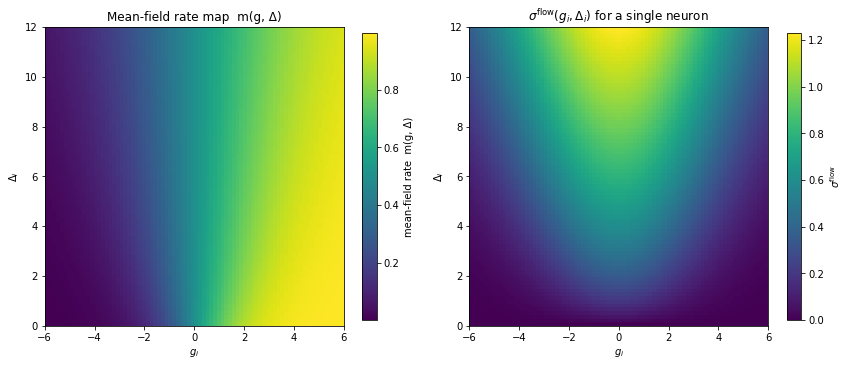

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# def integrate_1DGaussian(f, args=(), Nint=200):
#     x = np.linspace(-1, 1, Nint) * 4
#     dx = x[1] - x[0]
#     phi = np.exp(-0.5 * x**2) / np.sqrt(2*np.pi)
#     return np.sum(f(x, *args) * phi) * dx

def s_integrate_1DGaussian(f, args=(), Nint=200):
    x = np.linspace(-1, 1, Nint) * 4
    dx = x[1] - x[0]
    phi = np.exp(-0.5 * x**2) / np.sqrt(2*np.pi)
    return np.sum(f(x, *args) * phi) * dx

def sigmoid_prime(h):
    return 0.25 / (np.cosh(0.5*h)**2)

# def sigma_flow_single_neuron(g, Delta, Nint=200):
#     if Delta == 0:
#         return 0.0
#     f = lambda z, g, s: sigmoid_prime(g + s*z)
#     expectation = integrate_1DGaussian(f, args=(g, np.sqrt(Delta)), Nint=Nint)
#     return Delta * expectation

def sigma_flow_single_neuron(g, Delta, Nint=200):
    if Delta == 0:
        return 0.0
    f = lambda z, g, s: sigmoid_prime(g + s*z)   # ← これはそのまま
    expectation = s_integrate_1DGaussian(f, args=(g, np.sqrt(Delta)), Nint=Nint)
    return Delta * expectation


# def sigmoid(x):
#     # numerically stable logistic
#     return 0.5 * (1.0 + np.tanh(0.5 * x))

def s_sigmoid(x):
    # numerically stable logistic
    return 0.5 * (1.0 + np.tanh(0.5 * x))


# def mean_rate_single_neuron(g, Delta, Nint=200):
#     """
#     m(g, Δ) = E_Z[ sigmoid(g + sqrt(Δ) * Z) ]
#     """
#     if Delta == 0.0:
#         return float(sigmoid(g))
#     f = lambda z, g, s: sigmoid(g + s*z)
#     return float(integrate_1DGaussian(f, args=(g, np.sqrt(Delta)), Nint=Nint))

def mean_rate_single_neuron(g, Delta, Nint=200):
    """
    m(g, Δ) = E_Z[ sigmoid(g + sqrt(Δ) * Z) ]
    """
    if Delta == 0.0:
        return float(s_sigmoid(g))
    f = lambda z, g, s: s_sigmoid(g + s*z)
    return float(s_integrate_1DGaussian(f, args=(g, np.sqrt(Delta)), Nint=Nint))

# --- Grid and plot ---
g_values = np.linspace(-6, 6, 80)        # x-axis: mean input g
Delta_values = np.linspace(0, 12, 80)     # y-axis: variance Δ (same range as g)

m_map = np.zeros((len(Delta_values), len(g_values)))
for i, Delta in enumerate(Delta_values):
    for j, g in enumerate(g_values):
        m_map[i, j] = mean_rate_single_neuron(g, Delta, Nint=300)

# --- Grid map of g and Delta ---
sigma_map = np.zeros((len(Delta_values), len(g_values)))
for i, Delta in enumerate(Delta_values):
    for j, g in enumerate(g_values):
        sigma_map[i, j] = sigma_flow_single_neuron(g, Delta, Nint=200)

# --- Combined Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
extent = [g_values[0], g_values[-1], Delta_values[0], Delta_values[-1]]

# Left plot: Mean-field rate map
im1 = ax1.imshow(m_map, extent=extent, aspect='auto', origin='lower')
ax1.set_xlabel(r'$g_i$')
ax1.set_ylabel(r'$\Delta_i$')
ax1.set_title('Mean-field rate map  m(g, Δ)')
ax1.set_aspect('equal')
plt.colorbar(im1, ax=ax1, label='mean-field rate  m(g, Δ)', shrink=0.7)

# Right plot: Sigma flow map
im2 = ax2.imshow(sigma_map, extent=extent, aspect='auto', origin='lower',
                 cmap='viridis')
ax2.set_xlabel(r'$g_i$')
ax2.set_ylabel(r'$\Delta_i$')
ax2.set_title(r'$\sigma^{\rm flow}(g_i,\Delta_i)$ for a single neuron')
ax2.set_aspect('equal')
plt.colorbar(im2, ax=ax2, label=r'$\sigma^{\rm flow}$', shrink=0.7)

plt.tight_layout()
plt.show()


In [38]:
import numpy as np

def make_gDelta_background(
    g_range, Delta_range, *, Ng=80, NDelta=80,
    Nint_m=300, Nint_sigma=200
):
   
    g_values     = np.linspace(g_range[0],    g_range[1],    Ng)
    Delta_values = np.linspace(Delta_range[0], Delta_range[1], NDelta)

    m_map     = np.empty((NDelta, Ng), dtype=float)
    sigma_map = np.empty_like(m_map)
    for i, D in enumerate(Delta_values):
        for j, g in enumerate(g_values):
            m_map[i, j]     = mean_rate_single_neuron(g, D, Nint=Nint_m)
            sigma_map[i, j] = sigma_flow_single_neuron(g, D, Nint=Nint_sigma)

    bg = {
        "g_values": g_values,
        "Delta_values": Delta_values,
        "extent": [g_values[0], g_values[-1], Delta_values[0], Delta_values[-1]],
        "m_map": m_map,
        "sigma_map": sigma_map
    }
    return bg


In [39]:
def choose_cbar_limits(
    backgrounds, *,              # list[dict] from make_gDelta_background
    mode="union",                # "auto" | "union" | "fixed" | "quantile"
    fixed_m=None, fixed_sigma=None,
    quantile=99.5
):
   
    if mode == "fixed":
        if fixed_m is None or fixed_sigma is None:
            raise ValueError("mode='fixed' では fixed_m と fixed_sigma が必要です")
        return fixed_m, fixed_sigma

    mm_list = [b["m_map"]     for b in backgrounds]
    ss_list = [b["sigma_map"] for b in backgrounds]

    if mode == "auto":
        m_arr, s_arr = mm_list[0], ss_list[0]
        m_lim = (float(np.nanmin(m_arr)), float(np.nanmax(m_arr)))
        s_lim = (float(np.nanmin(s_arr)), float(np.nanmax(s_arr)))
        return m_lim, s_lim

    # union / quantile
    m_all = np.concatenate([x.ravel() for x in mm_list])
    s_all = np.concatenate([x.ravel() for x in ss_list])

    if mode == "quantile":
        m_low, m_high = np.nanmin(m_all), np.nanpercentile(m_all, quantile)
        s_low, s_high = np.nanmin(s_all), np.nanpercentile(s_all, quantile)
        return (float(m_low), float(m_high)), (float(s_low), float(s_high))

    # union
    return (float(np.nanmin(m_all)), float(np.nanmax(m_all))), \
           (float(np.nanmin(s_all)), float(np.nanmax(s_all)))


def compute_background_vlims(g_range, Delta_range, Ng=120, NDelta=120):
   
    gmin, gmax = g_range; Dmin, Dmax = Delta_range
    g_values     = np.linspace(gmin, gmax, Ng)
    Delta_values = np.linspace(Dmin, Dmax, NDelta)
    m_map = np.empty((len(Delta_values), len(g_values)))
    s_map = np.empty_like(m_map)
    for i, D in enumerate(Delta_values):
        for j, g in enumerate(g_values):
            m_map[i, j] = mean_rate_single_neuron(g, D, Nint=300)
            s_map[i, j] = sigma_flow_single_neuron(g, D, Nint=200)
    
    m_vlim     = (float(np.nanmin(m_map)), float(np.nanmax(m_map)))
    sigma_vlim = (float(np.nanmin(s_map)), float(np.nanmax(s_map)))
    return m_vlim, sigma_vlim


In [40]:
# ==== imports ================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# --------------------
def _background_maps(g_range, Delta_range, Ng=80, NDelta=80,
                     Nint_m=300, Nint_sigma=200):
    g_values     = np.linspace(g_range[0],    g_range[1],    Ng)
    Delta_values = np.linspace(Delta_range[0], Delta_range[1], NDelta)
    m_map     = np.empty((NDelta, Ng), dtype=float)
    sigma_map = np.empty_like(m_map)
    for i, D in enumerate(Delta_values):
        for j, g in enumerate(g_values):
            m_map[i, j]     = mean_rate_single_neuron(g, D, Nint=Nint_m)
            sigma_map[i, j] = sigma_flow_single_neuron(g, D, Nint=Nint_sigma)
    return dict(
        g_values=g_values, Delta_values=Delta_values,
        extent=[g_values[0], g_values[-1], Delta_values[0], Delta_values[-1]],
        m_map=m_map, sigma_map=sigma_map
    )

def _decide_overlay_ranges(
    gA_o=None, DA_o=None, gP_o=None, DP_o=None,
    gA_s=None, DA_s=None, gP_s=None, DP_s=None,
    base_g_range=(-6, 0), base_Delta_range=(0, 0.6), mode="union", pad=0.2
):
    if mode == "fixed":
        gmin, gmax = base_g_range
        dmin, dmax = base_Delta_range
        return float(gmin), float(gmax), max(0.0, float(dmin)), float(dmax)

    g_list = [x for x in [gA_o, gP_o, gA_s, gP_s] if x is not None and np.size(x) > 0]
    d_list = [x for x in [DA_o, DP_o, DA_s, DP_s] if x is not None and np.size(x) > 0]
    if not g_list or not d_list:
        gmin, gmax = base_g_range
        dmin, dmax = base_Delta_range
        return float(gmin), float(gmax), max(0.0, float(dmin)), float(dmax)

    gmin = min(base_g_range[0], *(float(np.nanmin(x)) for x in g_list)) - pad
    gmax = max(base_g_range[1], *(float(np.nanmax(x)) for x in g_list)) + pad
    dmin = min(base_Delta_range[0], *(float(np.nanmin(x)) for x in d_list)) - pad
    dmax = max(base_Delta_range[1], *(float(np.nanmax(x)) for x in d_list)) + pad
    return float(gmin), float(gmax), max(0.0, float(dmin)), float(dmax)

def _compute_background_vlims(g_range, Delta_range, Ng=120, NDelta=120):
    gmin, gmax = g_range; Dmin, Dmax = Delta_range
    g_values     = np.linspace(gmin, gmax, Ng)
    Delta_values = np.linspace(Dmin, Dmax, NDelta)
    m_map = np.empty((len(Delta_values), len(g_values)))
    s_map = np.empty_like(m_map)
    for i, D in enumerate(Delta_values):
        for j, g in enumerate(g_values):
            m_map[i, j] = mean_rate_single_neuron(g, D, Nint=300)
            s_map[i, j] = sigma_flow_single_neuron(g, D, Nint=200)
    return (float(np.nanmin(m_map)), float(np.nanmax(m_map))), \
           (float(np.nanmin(s_map)), float(np.nanmax(s_map)))

# -----
def _as_prob(x, T_loc=None, eps=1e-8):
    x = np.asarray(x, float).reshape(-1)
    if T_loc is not None and np.nanmax(x) > 1.0:
        x = x / float(max(int(T_loc), 1))
    return np.clip(x, eps, 1.0 - eps)

# --------------------
def compute_g_delta_from_means(m_avg, theta_field_mean, theta_coupling_mean):
   
    m = np.asarray(m_avg, float).reshape(-1)
    h = np.asarray(theta_field_mean, float).reshape(-1)
    J = np.asarray(theta_coupling_mean, float)
    g     = h + J @ m
    Delta = (J**2) @ (m * (1.0 - m))
    return np.asarray(g), np.maximum(Delta, 0.0)

def plot_maps_with_mouse_overlay(
    theta_field_mean_act, theta_coupling_mean_act, m_avg_act,
    theta_field_mean_pas, theta_coupling_mean_pas, m_avg_pas,
    *, g_range=(-8, 2), Delta_range=(0, 1), Ng=80, NDelta=80,
    square_axes=True, ax_size=7.0, im_aspect='auto', figure_dpi=300,
    m_vlim=None, sigma_vlim=None,
    title=None, jitter_frac=0.006, seed=1234, marker_size=28, alpha=0.95,
    ticklabel_size=14, label_size=16, title_size=18,
    active_color='red', passive_color='yellow'   # active=赤, passive=黄色
):
    import numpy as np
    import matplotlib.pyplot as plt

    # ------
    gA, DA = compute_g_delta_from_means(m_avg_act, theta_field_mean_act, theta_coupling_mean_act)
    gP, DP = compute_g_delta_from_means(m_avg_pas, theta_field_mean_pas, theta_coupling_mean_pas)

    bg = _background_maps(g_range, Delta_range, Ng=Ng, NDelta=NDelta)
    extent, m_map, sigma_map = bg["extent"], bg["m_map"], bg["sigma_map"]

    rng = np.random.default_rng(seed)
    jgA  = rng.normal(0.0, jitter_frac * (g_range[1]-g_range[0]), size=np.shape(gA))
    jDA  = rng.normal(0.0, jitter_frac * (Delta_range[1]-Delta_range[0]), size=np.shape(DA))
    jgP  = rng.normal(0.0, jitter_frac * (g_range[1]-g_range[0]), size=np.shape(gP))
    jDP  = rng.normal(0.0, jitter_frac * (Delta_range[1]-Delta_range[0]), size=np.shape(DP))

    # -------
    cbar_w = 0.35
    gap_w  = 1.00  
    fig_w  = 2*ax_size + 2*cbar_w + gap_w
    fig_h  = ax_size
    fig = plt.figure(figsize=(fig_w, fig_h), dpi=figure_dpi)
    gs = fig.add_gridspec(nrows=1, ncols=5,
                          width_ratios=[ax_size, cbar_w, gap_w, ax_size, cbar_w],
                          wspace=0.0)
    ax1  = fig.add_subplot(gs[0,0]); cax1 = fig.add_subplot(gs[0,1])
    sp   = fig.add_subplot(gs[0,2]); sp.axis('off')
    ax2  = fig.add_subplot(gs[0,3]); cax2 = fig.add_subplot(gs[0,4])

   
    im1 = ax1.imshow(m_map, extent=extent, origin='lower', aspect=im_aspect)
    im2 = ax2.imshow(sigma_map, extent=extent, origin='lower', aspect=im_aspect, cmap='viridis')
    if m_vlim is not None:     im1.set_clim(*m_vlim)
    if sigma_vlim is not None: im2.set_clim(*sigma_vlim)

    cb1 = fig.colorbar(im1, cax=cax1, label=r'Mean-field rate  $m(g_i,\Delta_i)$')
    cb2 = fig.colorbar(im2, cax=cax2, label=r'Mean-field entropy flow  $\sigma^{\mathrm{flow}}(g_i,\Delta_i)$')


    inner_pad = 0.006
    p = cax1.get_position(); cax1.set_position([p.x0 - inner_pad, p.y0, p.width, p.height])  # 左CB←
    p = cax2.get_position(); cax2.set_position([p.x0 - inner_pad, p.y0, p.width, p.height])  # 右CB←

    cb1.ax.yaxis.labelpad = -2
    cb1.ax.tick_params(pad=1)

    ax2.tick_params(axis='y', pad=6)

    ax1.scatter(gA + jgA, DA + jDA, color=active_color,  marker='o', s=marker_size,
                edgecolors='k', linewidths=0.3, alpha=alpha, label='active',  zorder=3)
    ax1.scatter(gP + jgP, DP + jDP, color=passive_color, marker='o', s=marker_size,
                edgecolors='k', linewidths=0.3, alpha=alpha, label='passive', zorder=3)
    ax2.scatter(gA + jgA, DA + jDA, color=active_color,  marker='o', s=marker_size,
                edgecolors='k', linewidths=0.3, alpha=alpha, label='active',  zorder=3)
    ax2.scatter(gP + jgP, DP + jDP, color=passive_color, marker='o', s=marker_size,
                edgecolors='k', linewidths=0.3, alpha=alpha, label='passive', zorder=3)

    for a in (ax1, ax2):
        a.set_xlim(*g_range); a.set_ylim(*Delta_range)
        if square_axes: a.set_box_aspect(1)
        a.set_xlabel(r'$g_i$', fontsize=label_size)
        a.set_ylabel(r'$\Delta_i$', fontsize=label_size)
        a.tick_params(labelsize=ticklabel_size)
        a.legend(loc='upper left', fontsize=10, frameon=True)

    ax1.text(-0.10, 1.02, 'C', transform=ax1.transAxes, fontsize=title_size,
             fontweight='bold', ha='left', va='bottom', clip_on=False)
    ax2.text(-0.10, 1.02, 'D', transform=ax2.transAxes, fontsize=title_size,
             fontweight='bold', ha='left', va='bottom', clip_on=False)
    ax1.set_title(r'Mean-field rate map  $m(g_i,\Delta_i)$', fontsize=title_size, pad=16)
    ax2.set_title(r'Mean-field entropy flow  $\sigma^{\mathrm{flow}}(g_i,\Delta_i)$',
                  fontsize=title_size, pad=16)

    fig.subplots_adjust(top=0.88, bottom=0.12, left=0.08, right=0.98)

    info = {"gA": np.asarray(gA), "DA": np.asarray(DA),
            "gP": np.asarray(gP), "DP": np.asarray(DP)}
    return fig, info


In [41]:
import numpy as np

def _sig_any_in_window(x_min, x_max, start_bin_1=21, end_bin_1=75):
    
    start = max(start_bin_1 - 1, 0)
    T = x_min.shape[0]
    end = min(end_bin_1, T)
    if start >= end:
        return False
    return np.any((x_min[start:end] > 0) | (x_max[start:end] < 0))


def _select_topk_significant_pairs(theta_s, sigma_s, i, *,
                                   confbound=1.9599639845,
                                   top_k=5,
                                   start_bin_1=21, end_bin_1=75,
                                   ranking_mode='max_margin'):
    
    T, N, P = theta_s.shape
    start = max(start_bin_1 - 1, 0)
    end   = min(end_bin_1, T)

    candidates, scores, label_ixs = [], [], []

    for k in range(N):
        ix = k + 1               # 1..N（0 は一次）
        if ix == i + 1 or ix >= P:
            continue

        sd   = np.sqrt(sigma_s[:, i, ix, ix])
        xmin = theta_s[:, i, ix] - confbound * sd
        xmax = theta_s[:, i, ix] + confbound * sd

        
        if not _sig_any_in_window(xmin, xmax, start_bin_1=start_bin_1, end_bin_1=end_bin_1):
            continue

        
        if ranking_mode == 'max_margin':
            margin_w = np.maximum(xmin[start:end], 0.0) + np.maximum(-xmax[start:end], 0.0)
            score = float(np.max(margin_w))
        elif ranking_mode == 'duration':
            sig_mask_w = (xmin[start:end] > 0) | (xmax[start:end] < 0)
            score = int(np.count_nonzero(sig_mask_w))
        elif ranking_mode == 'max_z':
            sd_safe = np.where(sd > 0, sd, np.inf)
            zexc = np.abs(theta_s[:, i, ix]) / sd_safe - confbound
            score = float(np.max(np.maximum(zexc[start:end], 0.0)))
        elif ranking_mode == 'max_abs':
            score = float(np.max(np.abs(theta_s[start:end, i, ix])))
        elif ranking_mode == 'label_asc':
            score = 0.0  
        else:
            margin_w = np.maximum(xmin[start:end], 0.0) + np.maximum(-xmax[start:end], 0.0)
            score = float(np.max(margin_w))

        candidates.append((ix, xmin, xmax))
        scores.append(score)
        label_ixs.append(ix)

    if not candidates:
        return []

    if ranking_mode == 'label_asc':
        order = np.argsort(np.asarray(label_ixs))[:top_k]     
    else:
        order = np.argsort(-np.asarray(scores))[:top_k]       

    return [candidates[o] for o in order]




def plot_second_order_topk(ax_active, ax_passive,
                           emd_active, emd_passive, i,
                           *, top_k_pairs=5,
                           start_bin_1=21, end_bin_1=75,
                           ranking_mode='max_margin',
                           confbound=1.9599639845,
                           ylim=(-3, 3),
                           fontsize_label=None,
                           fontsize_ticklabel=None,
                           fontsize_legend=None):
    """
    
    """
    # ---
    top_active = _select_topk_significant_pairs(
        emd_active.theta_s, emd_active.sigma_s, i,
        confbound=confbound, top_k=top_k_pairs,
        start_bin_1=start_bin_1, end_bin_1=end_bin_1,
        ranking_mode=ranking_mode
    )
    T = emd_active.theta_s.shape[0]
    x = np.arange(T)

    plotted = False
    for (ix, x_min_a, x_max_a) in top_active:
        ax_active.plot(emd_active.theta_s[:, i, ix], label=f'j={ix}')
        ax_active.fill_between(x, x_min_a, x_max_a, alpha=0.5)
        plotted = True

    ax_active.set_ylim(*ylim)
    ax_active.set_xlim(0, T)
    ax_active.set_title(fr'Coupling parameter $\theta_{{{i+1}j,t}}$',
                        fontsize=(fontsize_label or plt.rcParams.get('axes.titlesize', 12)))
    ax_active.tick_params(axis='both', which='major',
                          labelsize=(fontsize_ticklabel or plt.rcParams.get('xtick.labelsize', 10)))
    
    top_passive = _select_topk_significant_pairs(
        emd_passive.theta_s, emd_passive.sigma_s, i,
        confbound=confbound, top_k=top_k_pairs,
        start_bin_1=start_bin_1, end_bin_1=end_bin_1,
        ranking_mode=ranking_mode
    )
    T_p = emd_passive.theta_s.shape[0]
    x_p = np.arange(T_p)

    plotted = False
    for (ix, x_min_p, x_max_p) in top_passive:
        ax_passive.plot(emd_passive.theta_s[:, i, ix], label=f'j={ix}')
        ax_passive.fill_between(x_p, x_min_p, x_max_p, alpha=0.5)
        plotted = True

    ax_passive.set_ylim(*ylim)
    ax_passive.set_xlim(0, T_p)
    ax_passive.set_title(fr'Coupling parameter $\theta_{{{i+1}j,t}}$',
                         fontsize=(fontsize_label or plt.rcParams.get('axes.titlesize', 12)))
    ax_passive.tick_params(axis='both', which='major',
                           labelsize=(fontsize_ticklabel or plt.rcParams.get('xtick.labelsize', 10)))
    

In [42]:
def create_combined_figure_and_save(
    spikes_ac, spikes_pa, dt, max_time, emd_active, emd_passive,
    selected_neurons, theta_cap_active, theta_cap_passive, T_values,
    theta_active_mean, theta_passive_mean, output_dir,
    
    filename_stub: str = "combined_figure",
    filename_suffix: str = None,
    save_formats=("pdf")
):
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib import gridspec

    
    fontsize_title     = globals().get('fontsize_title', 30)
    fontsize_label     = globals().get('fontsize_label', 25)
    fontsize_legend    = globals().get('fontsize_legend', 20)
    fontsize_ticklabel = globals().get('fontsize_ticklabel', 20)
    fontsize_ABC       = globals().get('fontsize_ABC', 30)

    print("create_combined_figure_and_save function called")
    print(f"emd_active theta_s shape: {emd_active.theta_s.shape}, emd_passive theta_s shape: {emd_passive.theta_s.shape}")
    print(f"theta_cap_active shape: {theta_cap_active.shape}, theta_cap_passive shape: {theta_cap_passive.shape}")
    print(f"selected_neurons: {selected_neurons}, T_values: {T_values}")
    print(f"output_dir: {output_dir}")

    # ----
    def _legend_active_first(ax, loc='best'):
        handles, labels = ax.get_legend_handles_labels()
        lower = [l.lower() for l in labels]
        def _find_idx(keys):
            for k in keys:
                for i, l in enumerate(lower):
                    if k in l:
                        return i
            return None
        ia = _find_idx(['active behavior', 'active'])
        ip = _find_idx(['passive replay', 'passive'])
        order = [i for i in [ia, ip] if i is not None]
        if order:
            ax.legend([handles[i] for i in order], [labels[i] for i in order],
                      fontsize=fontsize_legend, loc=loc, frameon=True)
        else:
            ax.legend(fontsize=fontsize_legend, loc=loc, frameon=True)

    T = int(emd_active.theta_s.shape[0])
    N = int(emd_active.theta_s.shape[1])

    def _normalize_and_align_to_T(spk, T_target):
       
        if spk is None:
            return None
        arr = np.asarray(spk)
        if arr.ndim != 3:
            raise ValueError(f"spikes must be 3D (T,S,N); got shape={arr.shape}")
        if arr.shape[0] != T_target and arr.shape[1] == T_target:
            arr = np.transpose(arr, (1, 0, 2))  # (S,T,N)->(T,S,N)
        if arr.shape[0] > T_target:
            arr = arr[:T_target]
        elif arr.shape[0] < T_target:
            if arr.shape[0] == 0:
                raise ValueError("spikes has zero time length.")
            pad = np.repeat(arr[-1:, :, :], T_target - arr.shape[0], axis=0)
            arr = np.concatenate([arr, pad], axis=0)
        return arr

    
    fig = plt.figure(figsize=(20, 30))
    gs = gridspec.GridSpec(19, 4)

    axs1 = [plt.subplot(gs[0:3, 0:2]), plt.subplot(gs[0:3, 2:4])]
    axs2 = [plt.subplot(gs[4:7, 0]), plt.subplot(gs[8:11, 0])] \
         + [plt.subplot(gs[4:7, i + 1]) for i in range(3)] \
         + [plt.subplot(gs[8:11, i + 1]) for i in range(3)]
    axs3 = [[plt.subplot(gs[12:15, i]), plt.subplot(gs[16:19, i])] for i in range(4)]
    axs3 = np.array(axs3).T

    labels = ['A', 'B', 'C']
    label_x_positions = [0.02, 0.02, 0.02]
    label_y_positions = [0.92, 0.75, 0.4]
    for x, y, label in zip(label_x_positions, label_y_positions, labels):
        ax = fig.add_axes([x, y, .05, .05], frameon=False)
        ax.set_yticks([]); ax.set_xticks([])
        ax.text(0.0, 0.0, label, fontsize=fontsize_ABC, fontweight='bold')

    # ----------
    DEFAULT_COLOR_AC = 'red'
    DEFAULT_COLOR_PA = 'blue'
    time_bins = np.arange(T) * dt  

    if (spikes_ac is not None) and (spikes_pa is not None):
        spikes_ac = _normalize_and_align_to_T(spikes_ac, T)
        spikes_pa = _normalize_and_align_to_T(spikes_pa, T)

        # print(f"spikes_ac aligned shape: {spikes_ac.shape}, spikes_pa aligned shape: {spikes_pa.shape}")

        rate_ac_time = np.mean(np.mean(spikes_ac, axis=1), axis=1) / dt  # (T,)
        rate_pa_time = np.mean(np.mean(spikes_pa, axis=1), axis=1) / dt  # (T,)

        
        axs1[0].bar(time_bins, rate_pa_time, dt,
                    color=DEFAULT_COLOR_PA, edgecolor=DEFAULT_COLOR_PA,
                    alpha=0.5, label='Passive Replay', zorder=1)
        axs1[0].bar(time_bins, rate_ac_time, dt,
                    color=DEFAULT_COLOR_AC, edgecolor=DEFAULT_COLOR_AC,
                    alpha=0.6, label='Active Behavior', zorder=2)
    else:
        axs1[0].text(0.5, 0.5, "spikes not available", ha='center', va='center',
                     fontsize=fontsize_label, transform=axs1[0].transAxes)

    axs1[0].set_ylabel('$p_{\\mathrm{spike}}$', fontsize=fontsize_label)
    axs1[0].set_xlabel('Time [s]', fontsize=fontsize_label)
    axs1[0].set_xlim([0, max_time])  # max_time が T*dt より少し長くても OK
    axs1[0].tick_params(axis='both', which='major', labelsize=fontsize_ticklabel, colors='black')
    _legend_active_first(axs1[0], loc='upper right')

    # -----------
    if (spikes_ac is not None) and (spikes_pa is not None):
        rate_ac_neuron = np.mean(spikes_ac, axis=(0, 1)) / dt  # (N,)
        rate_pa_neuron = np.mean(spikes_pa, axis=(0, 1)) / dt  # (N,)
        bins = np.histogram_bin_edges(np.concatenate([rate_ac_neuron, rate_pa_neuron]), bins='fd')

        axs1[1].hist(rate_pa_neuron, bins=bins,
                     color=DEFAULT_COLOR_PA, edgecolor=DEFAULT_COLOR_PA,
                     alpha=0.5, label='Passive Replay', zorder=1)
        axs1[1].hist(rate_ac_neuron, bins=bins,
                     color=DEFAULT_COLOR_AC, edgecolor=DEFAULT_COLOR_AC,
                     alpha=0.6, label='Active Behavior', zorder=2)
    else:
        axs1[1].text(0.5, 0.5, "spikes not available", ha='center', va='center',
                     fontsize=fontsize_label, transform=axs1[1].transAxes)

    axs1[1].set_ylabel('Neurons', fontsize=fontsize_label)
    axs1[1].set_xlabel('Spike rate [spikes/s]', fontsize=fontsize_label)
    axs1[1].set_xlim([0, 25])
    axs1[1].tick_params(axis='both', which='major', labelsize=fontsize_ticklabel)
    _legend_active_first(axs1[1], loc='upper right')

    # -----------
    num_neurons = N
    T_for_param = T

   
    if N >= 80:
        idx_iter = range(69, 80)
    else:
        idx_iter = range(N)  # 小規模データは全ニューロンを重ね描き

    for i in idx_iter:
        axs2[0].plot(emd_active.theta_s[:, i, 0])
        x_min_active = emd_active.theta_s[:, i, 0] - 1.645 * np.sqrt(emd_active.sigma_s[:, i, 0, 0])
        x_max_active = emd_active.theta_s[:, i, 0] + 1.645 * np.sqrt(emd_active.sigma_s[:, i, 0, 0])
        axs2[0].fill_between(range(T_for_param), x_min_active, x_max_active, alpha=0.2)

    axs2[0].set_title(r'Field parameters $\theta_{i,t}$', fontsize=fontsize_label)
    axs2[0].set_xlabel("Time", fontsize=fontsize_label)
    axs2[0].set_ylabel('Active', fontsize=fontsize_label, rotation=90, labelpad=20)
    axs2[0].set_ylim([-4.5, 1.5])
    axs2[0].set_xlim([0, T_for_param])
    axs2[0].tick_params(axis='both', which='major', labelsize=fontsize_ticklabel)

    
    for i in idx_iter:
        axs2[1].plot(emd_passive.theta_s[:, i, 0])
        x_min_passive = emd_passive.theta_s[:, i, 0] - 1.645 * np.sqrt(emd_passive.sigma_s[:, i, 0, 0])
        x_max_passive = emd_passive.theta_s[:, i, 0] + 1.645 * np.sqrt(emd_passive.sigma_s[:, i, 0, 0])
        axs2[1].fill_between(range(T_for_param), x_min_passive, x_max_passive, alpha=0.2)

    axs2[1].set_title(r'Field parameters $\theta_{i,t}$', fontsize=fontsize_label)
    axs2[1].set_xlabel("Time", fontsize=fontsize_label)
    axs2[1].set_ylabel('Passive', fontsize=fontsize_label, rotation=90, labelpad=20)
    axs2[1].set_ylim([-4.5, 1.5])
    axs2[1].set_xlim([0, T_for_param])
    axs2[1].tick_params(axis='both', which='major', labelsize=fontsize_ticklabel)

   
    blocks = min(3, len(selected_neurons)) 
    for idx in range(blocks):
        i = int(selected_neurons[idx])
        if not (0 <= i < N):
            continue
        ax_ac = axs2[idx + 2]
        ax_pa = axs2[idx + 2 + 3] 
        plot_second_order_topk(
            ax_ac, ax_pa,
            emd_active, emd_passive, i,
            top_k_pairs=5,
            start_bin_1=21, end_bin_1=min(75, T_for_param),
            ranking_mode='label_asc',
            confbound=1.0,
            ylim=(-1, 1),
            fontsize_label=fontsize_label,
            fontsize_ticklabel=fontsize_ticklabel,
            fontsize_legend=fontsize_legend
        )

    # -----------
    vmin = min(theta_active_mean.min(), theta_passive_mean.min())
    vmax = max(theta_active_mean.max(), theta_passive_mean.max())
    vmin, vmax = -1, 1  

    im = None
    
    T_values = [max(0, min(T-1, int(t))) for t in T_values]
    for i in range(4):
        im = axs3[0][i].imshow(theta_cap_active[T_values[i]], cmap='coolwarm', aspect='auto', vmin=vmin, vmax=vmax)
        axs3[0][i].set_title(f'Coupling parameter at t={T_values[i]}', fontsize=fontsize_ticklabel)

        axs3[0][i].set_xticks([0, N - 1]); axs3[0][i].set_xticklabels([1, N], fontsize=fontsize_ticklabel)
        axs3[0][i].set_yticks([0, N - 1]); axs3[0][i].set_yticklabels([1, N], fontsize=fontsize_ticklabel)

        if i == 0:
            axs3[0][i].set_xlabel('Neuron', fontsize=fontsize_ticklabel)
            axs3[0][i].set_ylabel('Neuron', fontsize=fontsize_ticklabel)

        axs3[0][i].tick_params(axis='both', which='major', labelsize=fontsize_ticklabel)

        axs3[1][i].imshow(theta_cap_passive[T_values[i]], cmap='coolwarm', aspect='auto', vmin=vmin, vmax=vmax)
        axs3[1][i].set_title(f'Coupling parameter at t={T_values[i]}', fontsize=fontsize_ticklabel)
        axs3[1][i].set_xticks([0, N - 1]); axs3[1][i].set_xticklabels([1, N], fontsize=fontsize_ticklabel)
        axs3[1][i].set_yticks([0, N - 1]); axs3[1][i].set_yticklabels([1, N], fontsize=fontsize_ticklabel)

        if i == 0:
            axs3[1][i].set_xlabel('Neuron', fontsize=fontsize_ticklabel)
            axs3[1][i].set_ylabel('Neuron', fontsize=fontsize_ticklabel)

        axs3[1][i].tick_params(axis='both', which='major', labelsize=fontsize_ticklabel)

   
    cax = axs3[0][3].figure.add_axes([0.97, 0.1, 0.01, 0.3])
    plt.colorbar(im, cax=cax, orientation='vertical')


    plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1, wspace=0.4, hspace=1.0)

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    suffix = f" — {filename_suffix}" if filename_suffix else ""
    for ext in save_formats:
        plt.savefig(os.path.join(output_dir, f"{filename_stub}{suffix}.{ext}"), bbox_inches='tight', dpi=300)

    plt.close(fig)  


In [43]:
def Function_to_calculate_all_parameters(
    base_dir,
    experience_levels_images,
    max_lengths,
    n,
    target_mouse_ids,
    familiar_g,
    novel_h
):
    

    # ---- imports ----
    import os
    import pickle
    import numpy as np
    import matplotlib.pyplot as plt
    from dataclasses import dataclass

    # ---- style globals ----
    global fontsize_title, fontsize_label, fontsize_legend, fontsize_ticklabel, fontsize_ABC
    fontsize_title = 30
    fontsize_label = 25
    fontsize_legend = 20
    fontsize_ticklabel = 20
    fontsize_ABC = 30

    # ---- overlay defaults ----
    overlay_mode = "union"        # 'union' or 'fixed'
    overlay_g_range = (-6, 0)
    overlay_delta_range = (0, 0.6)
    overlay_pad = 0.2
    overlay_clip_points = True  # for downstream use if needed

   
    overlay_background = make_gDelta_background(overlay_g_range, overlay_delta_range, Ng=80, NDelta=80)
    _ = choose_cbar_limits([overlay_background], mode="auto")

    # ---- cache dirs ----
    cache_dir_orig = os.path.join(base_dir, 'saved_results')
    cache_dir_shuf = os.path.join(base_dir, 'saved_results_shuffle')
    os.makedirs(cache_dir_orig, exist_ok=True)
    os.makedirs(cache_dir_shuf, exist_ok=True)

    # -------------
    @dataclass(frozen=True)
    class CacheContext:
        mouse_id: str
        experience_level: str
        group_name: str
        image: str
        max_length: int
        n: int

    def _result_path(which, mouse_id, exp, grp, img, maxlen, n_):
        base = cache_dir_orig if which == 'orig' else cache_dir_shuf
        return os.path.join(base, f'results_{mouse_id}_{exp}_{grp}_{img}_{maxlen}_n{n_}.pkl')

    def _safe_pickle_dump(path, payload):
        """原子的に pickle 保存（tmp → replace）"""
        tmp = path + ".tmp"
        with open(tmp, 'wb') as f:
            pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)
        os.replace(tmp, path)

    def _load_cached(path: str, ctx: CacheContext = None):
       
        if not os.path.exists(path):
            return None, None
        try:
            with open(path, 'rb') as f:
                obj = pickle.load(f)
        except Exception as e:
            print(f"[cache] failed to load {path}: {e}")
            return None, None

        if isinstance(obj, dict):
            ea, ep = obj.get('emd_active'), obj.get('emd_passive')
            if (ea is not None) and (ep is not None):
                return ea, ep
            print(f"[cache] malformed payload (no emd_active/emd_passive): {path}")
            return None, None

        if isinstance(obj, tuple) and len(obj) == 2:
            return obj[0], obj[1]

        print(f"[cache] unexpected payload type: {type(obj)} @ {path}")
        return None, None

    def _compute_and_cache(path: str, spikes_like, T, N, ctx: CacheContext):
       
        if spikes_like is None:
            return None, None
        emd_active, emd_passive = calculate_emd_results(spikes_like, T, N, ctx.n)
        if (emd_active is None) or (emd_passive is None):
            return None, None
        payload = {'emd_active': emd_active, 'emd_passive': emd_passive}
        try:
            _safe_pickle_dump(path, payload)
        except Exception as e:
            print(f"[cache] WARNING: failed to write cache {path}: {e}")
        return emd_active, emd_passive

    # ---------------
    def _new_aggregate_dict():
        return {
            'mouse_id': [],
            'total_entropy_flow_active': [],
            'total_entropy_flow_passive': [],
            'field_param_variance_active': [],
            'field_param_variance_passive': [],
            'coupling_param_variance_active': [],
            'coupling_param_variance_passive': [],
            'mean_effective_coupling_active': [],
            'mean_effective_coupling_passive': [],
            'spike_prob_sum_T_active': [],
            'spike_prob_sum_T_passive': [],
            'entropy_flow_active_per_neuron_sum_over_time': [],
            'entropy_flow_passive_per_neuron_sum_over_time': [],
            'coupling_asymmetry_active': [],
            'coupling_asymmetry_passive': [],
        }

    def _append_mouse_metrics_to_agg(agg, mouse_id, metrics_new):
        m = metrics_new
        agg['mouse_id'].append(mouse_id)
        agg['total_entropy_flow_active'].append(m['total_entropy_flow_active'])
        agg['total_entropy_flow_passive'].append(m['total_entropy_flow_passive'])
        agg['field_param_variance_active'].append(m['field_param_variance_active'])
        agg['field_param_variance_passive'].append(m['field_param_variance_passive'])
        agg['coupling_param_variance_active'].append(m['coupling_param_variance_active'])
        agg['coupling_param_variance_passive'].append(m['coupling_param_variance_passive'])
        agg['spike_prob_sum_T_active'].append(m['spike_prob_sum_T_active'])
        agg['spike_prob_sum_T_passive'].append(m['spike_prob_sum_T_passive'])
        agg['entropy_flow_active_per_neuron_sum_over_time'].append(m['entropy_flow_active_per_neuron_sum_over_time'])
        agg['entropy_flow_passive_per_neuron_sum_over_time'].append(m['entropy_flow_passive_per_neuron_sum_over_time'])
        agg['coupling_asymmetry_active'].append(m['coupling_asymmetry_active'])
        agg['coupling_asymmetry_passive'].append(m['coupling_asymmetry_passive'])
        agg['mean_effective_coupling_active'].append(m['mean_effective_coupling_active'])
        agg['mean_effective_coupling_passive'].append(m['mean_effective_coupling_passive'])

    def _metrics(emd_active, emd_passive):

        if emd_active is None or emd_passive is None:
            return None
        T, N = emd_active.T, emd_active.N

        var_fields_act, var_fields_pas, var_cpl_act, var_cpl_pas = calculate_variances(emd_active, emd_passive, T, N)
        s_dict = summarize_entropy_flow(emd_active, emd_passive, T, N)

        (
            theta_field_act, theta_field_pas,
            theta_cap_act,   theta_cap_pas,
            theta_field_timeavg_active_target, theta_field_timeavg_passive_target,
            theta_coupling_timeavg_active_target, theta_coupling_timeavg_passive_target,
            mean_corr_act_tgt, mean_corr_pas_tgt,
            neuron_pairs_act_tgt, neuron_pairs_pas_tgt,
            coupling_asymmetry_active, coupling_asymmetry_passive
        ) = calculate_correlations_and_pairs(emd_active, emd_passive, T, N)

        mean_effective_coupling_active, mean_effective_coupling_passive = calculate_coupling_means(emd_active, emd_passive)

        out = {
            # --- 集計用（新キー） ---
            'field_param_variance_active': var_fields_act,
            'field_param_variance_passive': var_fields_pas,
            'coupling_param_variance_active': var_cpl_act,
            'coupling_param_variance_passive': var_cpl_pas,
            'entropy_flow_active_per_neuron_sum_over_time': s_dict['entropy_flow_active_per_neuron_sum_over_time'],
            'entropy_flow_passive_per_neuron_sum_over_time': s_dict['entropy_flow_passive_per_neuron_sum_over_time'],
            'total_entropy_flow_active': s_dict['total_entropy_flow_active'],
            'total_entropy_flow_passive': s_dict['total_entropy_flow_passive'],
            'spike_prob_sum_T_active': s_dict['spike_prob_sum_T_active'],
            'spike_prob_sum_T_passive': s_dict['spike_prob_sum_T_passive'],
            'coupling_asymmetry_active': coupling_asymmetry_active,
            'coupling_asymmetry_passive': coupling_asymmetry_passive,
            'mean_effective_coupling_active': mean_effective_coupling_active,
            'mean_effective_coupling_passive': mean_effective_coupling_passive,

            # --- ターゲット可視化素材（2x2/3x3 用；新キー） ---
            'entropy_flow_active_timeseries_sum_over_neurons':  s_dict['entropy_flow_active_timeseries_sum_over_neurons'],
            'entropy_flow_passive_timeseries_sum_over_neurons': s_dict['entropy_flow_passive_timeseries_sum_over_neurons'],
            'forward_conditional_entropy_active_timeseries_sum_over_neurons':  s_dict['forward_conditional_entropy_active_timeseries_sum_over_neurons'],
            'forward_conditional_entropy_passive_timeseries_sum_over_neurons': s_dict['forward_conditional_entropy_passive_timeseries_sum_over_neurons'],
            'backward_conditional_entropy_active_timeseries_sum_over_neurons': s_dict['backward_conditional_entropy_active_timeseries_sum_over_neurons'],
            'backward_conditional_entropy_passive_timeseries_sum_over_neurons': s_dict['backward_conditional_entropy_passive_timeseries_sum_over_neurons'],
            'theta_field_timeavg_active_target':    theta_field_timeavg_active_target,
            'theta_field_timeavg_passive_target':   theta_field_timeavg_passive_target,
            'theta_coupling_timeavg_active_target': theta_coupling_timeavg_active_target,
            'theta_coupling_timeavg_passive_target':theta_coupling_timeavg_passive_target,
            'mean_correlation_active_target':  mean_corr_act_tgt,
            'mean_correlation_passive_target': mean_corr_pas_tgt,
            'neuron_pairs_active_target': neuron_pairs_act_tgt,
            'neuron_pairs_passive_target': neuron_pairs_pas_tgt,
            'spike_prob_timeseries_sum_over_neurons_active':  s_dict['spike_prob_timeseries_sum_over_neurons_active'],
            'spike_prob_timeseries_sum_over_neurons_passive': s_dict['spike_prob_timeseries_sum_over_neurons_passive'],
        }
        return out

    def _build_special_target_dict(metrics, include_asym=True):
        
        d = {
            # ----
            'entropy_flow_active_timeseries':   metrics['entropy_flow_active_timeseries_sum_over_neurons'],
            'entropy_flow_passive_timeseries':  metrics['entropy_flow_passive_timeseries_sum_over_neurons'],
            'forward_conditional_entropy_active_timeseries':   metrics['forward_conditional_entropy_active_timeseries_sum_over_neurons'],
            'forward_conditional_entropy_passive_timeseries':  metrics['forward_conditional_entropy_passive_timeseries_sum_over_neurons'],
            'backward_conditional_entropy_active_timeseries':  metrics['backward_conditional_entropy_active_timeseries_sum_over_neurons'],
            'backward_conditional_entropy_passive_timeseries': metrics['backward_conditional_entropy_passive_timeseries_sum_over_neurons'],

            # ----
            'mean_field_params_active_target':     metrics['theta_field_timeavg_active_target'],
            'mean_field_params_passive_target':    metrics['theta_field_timeavg_passive_target'],
            'mean_coupling_params_active_target':  metrics['theta_coupling_timeavg_active_target'],
            'mean_coupling_params_passive_target': metrics['theta_coupling_timeavg_passive_target'],

            # ----
            'mean_correlation_active_target':   metrics['mean_correlation_active_target'],
            'mean_correlation_passive_target':  metrics['mean_correlation_passive_target'],
            'neuron_pairs_active_target':       metrics['neuron_pairs_active_target'],
            'neuron_pairs_passive_target':      metrics['neuron_pairs_passive_target'],

            # ----
            'population_mean_spike_prob_ts_active':  metrics['spike_prob_timeseries_sum_over_neurons_active'],
            'population_mean_spike_prob_ts_passive': metrics['spike_prob_timeseries_sum_over_neurons_passive'],

            # ----
            'spike_prob_sum_T_active':  metrics['spike_prob_sum_T_active'],
            'spike_prob_sum_T_passive': metrics['spike_prob_sum_T_passive'],
        }
        if include_asym:
            d['coupling_asymmetry_active']  = metrics['coupling_asymmetry_active']
            d['coupling_asymmetry_passive'] = metrics['coupling_asymmetry_passive']
        return d

    def _pick_first_emd(*emd_lists):
        for lst in emd_lists:
            if lst and lst[0] is not None:
                return lst[0]
        return None

    # =========================
   
    # =========================
    for max_length in max_lengths:
        
        outdir_root = os.path.join('fig', 'im03', f'maxlen{max_length}', 'rat_comparison')
        os.makedirs(outdir_root, exist_ok=True)

        for experience_level, group_dict in experience_levels_images.items():
           
            if experience_level == 'Familiar' and 'G' in group_dict:
                candidate_mouse_ids = familiar_g
            elif experience_level == 'Novel' and 'H' in group_dict:
                candidate_mouse_ids = novel_h
            else:
                print(f"[Warning] 条件 {experience_level} に対応する mouse_ids が定義されていません。")
                continue

            for group_name, specific_images in group_dict.items():
                print(f"Processing {experience_level} - {group_name}: Images {specific_images}, max_length {max_length}")

                for specific_image in specific_images:
                    print(f"  Processing Image: {specific_image}")

                    outdir_image = os.path.join(outdir_root, experience_level, group_name, specific_image)
                    os.makedirs(outdir_image, exist_ok=True)

                    aggregate_metrics_orig = _new_aggregate_dict()
                    aggregate_metrics_shuf = _new_aggregate_dict()

                    lite_series_orig, lite_series_shuf = [], []
                    emd_active_orig, emd_passive_orig = [], []
                    emd_active_shuf, emd_passive_shuf = [], []
                    valid_ids_orig, valid_ids_shuf = [], []

                    target_materials_orig, target_materials_shuf = {}, {}

                    # ========
                    for mouse_id in candidate_mouse_ids:
                        ctx = CacheContext(
                            mouse_id=str(mouse_id),
                            experience_level=str(experience_level),
                            group_name=str(group_name),
                            image=str(specific_image),
                            max_length=int(max_length),
                            n=int(n),
                        )
                        cache_path_orig = _result_path('orig', ctx.mouse_id, ctx.experience_level, ctx.group_name, ctx.image, ctx.max_length, ctx.n)
                        cache_path_shuf = _result_path('shuf', ctx.mouse_id, ctx.experience_level, ctx.group_name, ctx.image, ctx.max_length, ctx.n)

                    
                        emd_a_o, emd_p_o = _load_cached(cache_path_orig, ctx)
                        emd_a_s, emd_p_s = _load_cached(cache_path_shuf, ctx)
                        has_orig_cache = (emd_a_o is not None and emd_p_o is not None)
                        has_shuf_cache = (emd_a_s is not None and emd_p_s is not None)


                        spikes_orig = spikes_shuf = T = N = None
                        need_compute_orig = not has_orig_cache
                        need_compute_shuf = not has_shuf_cache
                        if (need_compute_orig or need_compute_shuf):
                            try:
                                spikes_orig, spikes_shuf, T, N = load_and_process_data(
                                    base_dir, ctx.mouse_id, ctx.experience_level, ctx.group_name, ctx.image, ctx.max_length, ctx.n
                                )
                            except Exception as e:
                                print("[DATA] load_and_process_data failed:", e)


                        if need_compute_orig:
                            try:
                                emd_a_o, emd_p_o = _compute_and_cache(cache_path_orig, spikes_orig, T, N, ctx)
                                if emd_a_o is not None and emd_p_o is not None:
                                    has_orig_cache = True
                                    print(f"[ORIGINAL] Computed & saved EMD for mouse {ctx.mouse_id} → {cache_path_orig}")
                            except Exception as e:
                                print("[ORIGINAL] Recompute failed:", e)

                        if need_compute_shuf:
                            try:
                                emd_a_s, emd_p_s = _compute_and_cache(cache_path_shuf, spikes_shuf, T, N, ctx)
                                if emd_a_s is not None and emd_p_s is not None:
                                    has_shuf_cache = True
                                    print(f"[SHUFFLE]  Computed & saved EMD for mouse {ctx.mouse_id} → {cache_path_shuf}")
                            except Exception as e:
                                print("[SHUFFLE] Recompute failed:", e)

                       
                        if has_orig_cache:
                            print(f"[ORIGINAL] Loaded EMD for mouse {ctx.mouse_id} ({ctx.experience_level}/{ctx.group_name}/{ctx.image})")
                            emd_active_orig.append(emd_a_o)
                            emd_passive_orig.append(emd_p_o)
                            valid_ids_orig.append(ctx.mouse_id)

                            metrics_o = _metrics(emd_a_o, emd_p_o)
                            if metrics_o is not None:
                                
                                print(
                                    "len(eA), len(eP), len(mA), len(mP) =",
                                    len(metrics_o['entropy_flow_active_timeseries_sum_over_neurons']),
                                    len(metrics_o['entropy_flow_passive_timeseries_sum_over_neurons']),
                                    len(metrics_o['spike_prob_timeseries_sum_over_neurons_active']),
                                    len(metrics_o['spike_prob_timeseries_sum_over_neurons_passive']),
                                )

                                _append_mouse_metrics_to_agg(aggregate_metrics_orig, ctx.mouse_id, metrics_o)
                                if ctx.mouse_id in target_mouse_ids:
                                    target_materials_orig[ctx.mouse_id] = _build_special_target_dict(metrics_o, include_asym=False)

                                lite_series_orig.append({
                                    'entropy_flow_active_timeseries':   metrics_o['entropy_flow_active_timeseries_sum_over_neurons'],
                                    'entropy_flow_passive_timeseries':  metrics_o['entropy_flow_passive_timeseries_sum_over_neurons'],
                                    'forward_conditional_entropy_active_timeseries':   metrics_o['forward_conditional_entropy_active_timeseries_sum_over_neurons'],
                                    'forward_conditional_entropy_passive_timeseries':  metrics_o['forward_conditional_entropy_passive_timeseries_sum_over_neurons'],
                                    'backward_conditional_entropy_active_timeseries':  metrics_o['backward_conditional_entropy_active_timeseries_sum_over_neurons'],
                                    'backward_conditional_entropy_passive_timeseries': metrics_o['backward_conditional_entropy_passive_timeseries_sum_over_neurons'],
                                    'population_mean_spike_prob_ts_active':  metrics_o['spike_prob_timeseries_sum_over_neurons_active'],
                                    'population_mean_spike_prob_ts_passive': metrics_o['spike_prob_timeseries_sum_over_neurons_passive'],
                                })

            
                        if has_shuf_cache:
                            print(f"[SHUFFLE]  Loaded EMD for mouse {ctx.mouse_id} ({ctx.experience_level}/{ctx.group_name}/{ctx.image})")
                            emd_active_shuf.append(emd_a_s)
                            emd_passive_shuf.append(emd_p_s)
                            valid_ids_shuf.append(ctx.mouse_id)

                            metrics_s = _metrics(emd_a_s, emd_p_s)
                            if metrics_s is not None:
                                _append_mouse_metrics_to_agg(aggregate_metrics_shuf, ctx.mouse_id, metrics_s)
                                if ctx.mouse_id in target_mouse_ids:
                                    target_materials_shuf[ctx.mouse_id] = _build_special_target_dict(metrics_s, include_asym=True)

                                lite_series_shuf.append({
                                    'entropy_flow_active_timeseries':   metrics_s['entropy_flow_active_timeseries_sum_over_neurons'],
                                    'entropy_flow_passive_timeseries':  metrics_s['entropy_flow_passive_timeseries_sum_over_neurons'],
                                    'forward_conditional_entropy_active_timeseries':   metrics_s['forward_conditional_entropy_active_timeseries_sum_over_neurons'],
                                    'forward_conditional_entropy_passive_timeseries':  metrics_s['forward_conditional_entropy_passive_timeseries_sum_over_neurons'],
                                    'backward_conditional_entropy_active_timeseries':  metrics_s['backward_conditional_entropy_active_timeseries_sum_over_neurons'],
                                    'backward_conditional_entropy_passive_timeseries': metrics_s['backward_conditional_entropy_passive_timeseries_sum_over_neurons'],
                                    'population_mean_spike_prob_ts_active':  metrics_s['spike_prob_timeseries_sum_over_neurons_active'],
                                    'population_mean_spike_prob_ts_passive': metrics_s['spike_prob_timeseries_sum_over_neurons_passive'],
                                })
                                
                                # ====
                                if ctx.mouse_id in (set(target_mouse_ids) if target_mouse_ids else set()):
                                   
                                    dt_local = globals().get('dt', 0.01)
                                    max_time_local = float(ctx.max_length) * float(dt_local)

                                    if (spikes_orig is None) or (spikes_shuf is None):
                                        try:
                                            spikes_orig, spikes_shuf, T_ld, N_ld = load_and_process_data(
                                                base_dir, ctx.mouse_id, ctx.experience_level, ctx.group_name,
                                                ctx.image, ctx.max_length, ctx.n
                                            )
                                        except Exception as e:
                                            print(f"[COMBINED] reload spikes failed for {ctx.mouse_id}: {e}")
                                            spikes_orig = spikes_shuf = None

                                    def _split_spikes(spikes_like):
                                        import numpy as np
                                        if spikes_like is None:
                                            return None, None
                                        if isinstance(spikes_like, dict):
                                            # よくあるキーの候補
                                            ac = None; pa = None
                                            for k in spikes_like.keys():
                                                lk = k.lower()
                                                if lk in ('active','ac','orig_active','behavior'):
                                                    ac = spikes_like[k]
                                                if lk in ('passive','pa','replay'):
                                                    pa = spikes_like[k]
                                            return ac, pa
                                        if isinstance(spikes_like, (list, tuple)) and len(spikes_like) >= 2:
                                            return spikes_like[0], spikes_like[1]
                                        
                                        return None, None

                                    ref_for_TN = emd_a_o if has_orig_cache else (emd_a_s if has_shuf_cache else None)
                                    if ref_for_TN is None:
                                        print(f"[COMBINED] no EMD to render for {ctx.mouse_id}")
                                    else:
                                        T_ref = int(getattr(ref_for_TN, "T", ref_for_TN.theta_s.shape[0]))
                                        N_ref = int(getattr(ref_for_TN, "N", ref_for_TN.theta_s.shape[1]))

                                        sel_neurons_base = [0, 1, 79]
                                        selected_neurons_local = [i for i in sel_neurons_base if 0 <= i < N_ref]
                                        T_values_local = [max(0, min(T_ref-1, t)) for t in [5, 25, 35, 50]]

                                        # =======
                                        if has_orig_cache:
                                            
                                            (_th_f_act, _th_f_pas,
                                             theta_cap_active_o, theta_cap_passive_o,
                                             _th_field_mean_act, _th_field_mean_pas,
                                             theta_cap_active_mean_o, theta_cap_passive_mean_o,
                                             *_rest) = calculate_correlations_and_pairs(emd_a_o, emd_p_o, T_ref, N_ref)

                                           
                                            sp_ac_o, sp_pa_o = _split_spikes(spikes_orig)
                                            
                                            create_combined_figure_and_save(
                                                spikes_ac=sp_ac_o, spikes_pa=sp_pa_o,
                                                dt=dt_local, max_time=max_time_local,
                                                emd_active=emd_a_o, emd_passive=emd_p_o,
                                                selected_neurons=selected_neurons_local,
                                                theta_cap_active=theta_cap_active_o, theta_cap_passive=theta_cap_passive_o,
                                                T_values=T_values_local,
                                                theta_active_mean=theta_cap_active_mean_o,
                                                theta_passive_mean=theta_cap_passive_mean_o,
                                                output_dir=outdir_image,
                                                filename_stub=f"Fig 6. Estimated neural dynamics under the active and passive conditions for mouse {ctx.mouse_id}",
                                                filename_suffix=None,
                                                save_formats=("pdf",)   
                                            )


                                        # ========
                                        if has_shuf_cache:
                                            (_th_f_act_s, _th_f_pas_s,
                                             theta_cap_active_s, theta_cap_passive_s,
                                             _th_field_mean_act_s, _th_field_mean_pas_s,
                                             theta_cap_active_mean_s, theta_cap_passive_mean_s,
                                             *_rest_s) = calculate_correlations_and_pairs(emd_a_s, emd_p_s, T_ref, N_ref)

                                            sp_ac_s, sp_pa_s = _split_spikes(spikes_shuf)

                                            create_combined_figure_and_save(
                                                spikes_ac=sp_ac_s, spikes_pa=sp_pa_s,
                                                dt=dt_local, max_time=max_time_local,
                                                emd_active=emd_a_s, emd_passive=emd_p_s,
                                                selected_neurons=selected_neurons_local,
                                                theta_cap_active=theta_cap_active_s, theta_cap_passive=theta_cap_passive_s,
                                                T_values=T_values_local,
                                                theta_active_mean=theta_cap_active_mean_s,
                                                theta_passive_mean=theta_cap_passive_mean_s,
                                                output_dir=outdir_image,
                                                filename_stub=f"Fig 6. Estimated neural dynamics under the active and passive conditions for mouse {ctx.mouse_id} (SHUFFLE)",
                                                filename_suffix=None,
                                                save_formats=("pdf",)   # ← ここも
                                            )


                    # ======
                    available_for_overlay = set(target_materials_orig.keys()) | set(target_materials_shuf.keys())
                    requested_targets = set(target_mouse_ids) if target_mouse_ids else set()
                    overlay_target_ids = sorted(list(available_for_overlay & (requested_targets or available_for_overlay)))

                    if not overlay_target_ids:
                        print("[OVERLAY] No eligible targets for",
                              f"{experience_level}/{group_name}/{specific_image}.",
                              "requested=", sorted(list(requested_targets)),
                              "available=", sorted(list(available_for_overlay)))

                    
                    ref_for_avg = _pick_first_emd(emd_active_orig, emd_passive_orig, emd_active_shuf, emd_passive_shuf)
                    T_for_avg = int(getattr(ref_for_avg, "T", max_length)) if ref_for_avg is not None else int(max_length)
                    eps = 1e-8

                    for target_id in overlay_target_ids:
                       
                        g_active_orig = g_passive_orig = delta_active_orig = delta_passive_orig = None
                        mA_orig = mP_orig = None
                        if target_id in target_materials_orig:
                            d = target_materials_orig[target_id]
                            mA_orig = np.clip(np.asarray(d['spike_prob_sum_T_active']).reshape(-1)  / T_for_avg, eps, 1.0 - eps)
                            mP_orig = np.clip(np.asarray(d['spike_prob_sum_T_passive']).reshape(-1) / T_for_avg,  eps, 1.0 - eps)
                            hA = np.asarray(d['mean_field_params_active_target'])
                            JA = np.asarray(d['mean_coupling_params_active_target'])
                            hP = np.asarray(d['mean_field_params_passive_target'])
                            JP = np.asarray(d['mean_coupling_params_passive_target'])
                            g_active_orig,  delta_active_orig  = compute_g_delta_from_means(mA_orig, hA, JA)
                            g_passive_orig, delta_passive_orig = compute_g_delta_from_means(mP_orig, hP, JP)

                        
                        g_active_shuf = g_passive_shuf = delta_active_shuf = delta_passive_shuf = None
                        mA_shuf = mP_shuf = None
                        if target_id in target_materials_shuf:
                            d = target_materials_shuf[target_id]
                            mA_shuf = np.clip(np.asarray(d['spike_prob_sum_T_active']).reshape(-1)  / T_for_avg, eps, 1.0 - eps)
                            mP_shuf = np.clip(np.asarray(d['spike_prob_sum_T_passive']).reshape(-1) / T_for_avg,  eps, 1.0 - eps)
                            hA = np.asarray(d['mean_field_params_active_target'])
                            JA = np.asarray(d['mean_coupling_params_active_target'])
                            hP = np.asarray(d['mean_field_params_passive_target'])
                            JP = np.asarray(d['mean_coupling_params_passive_target'])
                            g_active_shuf,  delta_active_shuf  = compute_g_delta_from_means(mA_shuf, hA, JA)
                            g_passive_shuf, delta_passive_shuf = compute_g_delta_from_means(mP_shuf, hP, JP)

                       
                        gmin, gmax, dmin, dmax = _decide_overlay_ranges(
                            g_active_orig,  delta_active_orig,  g_passive_orig,  delta_passive_orig,
                            g_active_shuf,  delta_active_shuf,  g_passive_shuf,  delta_passive_shuf,
                            base_g_range=overlay_g_range,
                            base_Delta_range=overlay_delta_range,
                            mode=("fixed" if overlay_mode == "fixed" else "union"),
                            pad=overlay_pad
                        )
                        m_vlim, eflow_vlim = compute_background_vlims((gmin, gmax), (dmin, dmax), Ng=120, NDelta=120)

                        
                        if target_id in target_materials_orig and (mA_orig is not None) and (mP_orig is not None):
                            d = target_materials_orig[target_id]
                            fig_overlay, _info = plot_maps_with_mouse_overlay(
                                theta_field_mean_act=d['mean_field_params_active_target'],
                                theta_coupling_mean_act=d['mean_coupling_params_active_target'],
                                m_avg_act=mA_orig,
                                theta_field_mean_pas=d['mean_field_params_passive_target'],
                                theta_coupling_mean_pas=d['mean_coupling_params_passive_target'],
                                m_avg_pas=mP_orig,
                                g_range=(gmin, gmax), Delta_range=(dmin, dmax),
                                square_axes=True, ax_size=7.2, figure_dpi=300, im_aspect='auto',
                                m_vlim=m_vlim, sigma_vlim=eflow_vlim,
                                title=f"{experience_level}/{group_name}/{specific_image}  mouse {target_id}  (ORIGINAL)\nEntropy flow (bath entropy change, nats)",
                                jitter_frac=0.006, seed=1234, marker_size=28, alpha=0.95,
                                ticklabel_size=14, label_size=16, title_size=18
                            )

                            pdf_title = "Fig. 10 (C–D) Correlations between neural dynamics and behavioral performance."
                            fname = f"Fig 10 (C-D) Correlations between neural dynamics and behavioral performance — mouse {target_id} (ORIGINAL).pdf"
                            out_pdf = os.path.join(outdir_image, fname)

                            fig_overlay.savefig(
                                out_pdf,
                                dpi=300,
                                bbox_inches='tight',
                                metadata={'Title': pdf_title}
                            )
                            plt.close(fig_overlay)



        
                        if target_id in target_materials_shuf and (mA_shuf is not None) and (mP_shuf is not None):
                            d = target_materials_shuf[target_id]
                            fig_overlay, _info = plot_maps_with_mouse_overlay(
                                theta_field_mean_act=d['mean_field_params_active_target'],
                                theta_coupling_mean_act=d['mean_coupling_params_active_target'],
                                m_avg_act=mA_shuf,
                                theta_field_mean_pas=d['mean_field_params_passive_target'],
                                theta_coupling_mean_pas=d['mean_coupling_params_passive_target'],
                                m_avg_pas=mP_shuf,
                                g_range=(gmin, gmax), Delta_range=(dmin, dmax),
                                square_axes=True, ax_size=7.2, figure_dpi=300, im_aspect='auto',
                                m_vlim=m_vlim, sigma_vlim=eflow_vlim,
                                title=f"{experience_level}/{group_name}/{specific_image}  mouse {target_id}  (SHUFFLE)\nEntropy flow (bath entropy change, nats)",
                                jitter_frac=0.006, seed=5678, marker_size=28, alpha=0.95,
                                ticklabel_size=14, label_size=16, title_size=18
                            )

                            pdf_title = "Fig. 10 (C–D) Correlations between neural dynamics and behavioral performance."
                            fname = f"Fig 10 (C-D) Correlations between neural dynamics and behavioral performance — mouse {target_id} (SHUFFLE).pdf"
                            out_pdf = os.path.join(outdir_image, fname)

                            fig_overlay.savefig(
                                out_pdf,
                                dpi=300,
                                bbox_inches='tight',
                                metadata={'Title': pdf_title}
                            )
                            plt.close(fig_overlay)




                    # ------
                    ref_emd = _pick_first_emd(emd_active_orig, emd_active_shuf, emd_passive_orig, emd_passive_shuf)
                    if ref_emd is not None:
                        beta_list_full = np.linspace(0.2, 2.5, 50)
                        beta_list_full = np.linspace(0.2, 2.5, 1)
                       
                        T_ref = int(getattr(ref_emd, "T", ref_emd.shape[1] if hasattr(ref_emd, "shape") else 0))
                        # T_ref = 75
                        t_range_full = range(max(T_ref - 1, 1))

                        sigma_heatmaps, diff_heatmaps = _collect_sigma_and_diff(
                            emd_active_orig, emd_passive_orig, emd_active_shuf, emd_passive_shuf,
                            beta_list_full, t_range_full
                        )
                        _, global_vmax_diff = pick_global_vmax(sigma_heatmaps, diff_heatmaps, quantile=99.5)

                        highlight_mouse_ids_for_panel12 = ['574078']  
                        try:
                            shared_cmap = _CMAP_INFERNO
                        except NameError:
                            shared_cmap = plt.cm.get_cmap('inferno_r')

                        panel3_beta_list = np.linspace(0.2, 1.0, 25)
                        panel3_beta_list = np.linspace(0.2, 1.0, 1)
                        panel3_t_range = range(max(36, 0), max(T_ref - 1, 1))

                      
                        add_three_panel_page_to_pdf_selective(
                            pdf=None,
                            emd_act_orig=emd_active_orig, emd_act_shuf=emd_active_shuf,
                            emd_pas_orig=emd_passive_orig, emd_pas_shuf=emd_passive_shuf,
                            ids_orig=valid_ids_orig, ids_shuf=valid_ids_shuf,
                            separate_dir=outdir_image,             
                            beta_list=beta_list_full, t_range=t_range_full,
                            use_abs_for_diffs=False,
                            figsize=(21, 12), wspace=0.25, hspace=0.25,
                            panel12_ids=highlight_mouse_ids_for_panel12, shared_cmap=shared_cmap,
                            panel3_beta_list=panel3_beta_list, panel3_t_range=panel3_t_range,
                            vmax_diff=global_vmax_diff,
                            cbar_size="3%", cbar_pad=0.04
                        )

                        
                        # for data_tag, (emd_act, emd_pas, id_list, lite_series, mouse_agg) in {
                        #     'orig': (emd_active_orig, emd_passive_orig, valid_ids_orig, lite_series_orig, aggregate_metrics_orig),
                        #     'shuf': (emd_active_shuf, emd_passive_shuf, valid_ids_shuf, lite_series_shuf, aggregate_metrics_shuf),
                        # }.items():
                        #     _export_entropy_plots(
                        #         data_tag, emd_act, emd_pas,
                        #         id_list, lite_series, mouse_agg,
                        #         None,              
                        #         outdir_image,
                        #         experience_level, max_length
                        #     )

                    eligible_target_ids = [mid for mid in target_mouse_ids
                                           if (mid in target_materials_orig) and (mid in target_materials_shuf)]
                    if not eligible_target_ids:
                        fallback_ids = sorted(set(target_materials_orig.keys()) & set(target_materials_shuf.keys()))
                        if fallback_ids:
                            print(f"[Target] no specified targets available; fallback to all available: {fallback_ids}")
                            eligible_target_ids = fallback_ids
                        else:
                            print(f"[Target] no eligible target for {experience_level}/{group_name}/{specific_image} (maxlen={max_length})")
                            continue

            
                    for target_id in eligible_target_ids:
                        target_data_orig = target_materials_orig[target_id]
                        target_data_shuf = target_materials_shuf[target_id]

                        def _assert_target_keys(d):
                            req = [
                                'entropy_flow_active_timeseries',
                                'entropy_flow_passive_timeseries',
                                'population_mean_spike_prob_ts_active',
                                'population_mean_spike_prob_ts_passive',
                                'mean_field_params_active_target',
                                'mean_field_params_passive_target',
                                'mean_coupling_params_active_target',
                                'mean_coupling_params_passive_target',
                            ]
                            missing = [k for k in req if k not in d]
                            if missing:
                                raise KeyError(f"[target_materials] missing keys: {missing}")

                        _assert_target_keys(target_data_orig)
                        _assert_target_keys(target_data_shuf)

                        save_combined_figure_both_diff_2x2(
                            output_dir_base=outdir_image,         
                            experience_level=experience_level + "_2x2",
                            max_length=max_length,
                            entropy_flow_active_timeseries_orig=target_data_orig['entropy_flow_active_timeseries'],
                            entropy_flow_passive_timeseries_orig=target_data_orig['entropy_flow_passive_timeseries'],
                            population_mean_spike_prob_ts_active_orig=target_data_orig['population_mean_spike_prob_ts_active'],
                            population_mean_spike_prob_ts_passive_orig=target_data_orig['population_mean_spike_prob_ts_passive'],
                            entropy_flow_active_timeseries_shuf=target_data_shuf['entropy_flow_active_timeseries'],
                            entropy_flow_passive_timeseries_shuf=target_data_shuf['entropy_flow_passive_timeseries'],
                            population_mean_spike_prob_ts_active_shuf=target_data_shuf['population_mean_spike_prob_ts_active'],
                            population_mean_spike_prob_ts_passive_shuf=target_data_shuf['population_mean_spike_prob_ts_passive'],
                            mouse_all_results_orig=aggregate_metrics_orig,
                            mouse_all_results_shuf=aggregate_metrics_shuf,
                        )
                        print(f"[2x2] saved for mouse {target_id} in {outdir_image}")

                    
                    primary_target_id = eligible_target_ids[0]
                    primary_target_data_orig = target_materials_orig[primary_target_id]

                    print(f"[3x3] use mouse {primary_target_id} as Row1 target for {experience_level}/{group_name}/{specific_image} (maxlen={max_length})")
                    save_custom_3x3_figure(
                        output_dir_base=outdir_image,            
                        experience_level=experience_level,
                        max_length=max_length,
                        mean_field_params_active_target=primary_target_data_orig['mean_field_params_active_target'],
                        mean_field_params_passive_target=primary_target_data_orig['mean_field_params_passive_target'],
                        mean_coupling_params_active_target=primary_target_data_orig['mean_coupling_params_active_target'],
                        mean_coupling_params_passive_target=primary_target_data_orig['mean_coupling_params_passive_target'],
                        mean_correlation_active_target=primary_target_data_orig['mean_correlation_active_target'],
                        mean_correlation_passive_target=primary_target_data_orig['mean_correlation_passive_target'],
                        neuron_pairs_active_target=primary_target_data_orig['neuron_pairs_active_target'],
                        neuron_pairs_passive_target=primary_target_data_orig['neuron_pairs_passive_target'],
                        mouse_all_results_orig=aggregate_metrics_orig,
                        mouse_all_results_shuf=aggregate_metrics_shuf
                    )

                    
                    compare_active_passive(aggregate_metrics_orig)
                    compare_active_passive(aggregate_metrics_shuf)
                    compare_active_passive_delta_asymmetry(aggregate_metrics_orig, aggregate_metrics_shuf, min_samples=3)

    print("Finished Function_to_calculate_all_parameters!")


In [44]:
def save_mean_coupling_BEH_with_wilcoxon(
    output_dir_base,
    experience_level,
    max_length,
    
    mean_coupling_params_active_target,
    mean_coupling_params_passive_target,
    
    mouse_all_results_orig,
    mouse_all_results_shuf,
    *,
    target_mouse_id=None,            
    alternative="two-sided",        
    exclude_diagonal_for_B=False,    
    filename=None                    
):
    """
    
    """
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib import gridspec
    try:
        from scipy.stats import wilcoxon
    except Exception:
        wilcoxon = None  

    # ------
    fs_title = globals().get('fontsize_ticklabel', 20)
    fs_label = globals().get('fontsize_label',     18)
    fs_abc   = globals().get('fontsize_ABC',       30)

    # -------------
    def _to_vec(mat, drop_diag=False):
        arr = np.asarray(mat, dtype=float)
        if arr.ndim == 2 and arr.shape[0] == arr.shape[1] and drop_diag:
            n = arr.shape[0]
            mask = ~np.eye(n, dtype=bool)
            return arr[mask]
        return arr.ravel()

    # ---------------
    def _plot_theta_cap_violin_like(ax, active_mat, passive_mat, title, drop_diag=False):
        act = _to_vec(active_mat,  drop_diag)
        pas = _to_vec(passive_mat, drop_diag)

        parts = ax.violinplot([act, pas], showmeans=True, showmedians=True)
        for pc in parts['bodies']:
            pc.set_facecolor('lightblue')
            pc.set_edgecolor('blue')
            pc.set_alpha(0.6)
        if 'cmeans' in parts:   parts['cmeans'].set_color('red')
        if 'cmedians' in parts: parts['cmedians'].set_color('green')

        ax.scatter([1]*len(act), act, color='black', alpha=0.3, s=10)
        ax.scatter([2]*len(pas), pas, color='black', alpha=0.3, s=10)

        ax.set_xticks([1, 2])
        ax.set_xticklabels(['Active', 'Passive'], fontsize=fs_label)
        ax.set_title(title, fontsize=fs_title)
        ax.grid(True)

    # ---------
   
    A = np.asarray(mouse_all_results_orig.get('mean_coupling_params_active', []),  dtype=float)
    P = np.asarray(mouse_all_results_orig.get('mean_coupling_params_passive', []), dtype=float)
    nE = int(min(A.size, P.size))

   
    AO = np.asarray(mouse_all_results_orig.get('mean_coupling_params_active', []),  dtype=float)
    PO = np.asarray(mouse_all_results_orig.get('mean_coupling_params_passive', []), dtype=float)
    AS = np.asarray(mouse_all_results_shuf.get('mean_coupling_params_active', []),  dtype=float)
    PS = np.asarray(mouse_all_results_shuf.get('mean_coupling_params_passive', []), dtype=float)
    nH = int(min(AO.size, PO.size, AS.size, PS.size))
    dA = AO[:nH] - AS[:nH]                
    dP = PO[:nH] - PS[:nH]                
    d  = dA - dP                          

    # -------------
    if wilcoxon is not None and nH > 0 and np.any(d != 0):
        try:
            stat, pval_H = wilcoxon(d, zero_method='pratt', alternative=alternative)
        except ValueError:
            pval_H = 1.0
    else:
        pval_H = np.nan
    med_d = float(np.median(d)) if nH > 0 else np.nan
    alt_tag = {'greater': 'median Δ(A−P) > 0',
               'less':    'median Δ(A−P) < 0',
               'two-sided': 'median Δ(A−P) ≠ 0'}.get(alternative, 'median Δ(A−P) ≠ 0')
    ptext = "NA" if np.isnan(pval_H) else f"{pval_H:.3g}"

   
    if nE > 0:
        dE = A[:nE] - P[:nE]
        if wilcoxon is not None and np.any(dE != 0):
            try:
                _, pval_E = wilcoxon(dE, zero_method='pratt', alternative='two-sided')
            except ValueError:
                pval_E = 1.0
        else:
            pval_E = np.nan
        ptext_E = "NA" if np.isnan(pval_E) else f"{pval_E:.3g}"
    else:
        ptext_E = "NA"

    # ---------- Figure ----------
    fig = plt.figure(figsize=(24, 8))
    gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.28)

    
    axB = fig.add_subplot(gs[0, 0])
    mouse_tag = f"mouse ID:{target_mouse_id}" if target_mouse_id is not None else "target mouse"
    _plot_theta_cap_violin_like(
        axB,
        mean_coupling_params_active_target,
        mean_coupling_params_passive_target,
        title=f"Coupling params ({mouse_tag}, Orig)",
        drop_diag=exclude_diagonal_for_B         # ★ ここで対角除外を反映
    )

   
    axE = fig.add_subplot(gs[0, 1])
    if nE > 0:
        cmap = plt.cm.get_cmap('tab20')
        for i in range(nE):
            axE.plot([0.5, 1.5], [A[i], P[i]], marker='o', linestyle='-',
                     color=cmap(i / max(1, nE-1)), alpha=0.9)
    axE.set_xticks([0.5, 1.5]); axE.set_xticklabels(['Active', 'Passive'], fontsize=fs_label)
    axE.set_title("Mean coupling (all mice: Orig)", fontsize=fs_title)
    axE.grid(True, alpha=0.3)
    axE.plot([], [], color='black', label='each line = each mouse')
    axE.legend(loc='best', framealpha=0.6)
    axE.text(0.03, 0.95, f"Wilcoxon: p={ptext_E}, n={nE}",
             transform=axE.transAxes, va='top', fontsize=12,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

   
    axH = fig.add_subplot(gs[0, 2])
    if nH > 0:
        cmap = plt.cm.get_cmap('tab20')
        for i in range(nH):
            axH.plot([0.5, 1.5], [dA[i], dP[i]], marker='o', linestyle='-',
                     color=cmap(i / max(1, nH-1)), alpha=0.9)
    axH.set_xticks([0.5, 1.5]); axH.set_xticklabels(['ΔActive', 'ΔPassive'], fontsize=fs_label)
    axH.set_title("Δ Mean coupling (Orig − Shuf)", fontsize=fs_title)
    axH.grid(True, alpha=0.3)
    axH.plot([], [], color='black', label='each line = each mouse')
    axH.legend(loc='best', framealpha=0.6)
    axH.text(
        0.03, 0.95,
        f"Wilcoxon: {alt_tag}\n"
        f"p={ptext}, n={nH}, median={med_d:.4g}",
        transform=axH.transAxes, va='top', fontsize=12,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )

   
    for lab, ax in zip(['A', 'B', 'C'], [axB, axE, axH]):
        ax.text(-0.15, 1.05, lab, transform=ax.transAxes,
                fontsize=fs_abc, fontweight='bold', va='bottom', ha='left')

    
    if filename is None:
        filename = f"mean_coupling_BEH_violin_alt-{alternative}.pdf"
    outpath = os.path.join(output_dir_base, filename)
    fig.savefig(outpath, format='pdf', bbox_inches='tight')
    plt.close(fig)
    print(f"[save_mean_coupling_BEH_with_wilcoxon] Saved: {outpath}")

    return {
        "n_E": nE,
        "p_E": None if ptext_E == "NA" else float(ptext_E),
        "n_H": nH,
        "median_d": med_d,
        "p_H": None if ptext == "NA" else float(ptext),
        "alternative": alternative,
        "output_path": outpath
    }


In [45]:
# ---
base_dir = './spike_datas_all'
max_lengths = [75]
n = 80
dt = 0.01
max_time = 75 * dt

mouse_ids = [
    '574078', '536480', '532246', '570299', '524925', '599294', '574081', '560356', 
    '554013', '560771', '541234', '577287', '553960', '533537', '544838', '509808', 
    '521466', '530862', '574082', '563497', '558306', '533539', '527749', '544836', 
    '563323', '568963', '548720', '560770', '555304', '553253', '570301', '567286', 
    '578257', '572846', '524761', '556014', '548721'
]


mouse_ids = [
    '574078', '536480'
]





special_mouse_ids = [mouse_ids[0]]

# --- 対象マウス ---
# familiar_g = ['574078', '536480', '532246', '570299', '599294', 
#               '574081', '560356', '554013', '560771', '577287',
#               '553960',  '544838', '509808', '530862','574082',
#               '563497', '558306', '533539',  '544836','568963',
#               '548720', '560770', '555304', '553253', '570301',
#               '567286', '578257', '572846', '556014','548721']



familiar_g=mouse_ids

# novel_h = ['560771', '536480', '570301', '574078', '577287', 
#            '570299', '533539', '560356', '572846', '532246', 
#            '530862', '599294', '574081', '556014', '558306', 
#            '563497', '554013', '578257', '574082', '567286',
#            '553253', '544838', '555304', '548721', '544836', 
#            '553960', '548720', '568963', '509808', '560770']

novel_h = ['560771', '536480']


# experience_levels_images = {
#     'Familiar': {'G': ['im036_r']}
# }

# experience_levels_images = {
#     'Familiar': {
#         'G': ['im036_r']
#     }
# }




experience_levels_images = {
    'Familiar': {
        'G': ['im036_r']
    }
}

output_dir_base = os.path.join('fig', 'im03', 'maxlen75', 'rat_comparison')
performance_metrics_dir = 'performance_metrics'
Function_to_calculate_all_parameters(
    base_dir, experience_levels_images, max_lengths, n, special_mouse_ids,
    familiar_g, novel_h)

Processing Familiar - G: Images ['im036_r'], max_length 75
  Processing Image: im036_r
[ORIGINAL] Loaded EMD for mouse 574078 (Familiar/G/im036_r)
len(eA), len(eP), len(mA), len(mP) = 74 74 74 74
[SHUFFLE]  Loaded EMD for mouse 574078 (Familiar/G/im036_r)
create_combined_figure_and_save function called
emd_active theta_s shape: (74, 80, 81), emd_passive theta_s shape: (74, 80, 81)
theta_cap_active shape: (74, 80, 80), theta_cap_passive shape: (74, 80, 80)
selected_neurons: [0, 1, 79], T_values: [5, 25, 35, 50]
output_dir: fig/im03/maxlen75/rat_comparison/Familiar/G/im036_r
create_combined_figure_and_save function called
emd_active theta_s shape: (74, 80, 81), emd_passive theta_s shape: (74, 80, 81)
theta_cap_active shape: (74, 80, 80), theta_cap_passive shape: (74, 80, 80)
selected_neurons: [0, 1, 79], T_values: [5, 25, 35, 50]
output_dir: fig/im03/maxlen75/rat_comparison/Familiar/G/im036_r
[ORIGINAL] Loaded EMD for mouse 536480 (Familiar/G/im036_r)
len(eA), len(eP), len(mA), len(mP) =

<ipython-input-30-a2afb7713d74>:50: UserWarning: Attempting to set identical bottom == top == 0.2 results in singular transformations; automatically expanding.
  im = ax.imshow(


[save_combined_figure_both_diff_2x2] Saved figure: fig/im03/maxlen75/rat_comparison/Familiar/G/im036_r/Fig 8. Estimated entropy flow dynamics.pdf
[2x2] saved for mouse 574078 in fig/im03/maxlen75/rat_comparison/Familiar/G/im036_r
[3x3] use mouse 574078 as Row1 target for Familiar/G/im036_r (maxlen=75)
[B] mean_coupling Active = 0.028880 (n=6400)
[B] mean_coupling Passive = 0.019230 (n=6400)
[save_custom_3x3_figure] Saved figure: fig/im03/maxlen75/rat_comparison/Familiar/G/im036_r/Fig. 7. Variability of estimated model parameters (fields, couplings, asymmetry).pdf

[compare_active_passive] Sample size = 2
  サンプル数が 2 のため、正規性検定や t検定はスキップ。

[compare_active_passive] Sample size = 2
  サンプル数が 2 のため、正規性検定や t検定はスキップ。

[compare_active_passive_delta_asymmetry] Comparison of (orig–shuf) in Coupling Asymmetry: Active vs. Passive
Sample size = 2
Since the sample size is 2, Shapiro-Wilk tests are skipped.
Finished Function_to_calculate_all_parameters!
